# 03 ML Pipeline: Customer Tribe Discovery

This notebook starts from the prepared parquet outputs created by Notebook 02. It does not repeat raw loading, cleaning, or exploratory data quality work from Notebooks 01 and 02.

The goal is to discover product-first customer tribes from purchase behavior. The client hypothesis is roughly 10-15 tribes, but that range is not used as a modeling constraint. The final recommendation is selected from metrics, stability-ready diagnostics, cluster balance, product/sector lift interpretability, and business usefulness.

## Table of Contents

| Section | What it covers |
|---|---|
| [Stage 0: Load Prepared Data](#stage-0) | Sets the run mode, validates paths, loads prepared transactions, and previews the input data. |
| [Stage 0.5: Expensive Cache Audit](#stage-0-5) | Checks whether Stage 1-6 artifacts can be reused safely from cache. |
| [Stage 1: Basket Construction](#stage-1) | Converts checkout records into basket sentences for product embedding training. |
| [Stage 2: Item2Vec Product Embeddings](#stage-2) | Builds or loads product embeddings from product co-purchase behavior. |
| [Stage 3: Product Embedding Validation](#stage-3) | Reviews product-neighbor diagnostics and embedding quality checks. |
| [Stage 4: Customer Embeddings](#stage-4) | Creates product-first customer embeddings from purchased products and quantities. |
| [Stage 5: Official Feature Set](#stage-5) | Builds the official product/quantity feature set and supporting non-demographic behavior summaries. |
| [Stage 6: Hard UMAP-HDBSCAN Core Tribe Discovery](#stage-6) | Builds the UMAP customer manifold, runs three hard HDBSCAN passes, and exports core-tribe diagnostics. |
| [Stage 6.6: Quality, Stability, Readiness, and Promotion Audit](#stage-6-6) | Tests density quality, stability, confidence, readiness, and promotion blockers before profiling. |
| [Stage 6.7: Remaining-Customer Evidence](#stage-6-7) | Segments customers still unassigned after the hard merge and prepares affinity evidence. |
| [Stage 6.8: Tribe Evidence Assembly](#stage-6-8) | Precomputes all raw-data tribe evidence so Stage 7 can run from cached aggregate artifacts. |
| [Stage 7: Tribe Profiling and Stakeholder Handoff](#stage-7) | Profiles all retained tribes, audits review tribes, analyzes remaining customers, sizes soft audiences, maps relationships, and writes the final handoff. |
| [Stage 8: Dashboard Artifact Pack and Sanity QA](#stage-8) | Builds the final dashboard semantic pack, checks required contracts, and previews every Stage 8 table artifact. |

Tribe discovery is documented as a clear late-stage progression:

| Layer | Pipeline stage | What it proves | Main outputs |
|---|---|---|---|
| 1. Product-only modeling signal | Stages 4-5 | Official clustering uses product identity and quantity, not demographics, spend, or behavior KPIs. | Customer embeddings, feature-set diagnostics |
| 2. Organic core tribes | Stage 6.1-6.8 | Dense product-purchase behavior groups exist without forcing every customer into a tribe, retained clusters are checked before profiling, remaining customers are segmented separately, and all raw evidence is assembled before interpretation. | UMAP representation, hard HDBSCAN assignments, representation/density evidence, stability/readiness report, third-pass HDBSCAN, promotion audit, remaining-customer segments, tribe evidence bundle |
| 3. Tribe profiles | Stage 7 | Promoted and review tribes are profiled from Stage 6.8 aggregate and per-tribe evidence; only promoted tribes enter the final core story. | All-tribe profiles, persona cards, review audit, remaining-customer analysis, relationship atlas, manifest |
| 4. Supporting proof | Stage 7 | Detailed product and comparison artifacts support specific claims without crowding the main read. | Product summaries, tribe comparison, customer metric context |
| 5. Dashboard semantic contract | Stage 8 | The final dashboard can render from structured artifacts only, with no Markdown parsing and no dashboard-side modeling. | Dashboard manifest, artifact inventory, page contracts, deep-dive tables, lookup tables, coverage tables, embeddings, actions, readiness audit |

Read the official result in that order: first whether hard organic core tribes exist, then whether Stage 6.6 stability/readiness supports profiling them, then what Stage 6.7 says about customers still outside the hard tribes, then whether Stage 6.8 assembled the evidence cache cleanly, then whether the Stage 7 evidence storyline makes the official tribes interpretable, distinct, caveated, and profileable, and finally whether Stage 8 packages the complete dashboard contract. Spend and KPIs are interpretation context only; they are never part of the clustering signal.


<a id="stage-0"></a>

## Stage 0: Load Prepared Data

Notebook 03 starts from the prepared transaction parquet created earlier. It validates the fields needed for ML and only merges product metadata if the prepared file does not already contain it. No raw cleaning decisions are made here.


Run mode: prod
Data path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\data\processed
Model path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models
Output path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod
[19:08:20] Stage 0 figures: wrote prepared data overview | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage0_prepared_data_overview.png


# Stage 00: Load Prepared Data

- Mode: `prod`

## Status
- Run mode active: prod
- Mode/path audit passed; dev and prod namespaces are not mixed.
- Prepared transactions loaded from the configured mode path.

## Key Metrics

| Metric | Value |
|---|---|
| mode_path_checks | 33 |
| failed_mode_path_checks | 0 |

## Visual Evidence
- Prepared data overview: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage0_prepared_data_overview.png`

## Artifacts
- Prepared transactions: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\data\processed\df_combined.parquet`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

check,status,exists,reason
str,str,bool,str
"""environment_mode""","""pass""",true,"""CARREFOUR_MODE matches CONFIG.…"
"""src_config_module_mode""","""pass""",true,"""src.config.CONFIG matches note…"
"""prepared_transactions""","""pass""",true,"""path is mode-safe"""
"""outputs_root""","""pass""",true,"""path is mode-safe"""
"""models_root""","""pass""",true,"""path is mode-safe"""
…,…,…,…
"""figures_root""","""pass""",true,"""path is mode-safe"""
"""model_selection_cache_root""","""pass""",true,"""path is mode-safe"""
"""stage_1_6::basket_sentences""","""pass""",true,"""path is mode-safe"""


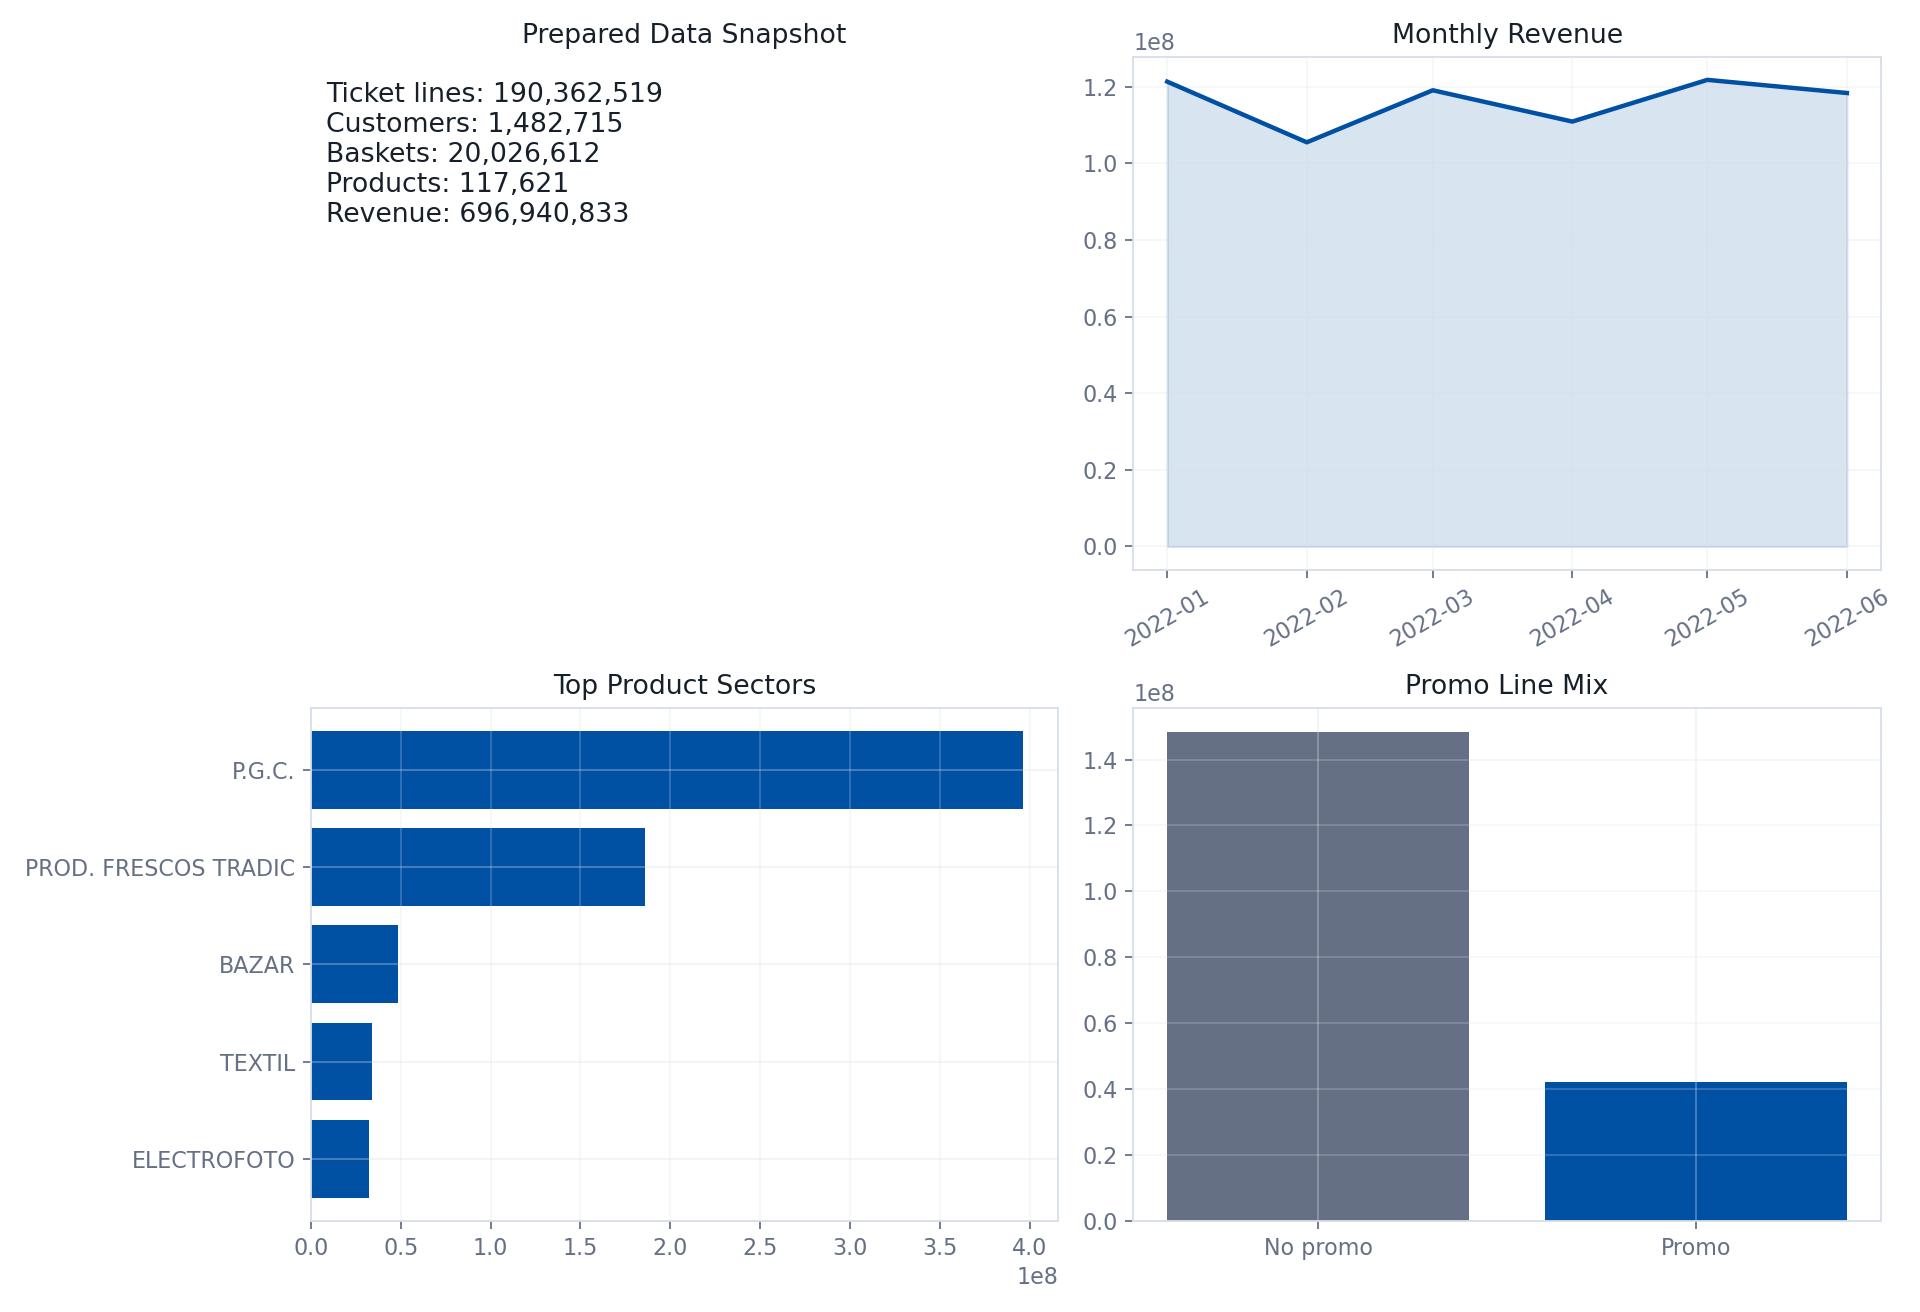

In [1]:
import os
from pathlib import Path
import sys

from IPython.display import Image, Markdown, display

# Optional notebook override. Set to "dev" or "prod" to force a mode;
# leave as None to honor CARREFOUR_MODE, then the YAML default_mode.
NOTEBOOK_MODE_OVERRIDE = "prod"  # Set to "dev" or "prod" only when you intentionally want to override CARREFOUR_MODE.

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src").is_dir():
        project_root = candidate
        break
else:
    project_root = Path.cwd().resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import configure_mode, load_config
from src.cache_audit import assert_mode_path_audit
from src.data_loader import load_prepared_transactions, peek
from src.stage_reports import display_stage_report, write_stage_report
from src.utils import set_global_seed

RUN_MODE = (NOTEBOOK_MODE_OVERRIDE or os.environ.get("CARREFOUR_MODE") or load_config().mode).strip().lower()
if RUN_MODE not in {"dev", "prod"}:
    raise ValueError(f"RUN_MODE must be 'dev' or 'prod', got {RUN_MODE!r}")
os.environ["CARREFOUR_MODE"] = RUN_MODE

previous_mode = globals().get("MODE")
CONFIG = configure_mode(RUN_MODE)
MODE = CONFIG.mode
DATA_PROCESSED = CONFIG.data_processed
MODELS = CONFIG.models
OUTPUTS = CONFIG.outputs

if previous_mode and previous_mode != MODE:
    for stale_name in [
        "transactions",
        "basket_path",
        "item2vec_model",
        "product_embeddings_path",
        "embedding_validation_csv",
        "embedding_validation_detail_md",
        "customer_embeddings_path",
        "behavior_path",
        "feature_sets",
        "model_suite",
        "stage6_diagnostics",
        "cluster_stability",
        "stability_table",
        "cluster_readiness_table",
        "stage6_winner_key",
        "stage6_stage1_assignment_path",
        "stage6_stage1_result_path",
        "stage6_stage1_candidate",
        "stage6_stage1_checks_path",
        "stage6_stage1_figure",
        "stage6_stage2_noise_feature_path",
        "stage6_stage2_noise_customers",
        "stage6_stage2_assignment_path",
        "stage6_stage2_result_path",
        "stage6_stage2_candidate",
        "stage6_stage2_checks_path",
        "stage6_stage2_figure",
        "stage6_lift_evidence_path",
        "stage6_lift_evidence",
        "stage6_4_projection_dir",
        "stage6_4_projection_figures",
        "stage6_6_projection_dir",
        "stage6_6_projection_figures",
        "stage6_6_winner_stability",
        "stage6_6_cluster_readiness",
        "stage6_6_cluster_readiness_figure",
        "stage6_7_noise_probe",
        "stage6_7_noise_umap_figure",
        "stage6_7_run_candidate_hdbscan",
        "stage6_7_candidate_probe",
        "stage6_7_diagnostics_path",
        "stage6_7_diagnostics",
        "stage6_7_report",
        "stage6_8_evidence",
        "stage6_8_manifest_path",
        "stage6_8_tribe_evidence_path",
        "stage6_8_product_lifts_path",
        "stage6_8_sector_lifts_path",
        "stage6_8_customer_metric_tests_path",
        "stage6_8_manifest",
        "stage6_8_overview_figure",
        "stage6_8_report",
        "selected_key",
        "selection_evidence_path",
        "selected",
        "selected_profile_path",
        "stage7_artifacts_dir",
        "stage7_figures_dir",
        "stage7_quality",
        "stage7_review_clusters",
        "stage7_final_tribes",
        "stage7_review_candidates",
        "product_summary_paths",
        "tribe_product_tables",
        "tribe_comparison_artifacts",
        "tribe_comparison",
        "customer_metric_tests_path",
        "customer_metric_tests",
        "stage7_significant_customer_metric_tests",
        "stage7_profile_overview",
        "stage7_profile_evidence",
        "stage7_noise_audit",
        "stage7_noise_audit_paths",
        "stage7_noise_summary_row",
        "stage7_storyline_paths",
        "stage7_storyline",
        "stage7_cluster_summary_paths",
        "tribe_vs_population_dashboard",
        "profile_comparison_heatmap",
        "stage7_theme_lift_heatmap",
        "stage7_lift_dir",
        "stage7_final_pack",
        "stage7_final_index",
        "stage7_card_paths",
        "stage7_card_count",
        "stage7_customer_metric_tests_path",
        "stage7_customer_metric_tests",
        "stage7_llm_evidence_path",
        "stage7_gemini_analysis",
        "stage7_gemini_analysis_path",
        "stage7_gemini_status",
        "stage7_gemini_reason",
        "top_lift_paths",
        "profile_export",
        "subsegment_opportunities",
        "subsegment_opportunities_path",
        "customer_subsegment_paths",
        "discovered_term_paths",
        "campaign_signal_paths",
        "profile_report_path",
        "clustering_atlas_paths",
        "llm_prompt_paths",
    ]:
        globals().pop(stale_name, None)

set_global_seed(CONFIG.random_seed)
CONFIG.ensure_directories()
mode_path_audit = assert_mode_path_audit(CONFIG)

transactions = load_prepared_transactions(cfg=CONFIG)
print(f"Run mode: {MODE}")
print(f"Data path: {DATA_PROCESSED}")
print(f"Model path: {MODELS}")
print(f"Output path: {OUTPUTS}")
peek(transactions, 3)

from src.visualization import plot_prepared_data_overview

stage0_figure = plot_prepared_data_overview(transactions, cfg=CONFIG)
stage0_report = write_stage_report(
    "00",
    "Load Prepared Data",
    summary=[
        f"Run mode active: {MODE}",
        "Mode/path audit passed; dev and prod namespaces are not mixed.",
        "Prepared transactions loaded from the configured mode path.",
    ],
    metrics={
        "mode_path_checks": mode_path_audit.height,
        "failed_mode_path_checks": mode_path_audit.filter(mode_path_audit.get_column("status") == "fail").height,
    },
    figures={"Prepared data overview": stage0_figure},
    artifacts={"Prepared transactions": CONFIG.prepared_transactions_path},
    cfg=CONFIG,
)
display_stage_report(stage0_report)
display(mode_path_audit.select(["check", "status", "exists", "reason"]).head(12))
display(Image(filename=str(stage0_figure)))


<a id="stage-0-5"></a>

## Stage 0.5: Expensive Cache Audit

Before expensive stages run, this audit checks whether Stage 1-6 artifacts can be reused. A cache hit requires the file to exist and its metadata hash to match the current inputs/config, so stale artifacts are less likely to slip into the run.


In [2]:
import importlib
import os
import polars as pl

import src.utils
importlib.reload(src.utils)
import src.cache_audit
importlib.reload(src.cache_audit)
from src.cache_audit import stage_1_6_cache_audit
from src.stage_reports import display_stage_report, write_stage_report
# Optional: if existing artifacts were produced from the current data/config but metadata is missing,
# uncomment the next two lines once to adopt them into the cache manifest.

cache_audit = stage_1_6_cache_audit(CONFIG)
cache_misses = cache_audit.filter(~pl.col("cache_hit"))

stage0_5_report = write_stage_report(
    "00_5",
    "Expensive Cache Audit",
    summary=[
        "Checks whether expensive Stage 1-6 artifacts can be reused safely.",
        "Artifacts with cache_hit=False will be rebuilt when their stage runs.",
    ],
    metrics={
        "audited_artifacts": cache_audit.height,
        "cache_ready_artifacts": cache_audit.filter(pl.col("cache_hit")).height,
        "rebuild_artifacts": cache_misses.height,
    },
    artifacts={"Artifact metadata manifest": CONFIG.outputs / ".artifact_metadata.json"},
    cfg=CONFIG,
)
display_stage_report(stage0_5_report)
cache_display_cols = ["stage", "artifact", "cache_hit", "exists", "reason", "path"]
display(cache_audit.select([c for c in cache_display_cols if c in cache_audit.columns]).head(20))

if cache_misses.height:
    print("Artifacts listed as cache_hit=False will be rebuilt if their stage is run.")
else:
    print("All expensive Stage 1-6 artifacts are cache-ready.")


# Stage 0.5: Expensive Cache Audit

- Mode: `prod`

## Status
- Checks whether expensive Stage 1-6 artifacts can be reused safely.
- Artifacts with cache_hit=False will be rebuilt when their stage runs.

## Key Metrics

| Metric | Value |
|---|---|
| audited_artifacts | 14 |
| cache_ready_artifacts | 12 |
| rebuild_artifacts | 2 |

## Artifacts
- Artifact metadata manifest: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\.artifact_metadata.json`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

stage,artifact,cache_hit,exists,reason,path
str,str,bool,bool,str,str
"""1""","""basket_common_product_candidat…",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_common_product_exposure""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_product_ubiquity_diagno…",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_sentences""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""2""","""item2vec_model""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
…,…,…,…,…,…
"""5""","""behavioral_features""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""5""","""feature_set_embeddings_only""",true,true,"""metadata matched""","""C:\Users\rothl\Desktop\IE Caps…"
"""6""","""model_b_hdbscan_assignments""",false,false,"""artifact missing""","""C:\Users\rothl\Desktop\IE Caps…"


Artifacts listed as cache_hit=False will be rebuilt if their stage is run.


In [3]:
# In case of downloaded/ distributes files to make sure we can still run it
from src.cache_audit import adopt_existing_stage_1_6_cache_metadata
display(adopt_existing_stage_1_6_cache_metadata(CONFIG))


stage,artifact,adopted,reason,path
str,str,bool,str,str
"""1""","""basket_common_product_candidat…",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_common_product_exposure""",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_product_ubiquity_diagno…",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""1""","""basket_sentences""",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""2""","""item2vec_model""",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
…,…,…,…,…
"""5""","""behavioral_features""",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""5""","""feature_set_embeddings_only""",true,"""metadata written""","""C:\Users\rothl\Desktop\IE Caps…"
"""6""","""model_b_hdbscan_assignments""",false,"""artifact missing or metadata u…","""C:\Users\rothl\Desktop\IE Caps…"


<a id="stage-1"></a>

## Stage 1: Basket Construction

Each ticket becomes a basket sentence and each product id becomes a token. The assumption is simple: products bought together reveal shopping missions. Quantity is not repeated as extra tokens unless `baskets.repeat_product_by_quantity` is enabled.


[19:08:25] Stage 1 baskets: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\embeddings\basket_sentences.parquet
[19:08:28] Stage 1 figures: wrote basket summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage1_basket_sentence_lengths.png
[19:08:28] Stage 1 baskets: staple diagnostics cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage1
[19:08:31] Stage 1 figures: wrote common-product diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage1_common_product_diagnostics.png


# Stage 01: Basket Sentences and Common-Product Exposure

- Mode: `prod`

## Status
- Basket sentences use product identity; active Stage 1 settings do not repeat products by unidades.
- Common-product exposure and downsampling retention are audited before Item2Vec training.

## Key Metrics

| Metric | Value |
|---|---|
| n_baskets | 20019265 |
| avg_products_per_basket | 7.731 |
| median_products_per_basket | 5 |
| max_products_per_basket | 214 |
| common_product_candidates | 1429 |
| common_product_preview_rows | 50 |
| basket_retention_pct | 99.963 |
| unique_pair_retention_pct | 81.305 |
| fallback_basket_pct | 2.394 |
| auto_excluded_products | 1 |
| downsampled_common_candidate_products | 1428 |

## Visual Evidence
- Basket token summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage1_basket_sentence_lengths.png`
- Common-product exposure: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage1_common_product_diagnostics.png`

## Artifacts
- Basket sentences: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\embeddings\basket_sentences.parquet`
- Common-product candidates CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage1\common_product_candidates.csv`
- Product ubiquity diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage1\product_ubiquity_diagnostics.parquet`
- Downsampling plan: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage1\common_product_downsampling_plan.parquet`
- Downsampling summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage1\basket_downsampling_summary.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

n_baskets,avg_products_per_basket,median_products_per_basket,max_products_per_basket
u32,f64,f64,u32
20019265,7.731258,5.0,214


raw_baskets,raw_unique_ticket_product_pairs,raw_common_candidate_pairs,excluded_pairs,manual_excluded_pairs,auto_excluded_pairs,candidate_baskets_after_exclusions,candidate_pairs_after_exclusions,sample_selected_pairs,sample_dropped_common_candidate_pairs,fallback_baskets,plan_products,common_candidate_products,excluded_products,manual_excluded_products,auto_excluded_products,downsampled_common_candidate_products,mean_keep_probability,mean_common_candidate_keep_probability,output_baskets,output_unique_ticket_product_pairs,baskets_dropped_by_downsampling,basket_retention_pct,unique_pair_retention_pct,unique_pairs_dropped_by_downsampling,fallback_basket_pct,sample_modulus
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,i64,f64,f64,i64,f64,i64
20026612,190362519,86651707,4105902,0,4105902,20019265,186256617,154294626,31961991,479473,117621,1429,1,0,1,1428,0.997105,0.761683,20019265,154774099,7347,99.963314,81.304923,35588420,2.394179,1000000


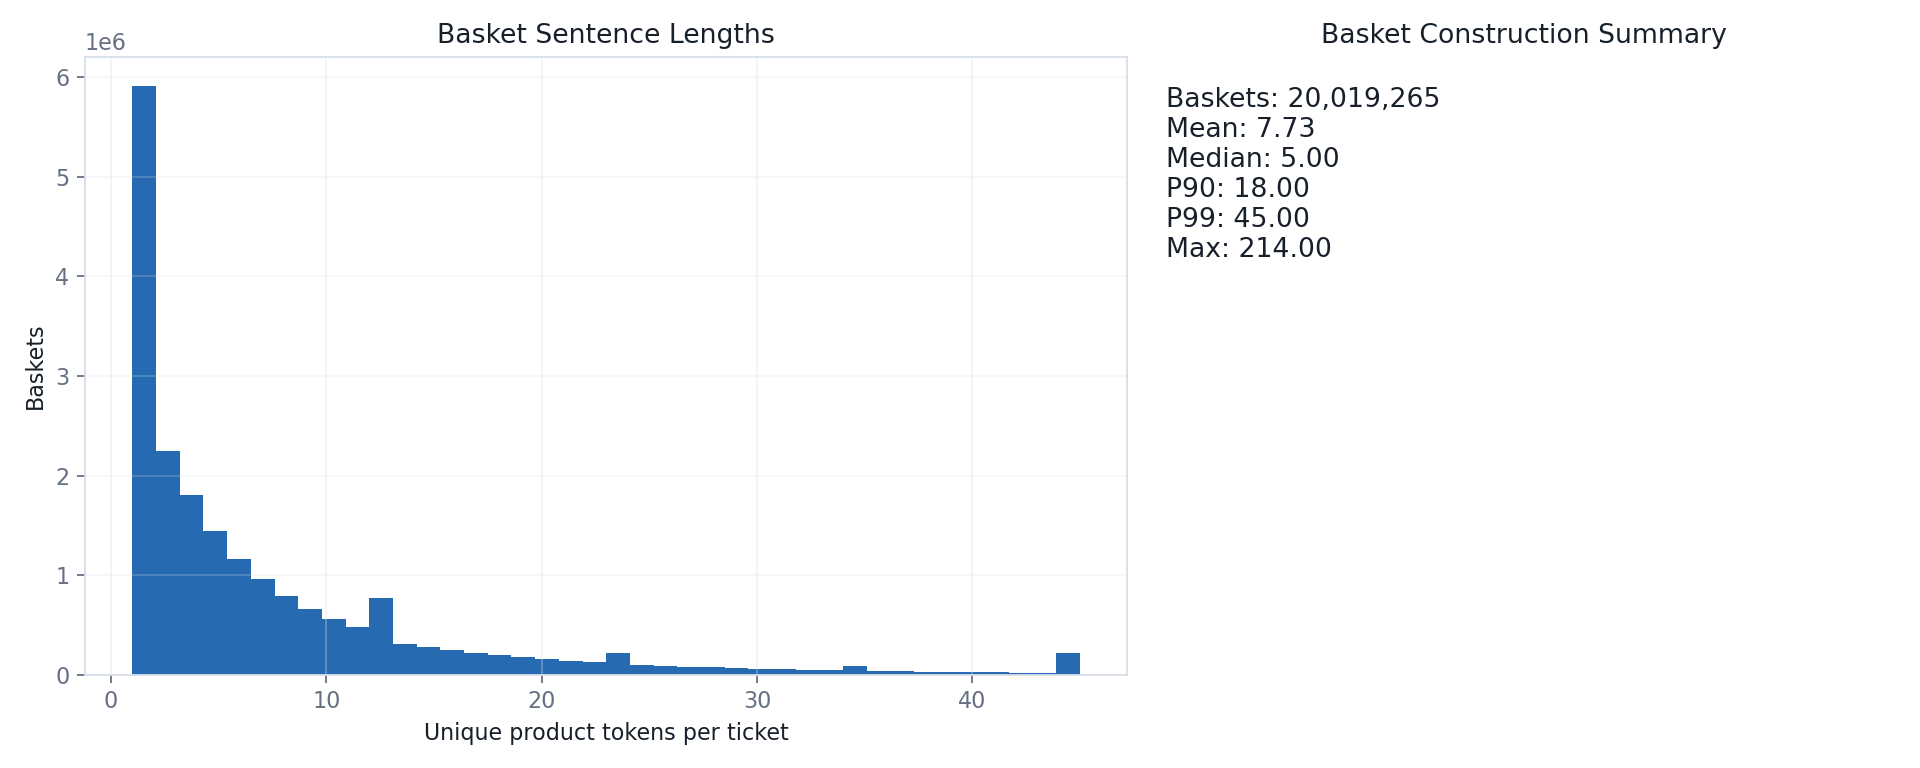

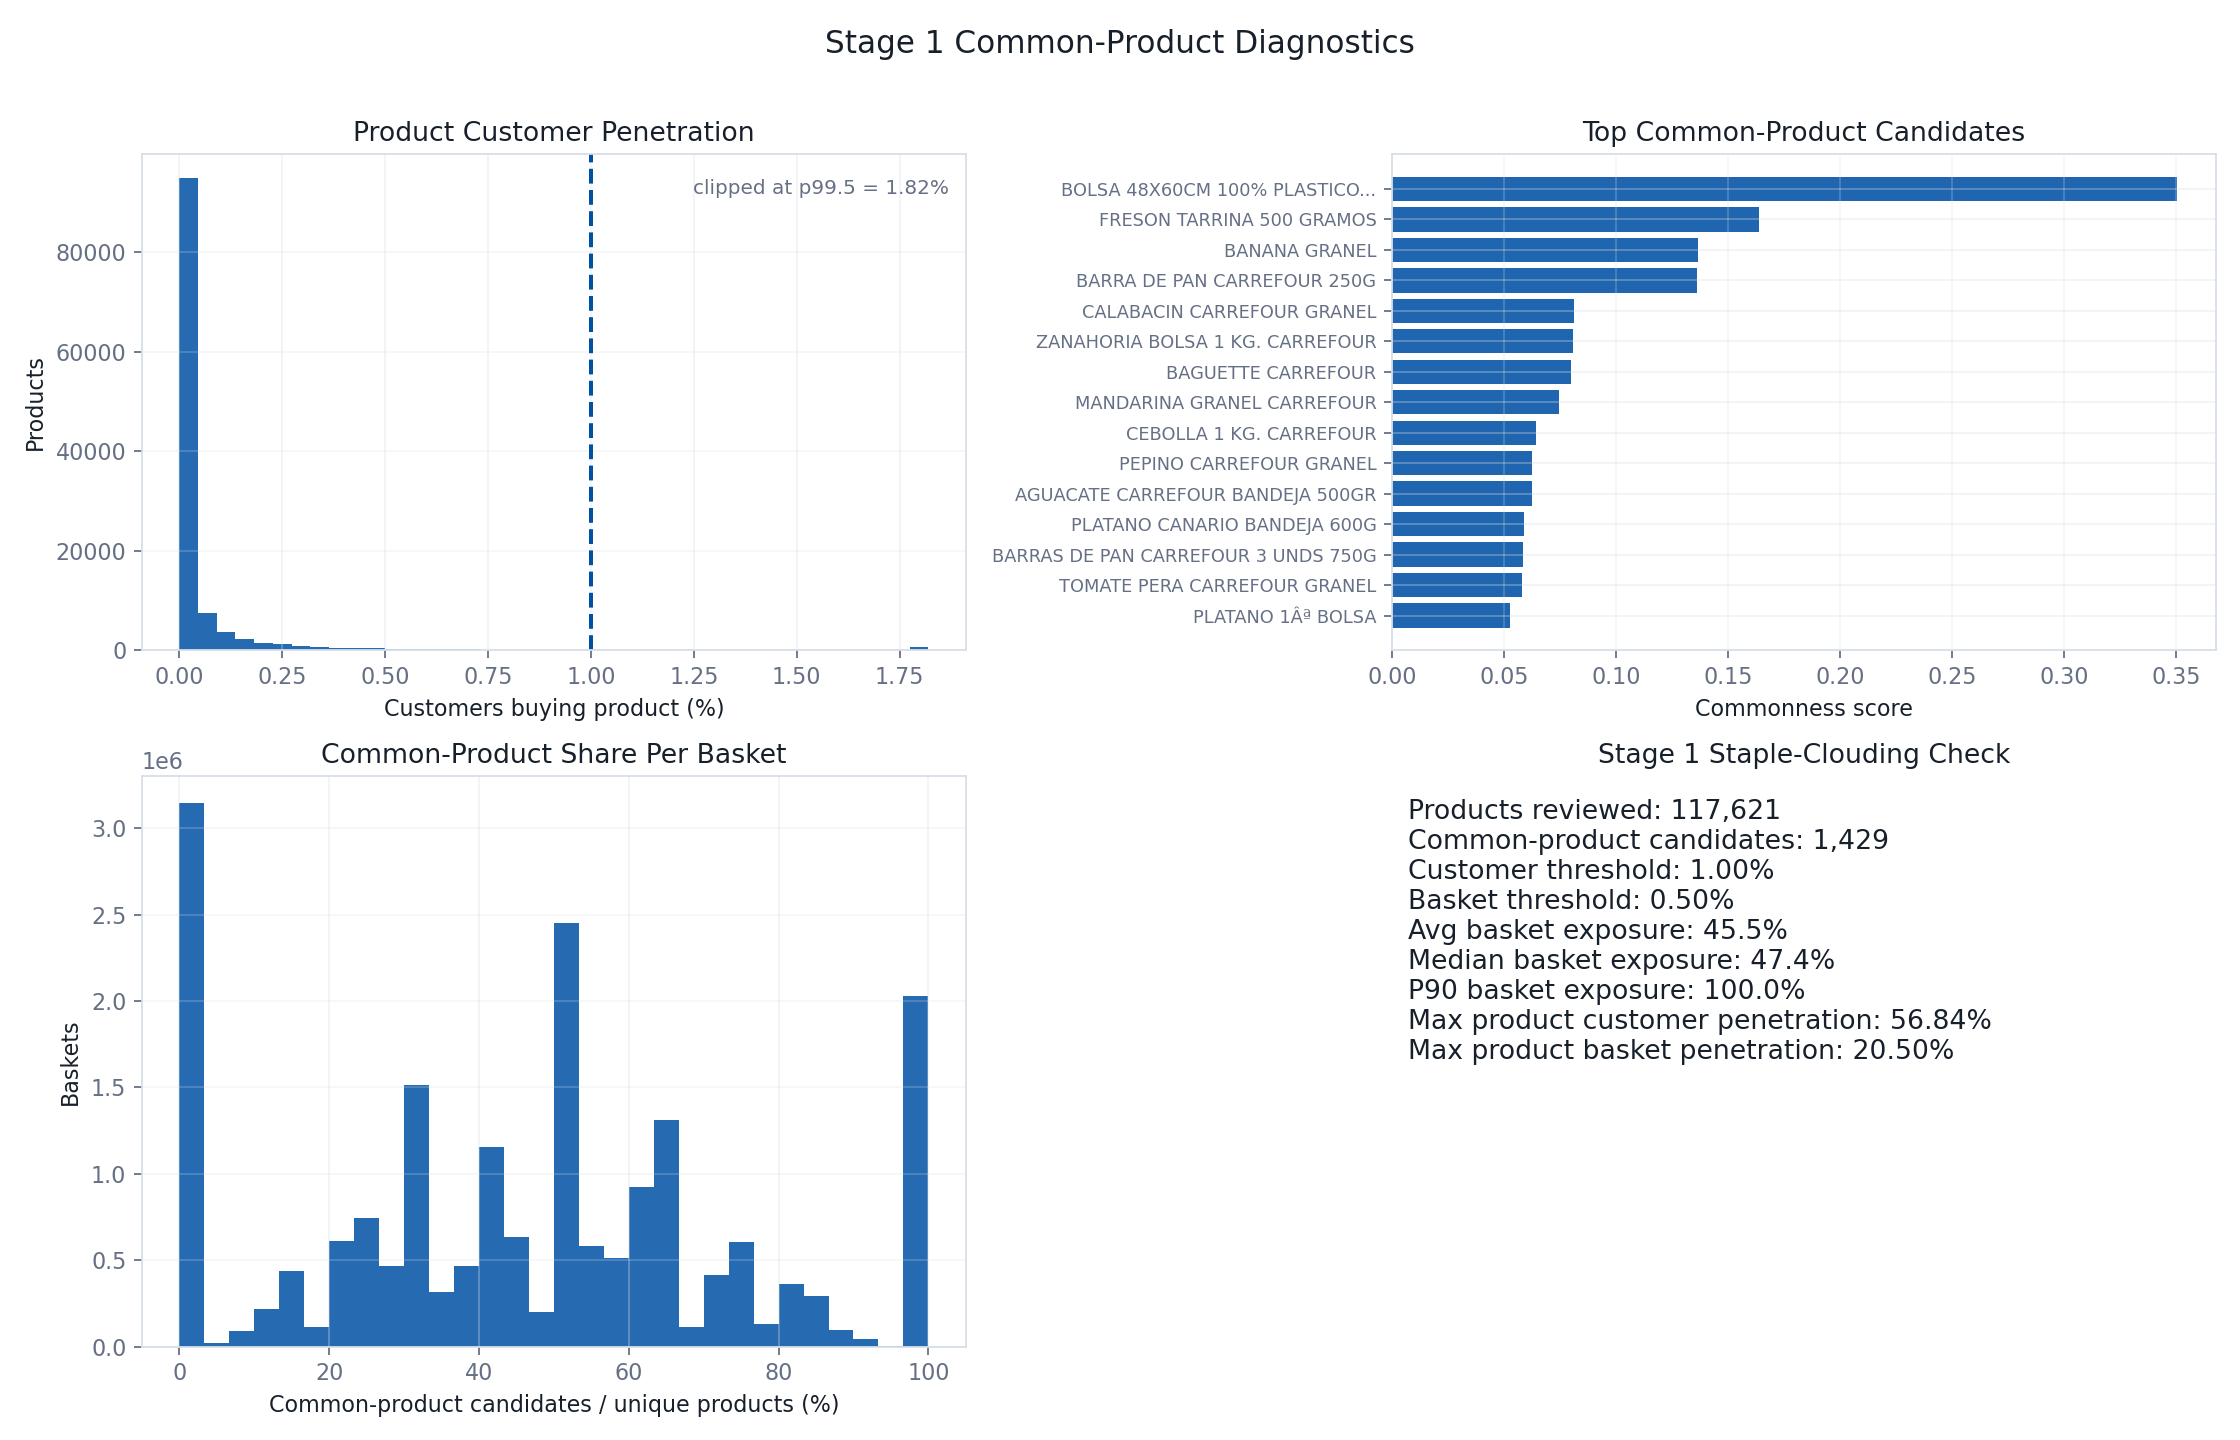

Stage 2 Item2Vec basket path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\embeddings\basket_sentences.parquet


In [4]:
from IPython.display import Image, display
import polars as pl

from src.basket_builder import (
    basket_summary,
    build_basket_sentences,
    build_basket_staple_diagnostics,
)
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import (
    plot_basket_staple_diagnostics,
    plot_basket_summary,
)

basket_path = build_basket_sentences(transactions=transactions, cfg=CONFIG)
stage1_basket_summary = basket_summary(basket_path)
stage1_figure = plot_basket_summary(basket_path, cfg=CONFIG)

stage1_diagnostics = build_basket_staple_diagnostics(transactions=transactions, cfg=CONFIG)
stage1_staple_figure = plot_basket_staple_diagnostics(
    stage1_diagnostics["product_diagnostics"],
    stage1_diagnostics["basket_exposure"],
    cfg=CONFIG,
)
stage1_product_diagnostics = pl.scan_parquet(stage1_diagnostics["product_diagnostics"])
stage1_common_products = stage1_product_diagnostics.filter(pl.col("common_product_candidate")).select(pl.len()).collect()[0, 0]
stage1_common_preview_rows = (
    pl.read_csv(stage1_diagnostics["common_products_csv"]).height
    if stage1_diagnostics["common_products_csv"].exists()
    else 0
)
stage1_downsampling_diag_cfg = CONFIG.get("baskets.diagnostics", {}) or {}
stage1_downsampling_plan_path = CONFIG.artifacts / str(stage1_downsampling_diag_cfg.get("output_dir", "stage1")) / str(stage1_downsampling_diag_cfg.get("downsampling_plan_output", "common_product_downsampling_plan.parquet"))
stage1_downsampling_summary_path = CONFIG.artifacts / str(stage1_downsampling_diag_cfg.get("output_dir", "stage1")) / str(stage1_downsampling_diag_cfg.get("downsampling_summary_output", "basket_downsampling_summary.csv"))
stage1_metrics = stage1_basket_summary.row(0, named=True)
stage1_metrics["common_product_candidates"] = stage1_common_products
stage1_metrics["common_product_preview_rows"] = stage1_common_preview_rows
stage1_downsampling_summary = None
if stage1_downsampling_summary_path.exists():
    stage1_downsampling_summary = pl.read_csv(stage1_downsampling_summary_path)
    stage1_metrics.update(
        stage1_downsampling_summary.select(
            [
                "basket_retention_pct",
                "unique_pair_retention_pct",
                "fallback_basket_pct",
                "auto_excluded_products",
                "downsampled_common_candidate_products",
            ]
        ).row(0, named=True)
    )
stage1_report = write_stage_report(
    "01",
    "Basket Sentences and Common-Product Exposure",
    summary=[
        "Basket sentences use product identity; active Stage 1 settings do not repeat products by unidades.",
        "Common-product exposure and downsampling retention are audited before Item2Vec training.",
    ],
    metrics=stage1_metrics,
    figures={
        "Basket token summary": stage1_figure,
        "Common-product exposure": stage1_staple_figure,
    },
    artifacts={
        "Basket sentences": basket_path,
        "Common-product candidates CSV": stage1_diagnostics["common_products_csv"],
        "Product ubiquity diagnostics": stage1_diagnostics["product_diagnostics"],
        "Downsampling plan": stage1_downsampling_plan_path if stage1_downsampling_plan_path.exists() else None,
        "Downsampling summary": stage1_downsampling_summary_path if stage1_downsampling_summary_path.exists() else None,
    },
    cfg=CONFIG,
)
display_stage_report(stage1_report)
display(stage1_basket_summary)
if stage1_downsampling_summary is not None:
    display(stage1_downsampling_summary)
display(Image(filename=str(stage1_figure)))
display(Image(filename=str(stage1_staple_figure)))
print(f"Stage 2 Item2Vec basket path: {basket_path}")


<a id="stage-2"></a>

## Stage 2: Item2Vec Product Embeddings

The Word2Vec model learns product proximity from basket co-occurrence. Products land near each other when they appear in similar baskets, without using demographics, spend, or manual labels.

The training function prints the active hyperparameters and one progress line per epoch. If a cached model already exists, it prints the cache details instead; pass `force=True` to retrain.


Item2Vec: loading cached model
  baskets: 20,019,265
  product tokens: 154,774,099; avg/basket: 7.73; median/basket: 5.00
  training baskets: 16,788,317; training tokens: 131,918,895; skipped short baskets: 3,230,948; capped baskets: 1,639,205
  model path: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\word2vec_product.model
  config: vector_size=128, window=20 (configured=2, full_basket_context=True), min_tokens_per_basket=2, max_tokens_per_basket=20, min_count=60, negative=10, sample=0.0001, epochs=5, sg=1, workers=5, seed=42
Item2Vec cache loaded: vocab=56,569, vector_size=128
[19:08:32] Stage 2 product embeddings: wrote training corpus diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage2\item2vec_training_corpus_diagnostics.csv
[19:08:32] Stage 2 product embeddings: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\embeddings\product_embeddings.parquet
[19:08:34] Stage 2 

# Stage 02: Product Embedding Training

- Mode: `prod`

## Status
- Item2Vec is trained on Stage 1 product-token baskets after Stage 2 corpus limits.
- Product quantities enter the official customer vectors in Stage 4, not as repeated Stage 2 tokens under the active conf...

## Key Metrics

| Metric | Value |
|---|---|
| embedded_products | 56569 |
| embedding_dimensions | 128 |
| word2vec_window | 2 |
| word2vec_min_count | 60 |
| baskets | 20019265 |
| training_baskets | 16788317 |
| skipped_short_basket_pct | 16.139 |
| capped_basket_pct | 8.188 |
| training_token_retention_pct | 85.233 |
| effective_window | 20 |

## Visual Evidence
- Product embedding diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage2_product_embedding_diagnostics.png`

## Artifacts
- Product embeddings: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\embeddings\product_embeddings.parquet`
- Training corpus diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage2\item2vec_training_corpus_diagnostics.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

baskets,product_tokens,avg_tokens_per_basket,median_tokens_per_basket,max_tokens_per_basket,training_baskets,skipped_short_baskets,capped_baskets,training_product_tokens,training_basket_pct,skipped_short_basket_pct,capped_basket_pct,training_token_retention_pct,configured_window,effective_window,full_basket_context,min_tokens_per_basket,min_count,sample,negative,epochs,sg
i64,i64,f64,f64,i64,i64,i64,i64,i64,f64,f64,f64,f64,i64,i64,bool,i64,i64,f64,i64,i64,i64
20019265,154774099,7.731258,5.0,20,16788317,3230948,1639205,131918895,83.860806,16.139194,8.188138,85.233186,2,20,true,2,60,0.0001,10,5,1


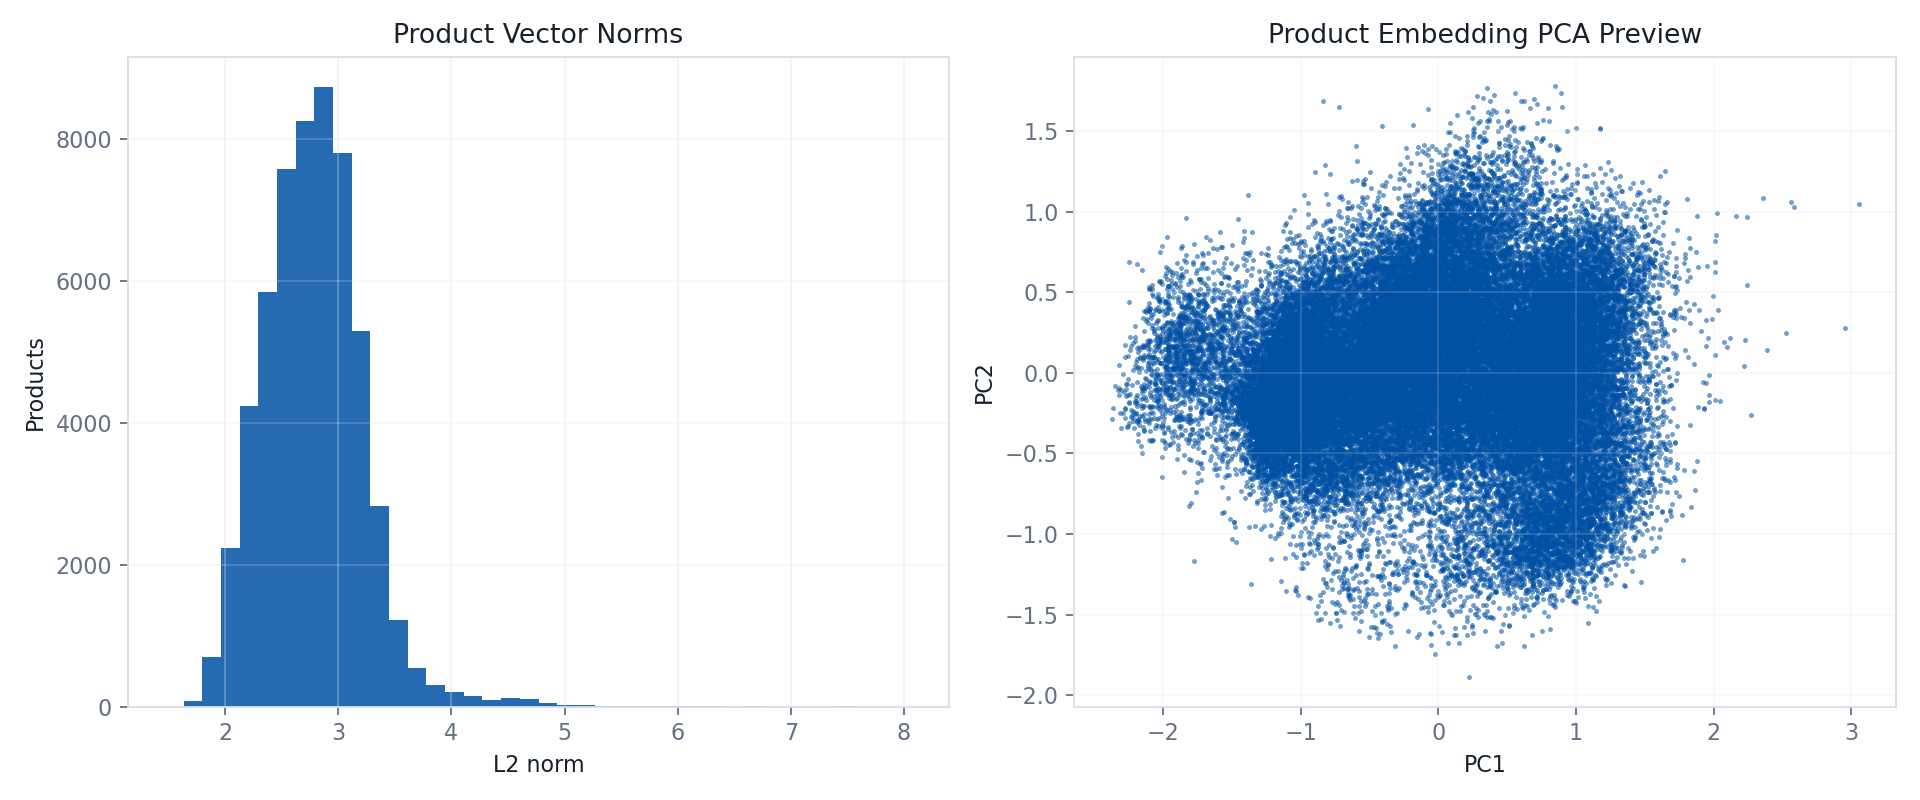

In [5]:
from IPython.display import Image
import polars as pl

from src.item2vec import save_product_embeddings, train_item2vec, write_item2vec_training_diagnostics
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_product_embedding_diagnostics

item2vec_model = train_item2vec(basket_path, cfg=CONFIG, verbose=True)
stage2_training_diagnostics_path = write_item2vec_training_diagnostics(basket_path, cfg=CONFIG)
stage2_training_diagnostics = pl.read_csv(stage2_training_diagnostics_path)
product_embeddings_path = save_product_embeddings(item2vec_model, cfg=CONFIG)
stage2_figure = plot_product_embedding_diagnostics(product_embeddings_path, cfg=CONFIG)
stage2_schema = pl.read_parquet(product_embeddings_path, n_rows=1).columns
stage2_metrics = {
    "embedded_products": pl.scan_parquet(product_embeddings_path).select(pl.len()).collect()[0, 0],
    "embedding_dimensions": len([c for c in stage2_schema if c.startswith("emb_")]),
    "word2vec_window": CONFIG.get("word2vec.window"),
    "word2vec_min_count": CONFIG.get("word2vec.min_count"),
}
stage2_metrics.update(
    stage2_training_diagnostics.select(
        [
            "baskets",
            "training_baskets",
            "skipped_short_basket_pct",
            "capped_basket_pct",
            "training_token_retention_pct",
            "effective_window",
        ]
    ).row(0, named=True)
)
stage2_report = write_stage_report(
    "02",
    "Product Embedding Training",
    summary=[
        "Item2Vec is trained on Stage 1 product-token baskets after Stage 2 corpus limits.",
        "Product quantities enter the official customer vectors in Stage 4, not as repeated Stage 2 tokens under the active config.",
    ],
    metrics=stage2_metrics,
    figures={"Product embedding diagnostics": stage2_figure},
    artifacts={"Product embeddings": product_embeddings_path, "Training corpus diagnostics": stage2_training_diagnostics_path},
    cfg=CONFIG,
)
display_stage_report(stage2_report)
display(stage2_training_diagnostics)
display(Image(filename=str(stage2_figure)))


<a id="stage-3"></a>

## Stage 3: Product Embedding Validation

Before customer clustering, the nearest-neighbor report checks whether product embeddings capture meaningful substitutes, complements, or shared basket missions. Generic or random-looking neighbors are treated as warning signs.


[19:08:34] Stage 3 embedding validation: cache hit | csv=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage3\embedding_validation.csv, hubness=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage3\embedding_hubness.csv
[19:08:35] Stage 3 figures: wrote embedding validation summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage3_embedding_validation_summary.png


# Stage 03: Product Embedding Validation

- Mode: `prod`

## Status
- Guardrail status: action_needed
- Stage 3 found product-neighbor issues that should be addressed in Stage 1/2 before interpretation.
- Issues: Some high-inbound embedding hubs attract neighbors across several sectors (max cross-sector inbound share 93.9%...

## Key Metrics

| Metric | Value |
|---|---|
| validated_products | 1616 |
| guardrail_issue_count | 2 |

## Visual Evidence
- Embedding validation summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage3_embedding_validation_summary.png`

## Artifacts
- Validation CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage3\embedding_validation.csv`
- Hubness CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage3\embedding_hubness.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

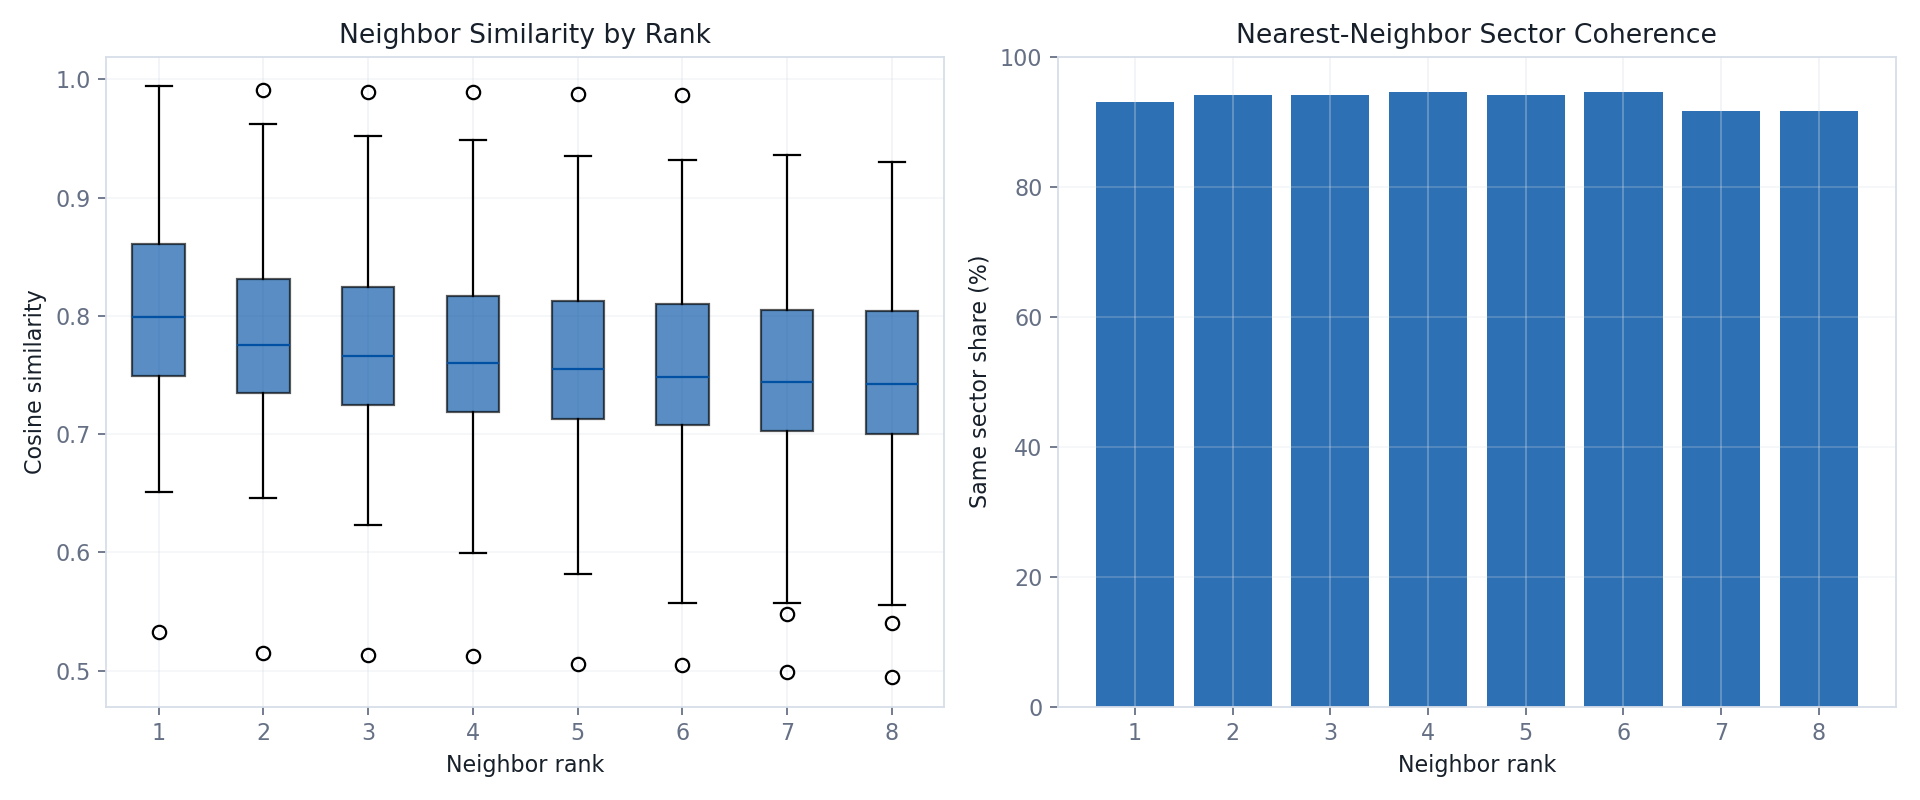

{'status': 'action_needed',
 'summary': 'Stage 3 found product-neighbor issues that should be addressed in Stage 1/2 before interpretation.',
 'issues': ['Some high-inbound embedding hubs attract neighbors across several sectors (max cross-sector inbound share 93.9%).',
  'Top hubness lift is high (73.30).'],
 'upstream_actions': ['Inspect the top hubness rows. If the hubs are sparse non-staples, raise `word2vec.min_count`; if they are true common staples, tune Stage 1 common-product exposure; if they are coherent products split by Carrefour sector taxonomy, keep as a watch item.',
  'Reduce broad co-occurrence blur upstream and rerun Stage 3; high hubness usually means a few products are absorbing too much neighborhood mass.'],
 'metrics': {'common_same_sector_share': 0.96875,
  'rare_same_sector_share': 0.88125,
  'common_rare_same_sector_gap': 0.08750000000000002,
  'generic_neighbor_warning_product_share': 0.0,
  'max_hub_cross_sector_share': 0.9393939393939394,
  'max_hubness_lift

In [6]:
from IPython.display import Image
import polars as pl

from src.embedding_validation import product_embedding_guardrail_status, validate_product_embeddings
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_embedding_validation_quality_extracts, plot_embedding_validation_summary

embedding_validation_csv, embedding_validation_detail_md = validate_product_embeddings(
    product_embeddings_path,
    transactions=transactions,
    cfg=CONFIG,
)
stage3_figure = plot_embedding_validation_summary(embedding_validation_csv, cfg=CONFIG)
stage3_extract_figures = {}
if CONFIG.get("embedding_validation.write_extract_figures", False):
    stage3_extract_figures = plot_embedding_validation_quality_extracts(embedding_validation_csv, cfg=CONFIG)
stage3_guardrail_status = product_embedding_guardrail_status(embedding_validation_csv, cfg=CONFIG)
stage3_figures = {"Embedding validation summary": stage3_figure}
stage3_figures.update({f"Quality extract: {name}": path for name, path in stage3_extract_figures.items()})
stage3_issues = stage3_guardrail_status["issues"] or ["None"]
stage3_report = write_stage_report(
    "03",
    "Product Embedding Validation",
    summary=[
        f"Guardrail status: {stage3_guardrail_status['status']}",
        stage3_guardrail_status["summary"],
        "Issues: " + "; ".join(stage3_issues[:4]),
    ],
    metrics={
        "validated_products": pl.read_csv(embedding_validation_csv).height,
        "guardrail_issue_count": 0 if stage3_guardrail_status["issues"] is None else len(stage3_guardrail_status["issues"]),
    },
    figures=stage3_figures,
    artifacts={
        "Validation CSV": embedding_validation_csv,
        "Hubness CSV": stage3_guardrail_status["hubness_csv"],
    },
    cfg=CONFIG,
)
display_stage_report(stage3_report)
display(Image(filename=str(stage3_figure)))
for figure_path in stage3_extract_figures.values():
    display(Image(filename=str(figure_path)))
stage3_guardrail_status


<a id="stage-4"></a>

## Stage 4: Customer Embeddings

Each customer becomes one vector: a weighted average of the products they bought. Weighting uses quantity, recency decay, and repeat-basket frequency, so clustering is driven by product choice and purchase intensity rather than spend. IDF variants stay sandbox-only unless explicitly promoted in config.


[19:08:35] Stage 4 customer embeddings: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\customer_embeddings.parquet
[19:08:37] Stage 4 figures: wrote customer embedding diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage4_customer_embedding_diagnostics.png


# Stage 04: Customer Embeddings Coverage and Dominance Gates

- Mode: `prod`

## Status
- Customer vectors are weighted aggregations of purchased-product embeddings.
- Coverage gates check how much transaction signal survives product embedding coverage.
- Dominance gates check whether common products overwhelm customer vectors.

## Key Metrics

| Metric | Value |
|---|---|
| embedded_customers | 1478831 |
| weight_strategy | quantity_idf |
| quantity_transform | log1p |
| common_product_weight_share_pct | 36.613 |
| mean_customer_common_product_weight_share_pct | 33.081 |
| p95_customer_common_product_weight_share_pct | 64.699 |
| top_product_weight_share_pct | 0.8109 |
| top_10_product_weight_share_pct | 2.863 |
| mean_customer_top_product_weight_share_pct | 15.691 |
| stage4_gate_status | pass |
| stage4_gate_issues | None |
| recency_weighting_enabled | True |
| recency_reference_date | 2022-06-30 |
| recency_half_life_days | 180 |
| mean_recency_multiplier | 0.7223 |
| frequency_weighting_enabled | True |
| frequency_transform | log1p |
| mean_frequency_multiplier | 1.087 |
| p95_customer_product_basket_count | 4 |
| line_coverage_pct | 97.316 |
| unit_coverage_pct | 97.711 |
| product_coverage_pct | 48.094 |
| customer_coverage_pct | 99.738 |
| zero_embedded_customer_pct | 0.262 |

## Visual Evidence
- Customer embedding diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage4_customer_embedding_diagnostics.png`

## Artifacts
- Customer embeddings: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\customer_embeddings.parquet`
- Weight diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage4\customer_embedding_weight_diagnostics.csv`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

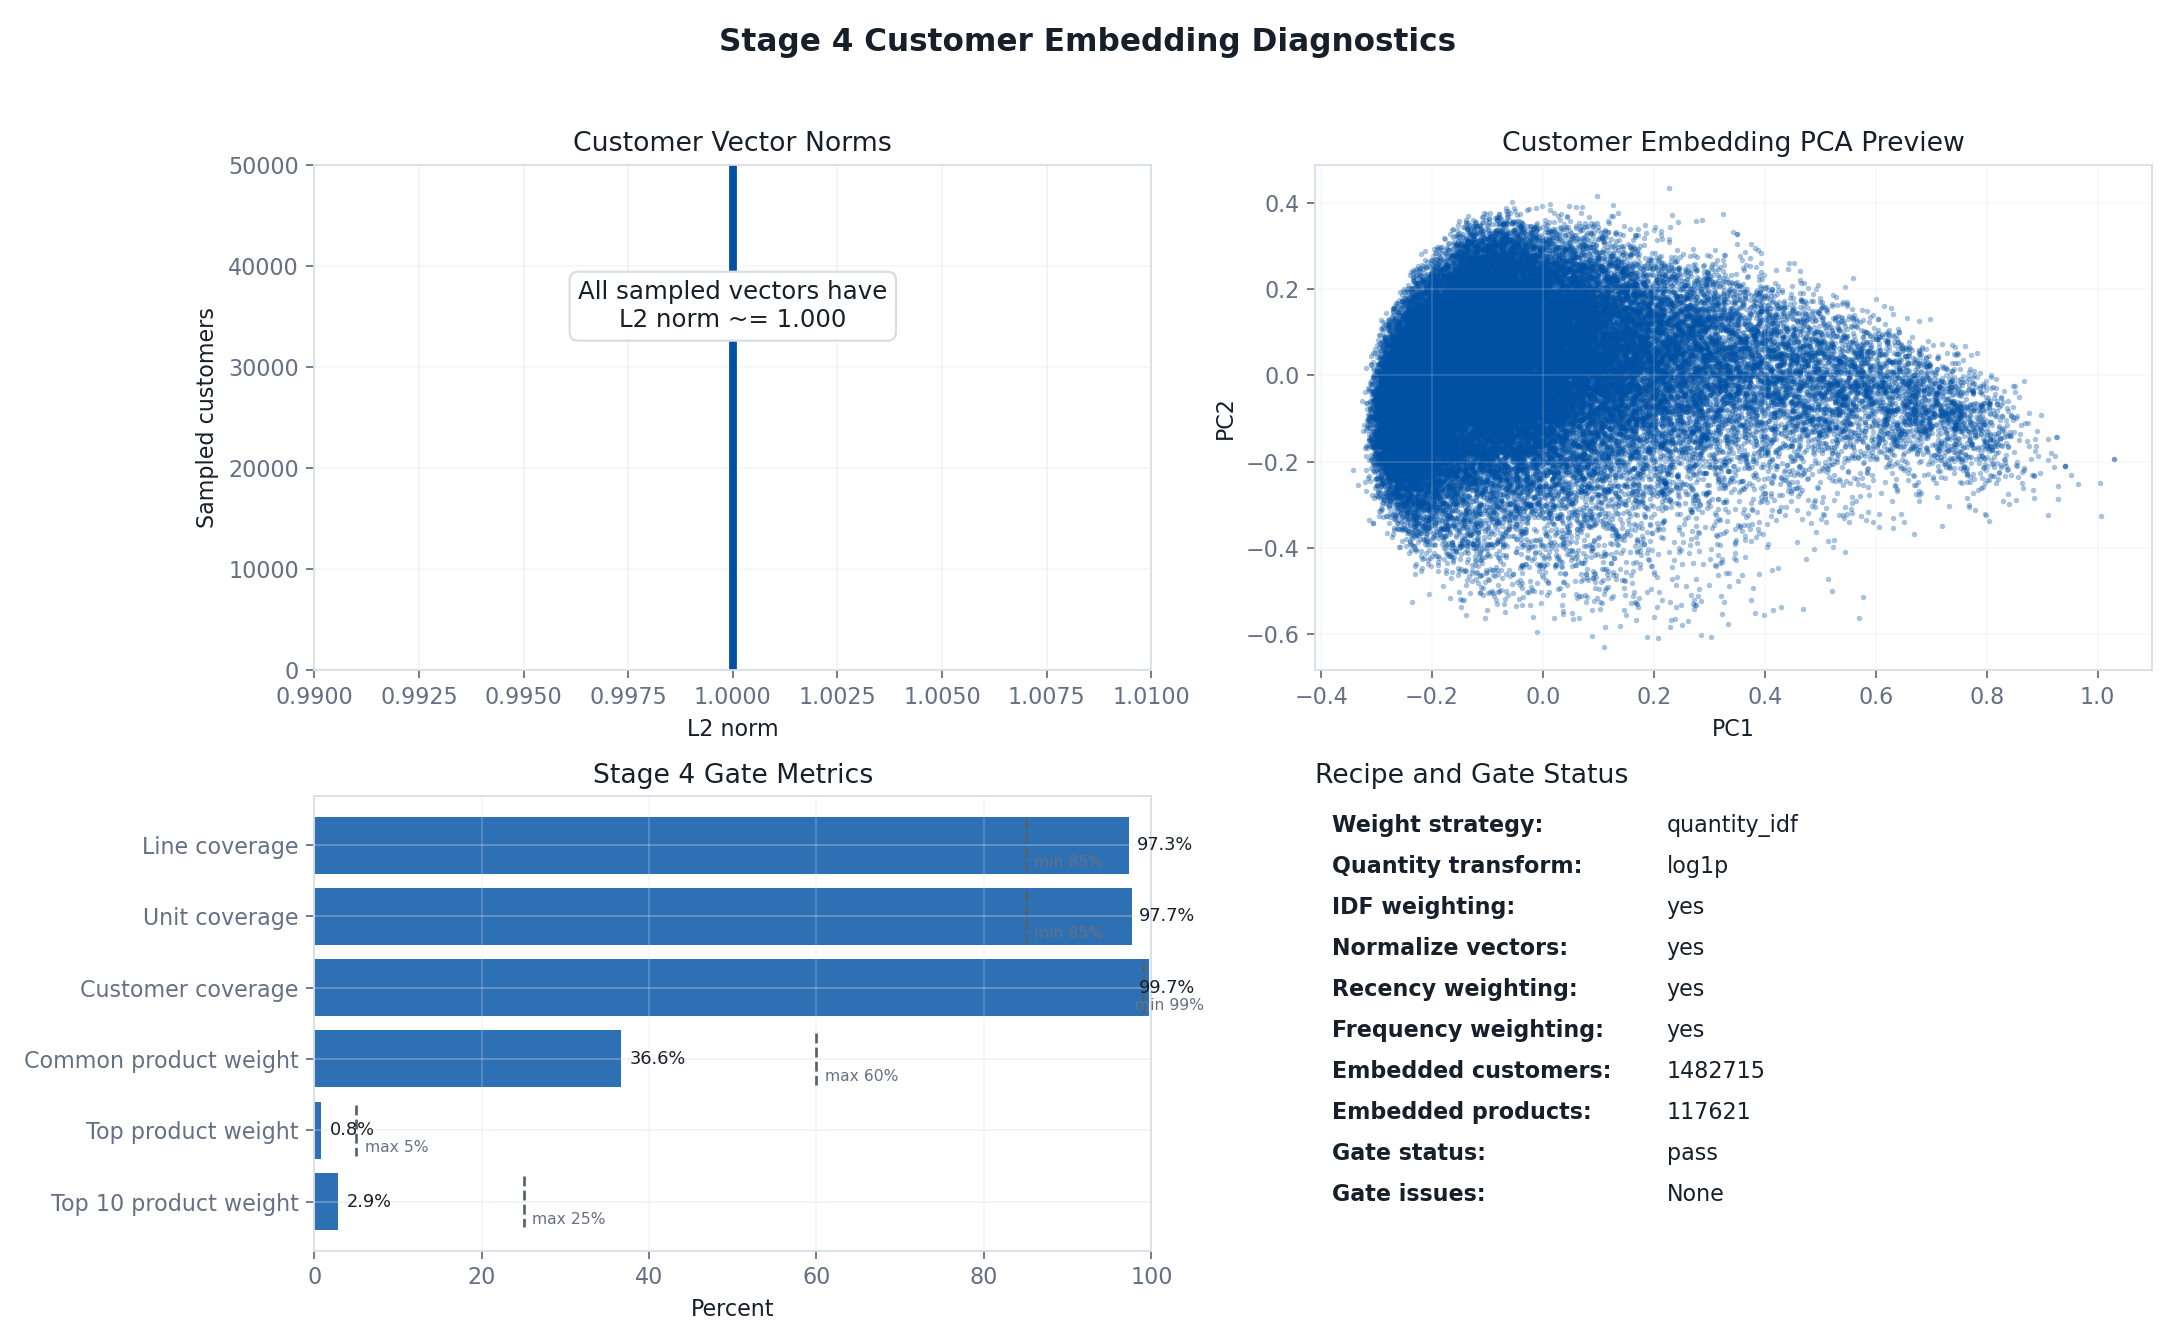

weight_strategy,quantity_transform,common_product_weight_share_pct,mean_customer_common_product_weight_share_pct,p95_customer_common_product_weight_share_pct,top_product_weight_share_pct,top_10_product_weight_share_pct,mean_customer_top_product_weight_share_pct,stage4_gate_status,stage4_gate_issues,recency_weighting_enabled,recency_reference_date,recency_half_life_days,mean_recency_multiplier,frequency_weighting_enabled,frequency_transform,mean_frequency_multiplier,p95_customer_product_basket_count,line_coverage_pct,unit_coverage_pct,product_coverage_pct,customer_coverage_pct,zero_embedded_customer_pct
str,str,f64,f64,f64,f64,f64,f64,str,str,bool,str,f64,f64,bool,str,f64,f64,f64,f64,f64,f64,f64
"""quantity_idf""","""log1p""",36.613475,33.081437,64.699324,0.810915,2.863453,15.691146,"""pass""","""None""",true,"""2022-06-30""",180.0,0.722256,true,"""log1p""",1.08749,4.0,97.316036,97.710791,48.094303,99.738048,0.261952


In [7]:
from IPython.display import Image, display
import polars as pl

from src.customer_embeddings import build_customer_embeddings
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_customer_embedding_diagnostics

customer_embeddings_path = build_customer_embeddings(
    product_embeddings_path,
    transactions=transactions,
    normalize_vectors=CONFIG.get("customer_embeddings.normalize_vectors", False),
    cfg=CONFIG,
)
stage4_figure = plot_customer_embedding_diagnostics(customer_embeddings_path, cfg=CONFIG)

stage4_diag_cfg = CONFIG.get("customer_embeddings.diagnostics", {}) or {}
stage4_weight_summary_path = (
    CONFIG.artifacts
    / str(stage4_diag_cfg.get("output_dir", "stage4"))
    / f"{stage4_diag_cfg.get('output_prefix', 'customer_embedding')}_weight_diagnostics.csv"
)
stage4_display_cols = [
    "weight_strategy",
    "quantity_transform",
    "common_product_weight_share_pct",
    "mean_customer_common_product_weight_share_pct",
    "p95_customer_common_product_weight_share_pct",
    "top_product_weight_share_pct",
    "top_10_product_weight_share_pct",
    "mean_customer_top_product_weight_share_pct",
    "stage4_gate_status",
    "stage4_gate_issues",
    "recency_weighting_enabled",
    "recency_reference_date",
    "recency_half_life_days",
    "mean_recency_multiplier",
    "frequency_weighting_enabled",
    "frequency_transform",
    "mean_frequency_multiplier",
    "p95_customer_product_basket_count",
    "line_coverage_pct",
    "unit_coverage_pct",
    "product_coverage_pct",
    "customer_coverage_pct",
    "zero_embedded_customer_pct",
]
stage4_weight_summary = None
stage4_report_metrics = {
    "embedded_customers": pl.scan_parquet(customer_embeddings_path).select(pl.len()).collect()[0, 0]
}
if stage4_weight_summary_path.exists():
    stage4_weight_summary = pl.read_csv(stage4_weight_summary_path)
    available_stage4_cols = [c for c in stage4_display_cols if c in stage4_weight_summary.columns]
    if available_stage4_cols:
        stage4_report_metrics.update(stage4_weight_summary.select(available_stage4_cols).row(0, named=True))
stage4_report = write_stage_report(
    "04",
    "Customer Embeddings Coverage and Dominance Gates",
    summary=[
        "Customer vectors are weighted aggregations of purchased-product embeddings.",
        "Coverage gates check how much transaction signal survives product embedding coverage.",
        "Dominance gates check whether common products overwhelm customer vectors.",
    ],
    metrics=stage4_report_metrics,
    figures={"Customer embedding diagnostics": stage4_figure},
    artifacts={
        "Customer embeddings": customer_embeddings_path,
        "Weight diagnostics": stage4_weight_summary_path if stage4_weight_summary_path.exists() else None,
    },
    cfg=CONFIG,
    max_metric_rows=32,
)
display_stage_report(stage4_report)
display(Image(filename=str(stage4_figure)))
if stage4_weight_summary is not None:
    display(stage4_weight_summary.select([c for c in stage4_display_cols if c in stage4_weight_summary.columns]))


<a id="stage-5"></a>

## Stage 5: Official Feature Set

This stage locks the official clustering input. Behavioral features and spend KPIs are saved separately for profiling, but they do not enter the clustering feature set. The modeling boundary is product/quantity customer embeddings only.


[19:08:37] Stage 5 behavior: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\customer_behavior_features.parquet
[19:08:37] Stage 5 feature set: cache hit | variant=embeddings_only, path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\feature_set_embeddings_only.parquet
[19:08:39] Stage 5 figures: wrote behavioral feature summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage5_behavioral_feature_summary.png
[19:08:40] Stage 5 figures: wrote feature-set summary | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage5_feature_set_summary.png
[19:08:46] Stage 5 diagnostics: wrote feature-set diagnostics | rows=1, path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage5\feature_set_diagnostics.csv


# Stage 05: Official Product/Quantity Feature Set

- Mode: `prod`

## Status
- Official tribe selection uses embeddings_only to keep clustering product-first.
- Behavioral features are prepared separately for post-clustering interpretation.
- Product-exposure challenger features are opt-in and skipped by default to keep prod runs lean.

## Key Metrics

| Metric | Value |
|---|---|
| feature_sets_built | 1 |
| selection_feature_set | embeddings_only |
| feature_diagnostics_rows | 1 |
| product_exposure_challenger_enabled | False |

## Visual Evidence
- Behavioral feature summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage5_behavioral_feature_summary.png`
- Feature set summary: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage5_feature_set_summary.png`

## Artifacts
- Behavioral features: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\customer_behavior_features.parquet`
- Feature diagnostics: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage5\feature_set_diagnostics.csv`
- embeddings_only: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\feature_set_embeddings_only.parquet`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

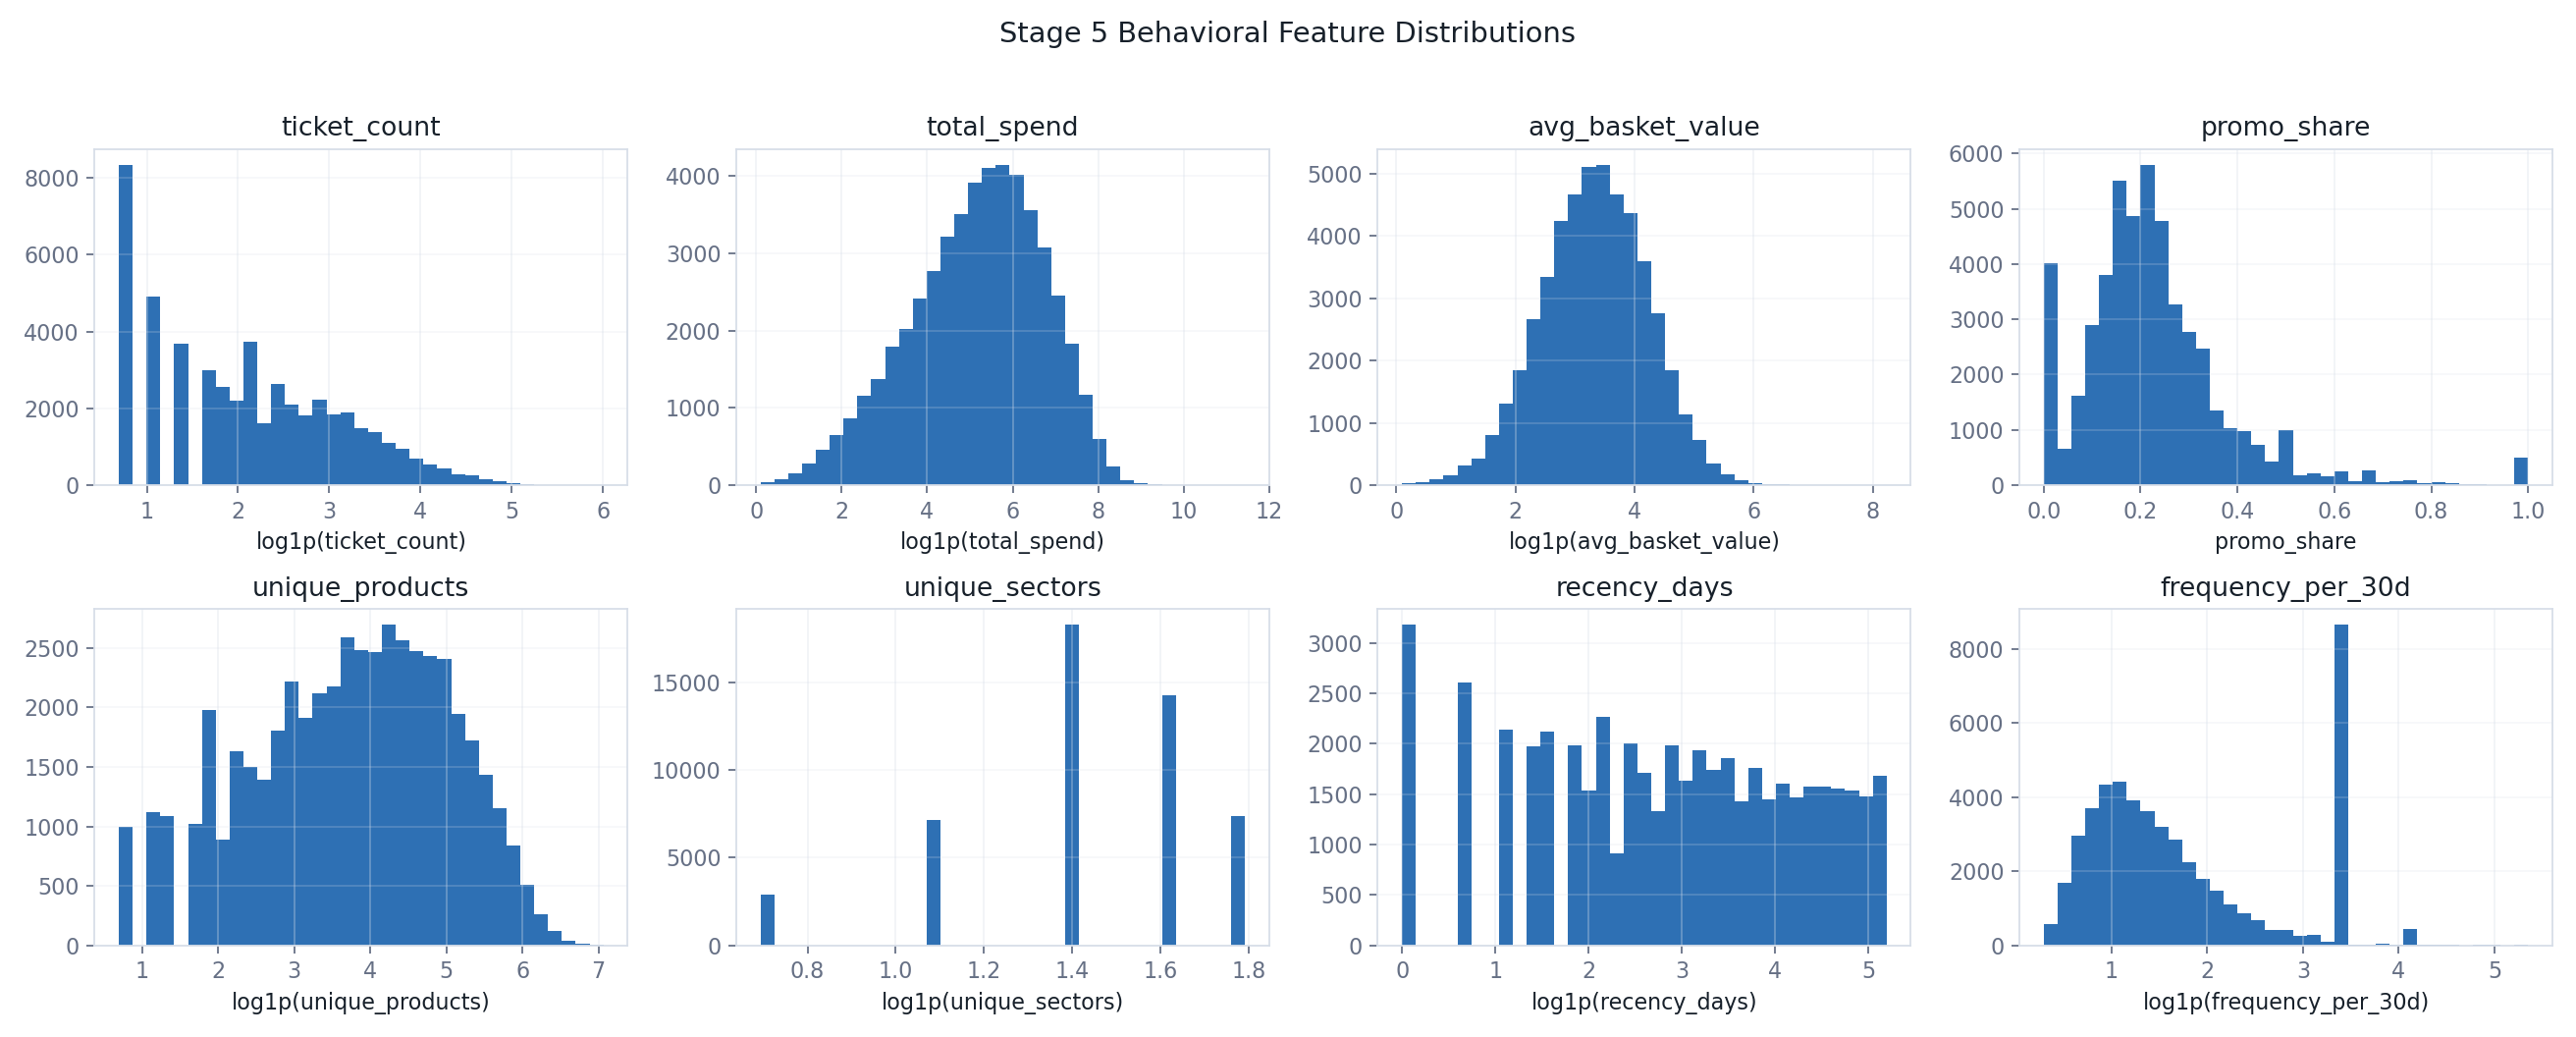

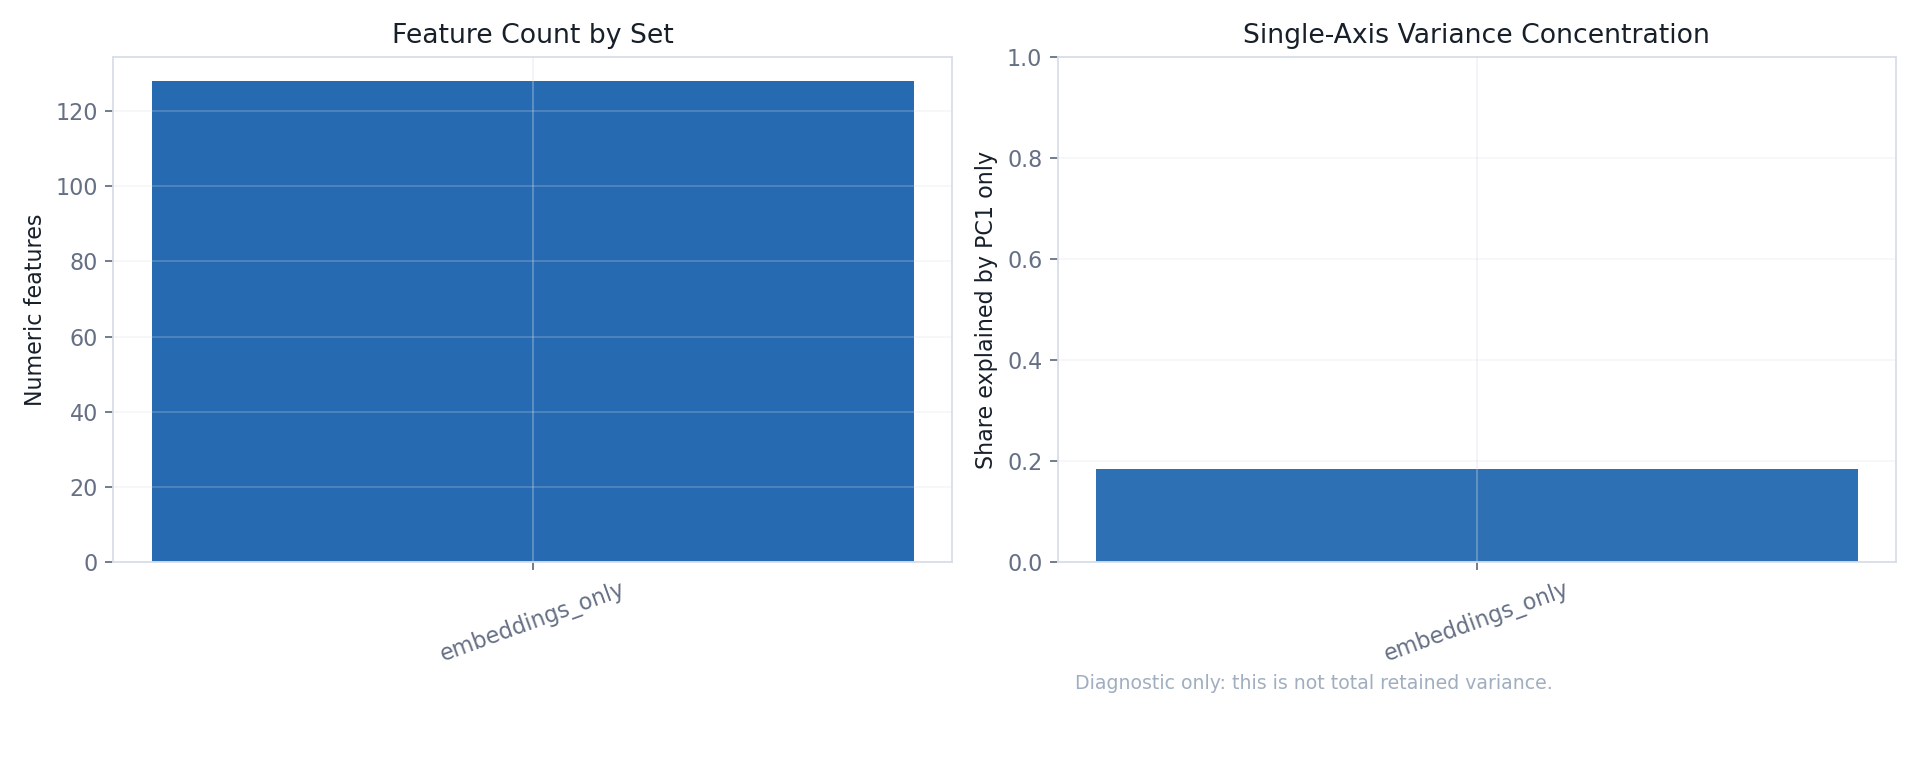

feature_set_name,is_selection_feature_set,rows,feature_count,finite_pct,null_pct,zero_variance_feature_count,customer_alignment_status,missing_vs_baseline_customers,extra_vs_baseline_customers,neighbor_overlap_vs_baseline_pct,selection_warning
str,bool,i64,i64,f64,f64,i64,str,i64,i64,f64,str
"""embeddings_only""",true,1478831,128,100.0,0.0,0,"""pass""",0,0,100.0,"""OK: official selection uses pr…"


In [8]:
from IPython.display import Image
import polars as pl

from src.feature_engineering import build_behavioral_features, build_feature_set, build_feature_set_diagnostics, build_product_exposure_features
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_behavioral_feature_summary, plot_feature_set_summary

behavior_path = build_behavioral_features(transactions=transactions, cfg=CONFIG)
selection_feature_set = CONFIG.get("modeling.feature_set_for_selection", "embeddings_only")
build_product_exposure_challenger = bool(CONFIG.get("product_exposure_features.enabled", False)) or selection_feature_set == "embeddings_product_exposure"
product_exposure_path = None
embeddings_only_feature_set = build_feature_set(customer_embeddings_path, variant="embeddings_only", cfg=CONFIG)
feature_sets = {"embeddings_only": embeddings_only_feature_set}
if build_product_exposure_challenger:
    product_exposure_path = build_product_exposure_features(transactions=transactions, cfg=CONFIG)
    feature_sets["embeddings_product_exposure"] = build_feature_set(
        customer_embeddings_path,
        product_exposure_path=product_exposure_path,
        variant="embeddings_product_exposure",
        cfg=CONFIG,
    )
stage5_behavior_figure = plot_behavioral_feature_summary(behavior_path, cfg=CONFIG)
stage5_feature_set_figure = plot_feature_set_summary(feature_sets, cfg=CONFIG)
stage5_feature_diagnostics_path = build_feature_set_diagnostics(feature_sets, cfg=CONFIG)
stage5_feature_diagnostics = pl.read_csv(stage5_feature_diagnostics_path)
stage5_diagnostic_display_cols = [
    "feature_set_name",
    "is_selection_feature_set",
    "rows",
    "feature_count",
    "finite_pct",
    "null_pct",
    "zero_variance_feature_count",
    "customer_alignment_status",
    "missing_vs_baseline_customers",
    "extra_vs_baseline_customers",
    "neighbor_overlap_vs_baseline_pct",
    "selection_warning",
]
stage5_report = write_stage_report(
    "05",
    "Official Product/Quantity Feature Set",
    summary=[
        "Official tribe selection uses embeddings_only to keep clustering product-first.",
        "Behavioral features are prepared separately for post-clustering interpretation.",
        "Product-exposure challenger features are opt-in and skipped by default to keep prod runs lean.",
    ],
    metrics={
        "feature_sets_built": len(feature_sets),
        "selection_feature_set": CONFIG.get("modeling.feature_set_for_selection", "embeddings_only"),
        "feature_diagnostics_rows": stage5_feature_diagnostics.height,
        "product_exposure_challenger_enabled": build_product_exposure_challenger,
    },
    figures={
        "Behavioral feature summary": stage5_behavior_figure,
        "Feature set summary": stage5_feature_set_figure,
    },
    artifacts={
        **{"Behavioral features": behavior_path, "Feature diagnostics": stage5_feature_diagnostics_path},
        **({"Product exposure features": product_exposure_path} if product_exposure_path is not None else {}),
        **feature_sets,
    },
    cfg=CONFIG,
)
display_stage_report(stage5_report)
display(Image(filename=str(stage5_behavior_figure)))
display(Image(filename=str(stage5_feature_set_figure)))
display(stage5_feature_diagnostics.select([c for c in stage5_diagnostic_display_cols if c in stage5_feature_diagnostics.columns]))


<a id="stage-6"></a>

## Stage 6: Customer Tribe Discovery (UMAP + HDBSCAN)

Three-pass density clustering on product embeddings. Customers who share purchasing patterns cluster together organically — no demographic inputs, no predefined labels.

- **Passes 1–3**: Each pass runs HDBSCAN on customers still unassigned from the prior pass, recovering progressively smaller niche groups.
- **Lift filter**: Only clusters where members buy certain products ≥ 2× more than average are kept as tribes.
- **Coverage rescue (6.5a)**: Remaining noise customers are soft-assigned to the nearest valid tribe centroid within the q75 intra-cluster distance bound. Rescue is for activation sizing only — product lift profiling uses core members exclusively.
- **Quality audit (6.6)**: Each cluster earns a `strong`, `usable`, or `review` readiness label before any interpretation begins.

A tribe is only claimed when density evidence, product lift, and stability all point to the same conclusion.

In [ ]:
import polars as pl
from pathlib import Path
from IPython.display import Image, Markdown, display

from src.model_selection import (
    build_candidate_model_diagnostics,
    build_official_umap_core_representation,
    build_stage6_hdbscan_diagnostics,
    build_stage6_representation_cluster_diagnostics,
    build_stage6_umap_diagnostics,
    apply_noise_rescue_soft_assignment,
    merge_official_three_stage_hdbscan_lift_core,
    model_suite_from_single_candidate,
    run_official_three_stage_hdbscan_first_pass,
    run_official_three_stage_hdbscan_second_pass,
    run_official_three_stage_hdbscan_third_pass,
)
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import (
    plot_noise_rescue_tribe_breakdown,
    plot_stage6_hdbscan_assignment_map,
    plot_stage6_noise_rescue_provenance,
    plot_stage6_quality_evidence,
    plot_stage6_umap_representation,
)

selection_feature_set = CONFIG.get("modeling.feature_set_for_selection", "embeddings_only")
if "feature_sets" not in globals():
    feature_set_outputs = CONFIG.get("feature_sets.outputs", {})
    selection_feature_filename = feature_set_outputs.get(selection_feature_set, f"feature_set_{selection_feature_set}.parquet")
    feature_sets = {
        selection_feature_set: CONFIG.outputs / "features" / selection_feature_filename,
    }
    missing_feature_sets = [path for path in feature_sets.values() if not path.exists()]
    if missing_feature_sets:
        raise FileNotFoundError(
            "Stage 6 needs the Stage 5 feature-set parquet files. "
            f"Missing: {missing_feature_sets}. Run Stage 5 first."
        )

allowed_product_feature_sets = {"embeddings_only", "embeddings_product_exposure"}
if selection_feature_set not in allowed_product_feature_sets:
    raise ValueError(
        "Official Stage 6 core tribe discovery only allows product-derived feature sets: "
        f"{sorted(allowed_product_feature_sets)}. Do not use behavior, spend, or demographic feature sets here."
    )
stage6_feature_path = feature_sets[selection_feature_set]
stage6_feature_path


### Stage 6.1: UMAP Representation Check

Build the PCA-to-UMAP customer manifold used for density clustering. PCA reduces noise before UMAP; the checks verify row alignment, dimensions, nulls, finite values, and basic neighborhood quality before HDBSCAN runs.


[19:08:46] Stage 6.1 UMAP: building product-only customer manifold | trial=u20_n75_leaf_mcs3000_ms6_core, pca_components=64, components=20, n_neighbors=75
[19:08:46] Stage 6 PCA: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\feature_set_pca_for_umap.parquet, summary=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_1_pca_for_umap_summary.csv
[19:09:03] Stage 6 UMAP: cache hit | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\features\feature_set_umap_pca64_u20_n75.parquet
[19:09:04] Stage 6.1 checks: wrote UMAP representation diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_1_umap_checks.csv
[19:09:05] Stage 6.1 figures: wrote UMAP representation preview | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage6_1_umap_representation.png


purpose,dimension_reduction,requested_component_count,retained_component_count,retained_variance_pct,pc1_variance_pct,pc5_cumulative_variance_pct,pc10_cumulative_variance_pct
str,str,i64,i64,f64,f64,f64,f64
"""Pre-reduce standardized custom…","""128 -> 64""",64,64,86.86,14.42,37.17,50.13


stage,check_status,check_issues,feature_path,umap_path,source_rows,umap_rows,missing_feature_customers,extra_umap_customers,duplicate_umap_customers,source_feature_count,umap_component_count,requested_umap_components,umap_n_neighbors,umap_metric,umap_min_dist,finite_pct,null_pct,zero_variance_component_count,pca_pre_reduction_summary_status,pca_summary_path,pca_purpose,pca_dimension_reduction,pca_input_dimension_count,pca_requested_component_count,pca_retained_component_count,pca_retained_variance_pct,pca_pc1_variance_pct,pca_pc5_cumulative_variance_pct,pca_pc10_cumulative_variance_pct
str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,f64,f64,f64,i64,str,str,str,str,i64,i64,i64,f64,f64,f64,f64
"""6.1_umap_representation""","""pass""","""pass""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",1478831,1478831,0,0,0,128,20,20,75,"""cosine""",0.0,100.0,0.0,0,"""present""","""C:\Users\rothl\Desktop\IE Caps…","""Pre-reduce standardized custom…","""128 -> 64""",128,64,64,86.858121,14.422275,37.170454,50.134154


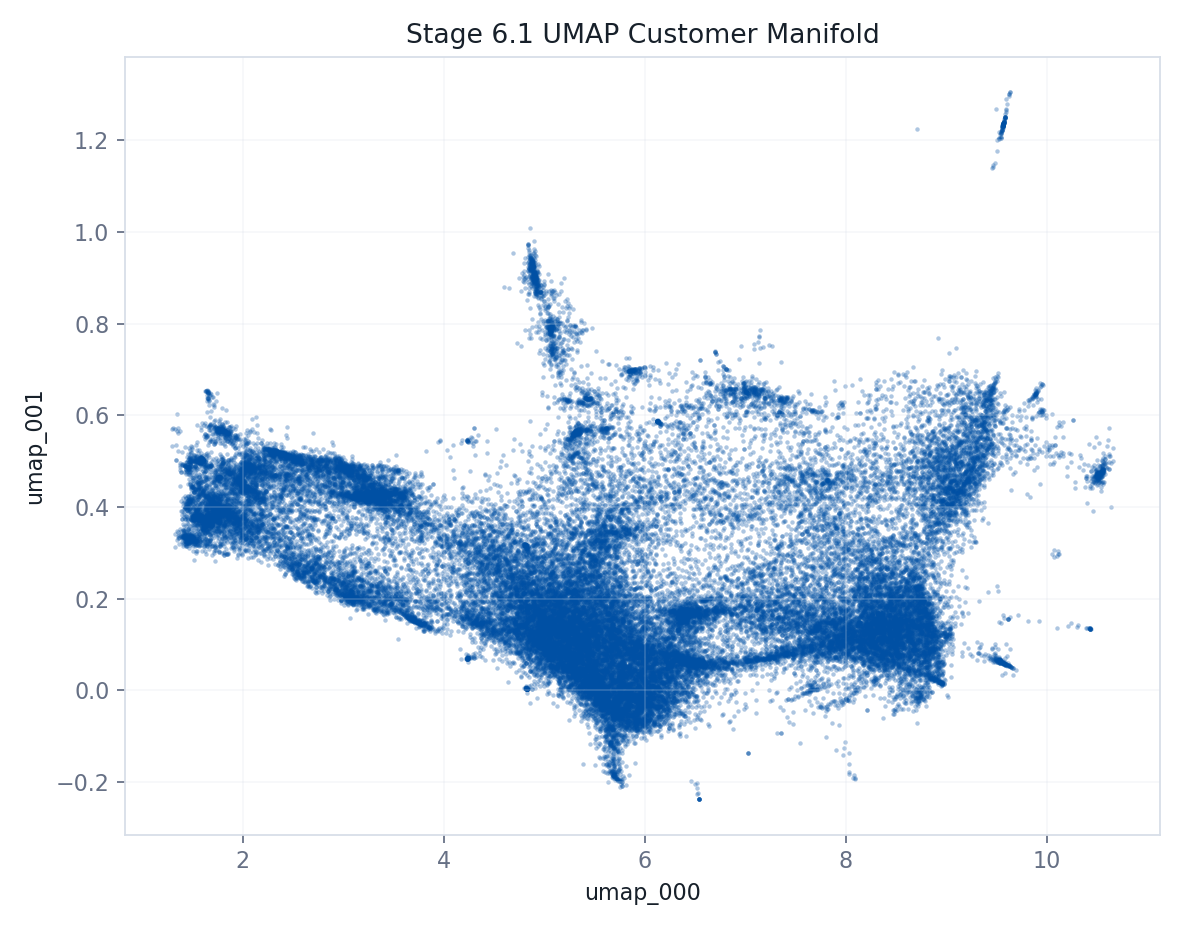

In [10]:
stage6_umap_path = build_official_umap_core_representation(stage6_feature_path, cfg=CONFIG)
stage6_umap_checks_path = build_stage6_umap_diagnostics(stage6_feature_path, stage6_umap_path, cfg=CONFIG)
stage6_umap_checks = pl.read_csv(stage6_umap_checks_path)
stage6_pca_summary_path = CONFIG.artifacts / "stage6" / "stage6_1_pca_for_umap_summary.csv"
stage6_pca_summary = pl.read_csv(stage6_pca_summary_path)
stage6_pca_overview = stage6_pca_summary.select(
    [
        "purpose",
        "dimension_reduction",
        "requested_component_count",
        "retained_component_count",
        pl.col("retained_variance_pct").round(2),
        pl.col("pc1_variance_pct").round(2),
        pl.col("pc5_cumulative_variance_pct").round(2),
        pl.col("pc10_cumulative_variance_pct").round(2),
    ]
)
stage6_umap_figure = plot_stage6_umap_representation(stage6_umap_path, cfg=CONFIG)

display(stage6_pca_overview)
display(stage6_umap_checks)
display(Image(filename=str(stage6_umap_figure)))
if stage6_umap_checks[0, "check_status"] != "pass":
    raise ValueError(f"Stage 6.1 UMAP checks failed: {stage6_umap_checks[0, 'check_issues']}")


### Stage 6.2: First Hard HDBSCAN Pass

Run hard HDBSCAN on the full UMAP representation. This finds the first core tribes and leaves uncertain customers as first-pass noise for separate review.


[19:09:05] Stage 6 HDBSCAN: cache hit | results=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\model_selection\model_e_three_stage_hdbscan_lift_core_stage1_results.parquet
[19:09:06] Stage 6.2 checks: wrote hard HDBSCAN diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_2_first_hdbscan_checks.csv
[19:09:07] Stage 6.2 figures: wrote hard HDBSCAN assignment map | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage_06_2_first_hdbscan_assignment_map.png


stage,check_status,check_issues,blocking_check_status,blocking_check_issues,quality_gate_status,quality_gate_issues,umap_path,assignment_path,result_path,umap_rows,assignment_rows,missing_umap_customers,extra_assignment_customers,duplicate_assignment_customers,cluster_count,assigned_customers,noise_customers,noise_pct,core_coverage_pct,assignment_policy,soft_assignment_enabled,soft_assigned_pct,soft_assignment_source_rows,passes_quality_gate,quality_gate_reason
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,bool,f64,i64,bool,str
"""6.2_first_hdbscan""","""fail""","""noise_pct>60.0""","""pass""","""pass""","""fail""","""noise_pct>60.0""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",1478831,1478831,0,0,0,8,410399,1068432,72.2484,27.7516,"""hard_hdbscan_core_noise_retain…",false,0.0,0,false,"""noise_pct>60.0"""


assignment_source,customers
str,u32
"""hdbscan_noise_unassigned""",1068432
"""hdbscan_approximate_predict""",410399


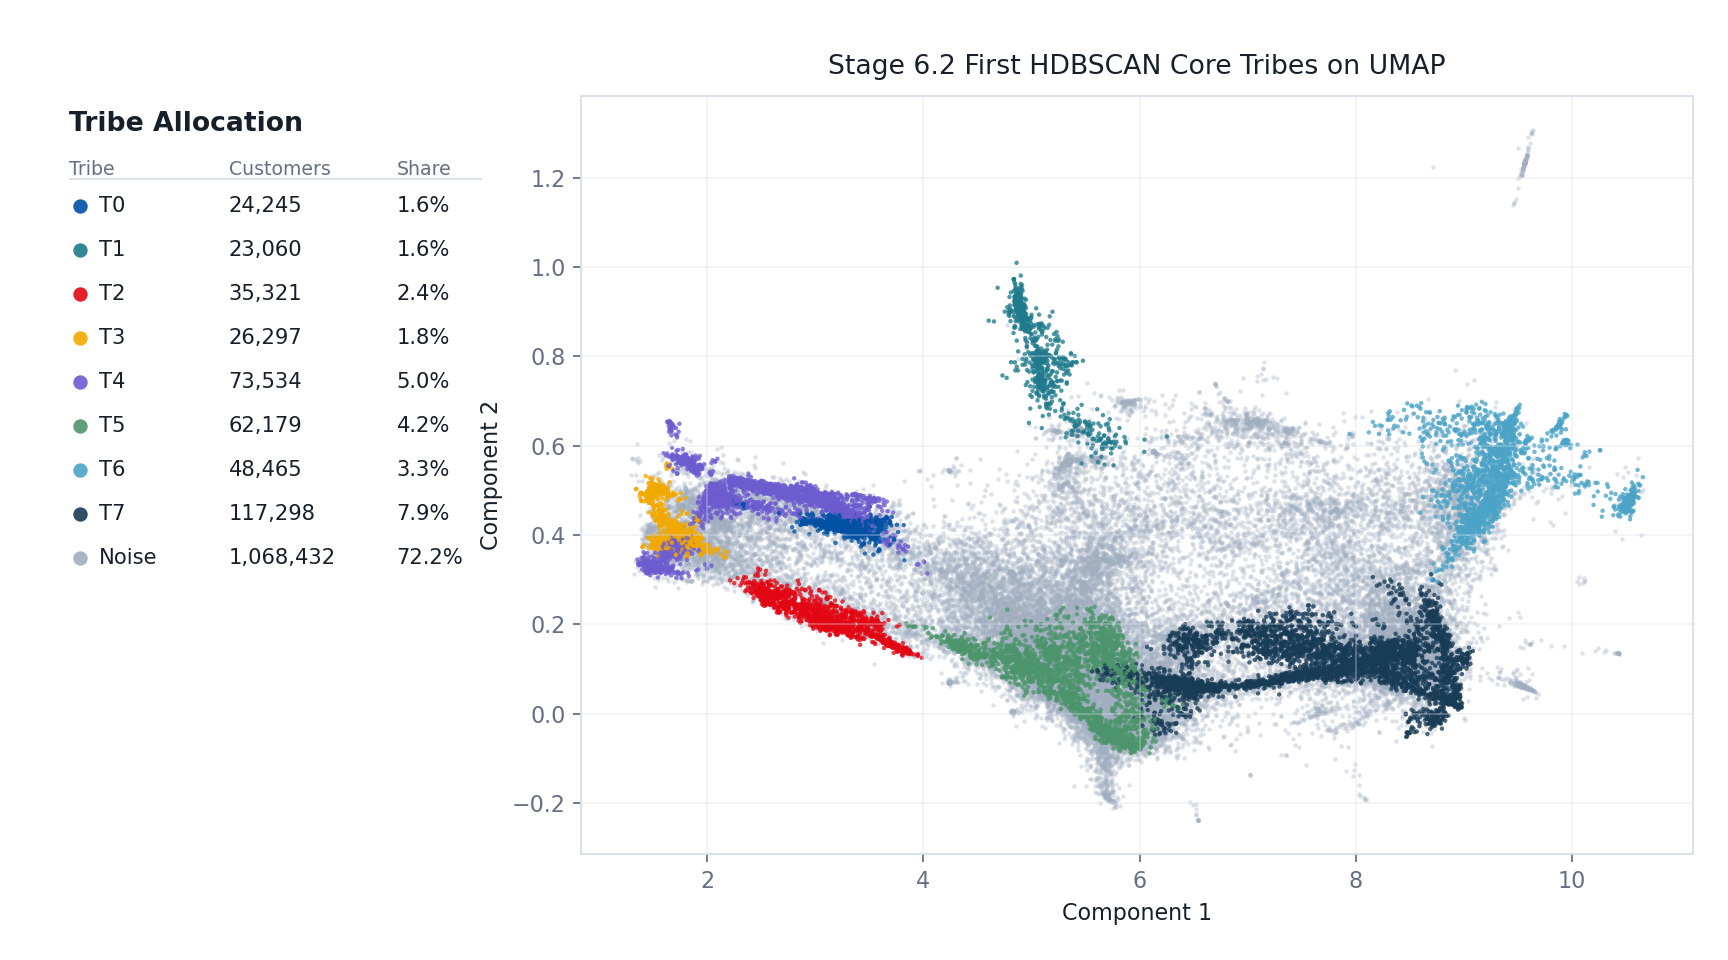

In [11]:
stage6_stage1_assignment_path, stage6_stage1_result_path, stage6_stage1_candidate = run_official_three_stage_hdbscan_first_pass(
    stage6_umap_path,
    cfg=CONFIG,
)
stage6_stage1_checks_path = build_stage6_hdbscan_diagnostics(
    stage6_umap_path,
    stage6_stage1_assignment_path,
    stage6_stage1_result_path,
    output_path=CONFIG.artifacts / "stage6" / "stage6_2_first_hdbscan_checks.csv",
    stage_name="6.2_first_hdbscan",
    cfg=CONFIG,
)
stage6_stage1_checks = pl.read_csv(stage6_stage1_checks_path)
stage6_stage1_assignment_source_table = (
    pl.read_parquet(stage6_stage1_assignment_path)
    .group_by("assignment_source")
    .agg(pl.len().alias("customers"))
    .sort("customers", descending=True)
)
stage6_stage1_figure = plot_stage6_hdbscan_assignment_map(
    stage6_umap_path,
    stage6_stage1_assignment_path,
    output_path=CONFIG.figures / "stage_06_2_first_hdbscan_assignment_map.png",
    title="Stage 6.2 First HDBSCAN Core Tribes on UMAP",
    cfg=CONFIG,
)

display(stage6_stage1_checks)
display(stage6_stage1_assignment_source_table)
display(Image(filename=str(stage6_stage1_figure)))
blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_stage1_checks.columns else "check_status"
blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_stage1_checks.columns else "check_issues"
if stage6_stage1_checks[0, blocking_status_col] != "pass":
    raise ValueError(f"Stage 6.2 first HDBSCAN structural checks failed: {stage6_stage1_checks[0, blocking_issues_col]}")


### Stage 6.3: Second HDBSCAN Pass Over First-Pass Noise

Run a stricter HDBSCAN only on first-pass noise. This can recover dense niche groups, but customers remain unassigned unless a real density pocket is found.


[19:09:08] Stage 6 HDBSCAN: cache hit | results=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\model_selection\model_e_three_stage_hdbscan_lift_core_stage2_noise_results.parquet
[19:09:08] Stage 6.2 checks: wrote hard HDBSCAN diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_3_second_noise_hdbscan_checks.csv
[19:09:10] Stage 6.2 figures: wrote hard HDBSCAN assignment map | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage_06_3_second_noise_hdbscan_assignment_map.png


stage,check_status,check_issues,blocking_check_status,blocking_check_issues,quality_gate_status,quality_gate_issues,umap_path,assignment_path,result_path,umap_rows,assignment_rows,missing_umap_customers,extra_assignment_customers,duplicate_assignment_customers,cluster_count,assigned_customers,noise_customers,noise_pct,core_coverage_pct,assignment_policy,soft_assignment_enabled,soft_assigned_pct,soft_assignment_source_rows,passes_quality_gate,quality_gate_reason
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,bool,f64,i64,bool,str
"""6.3_second_noise_hdbscan""","""fail""","""noise_pct>60.0""","""pass""","""pass""","""fail""","""noise_pct>60.0""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",1068432,1068432,0,0,0,8,205510,862922,80.7653,19.2347,"""hard_hdbscan_core_noise_retain…",false,0.0,0,false,"""noise_pct>60.0"""


assignment_source,customers
str,u32
"""hdbscan_noise_unassigned""",862922
"""hdbscan_approximate_predict""",205510


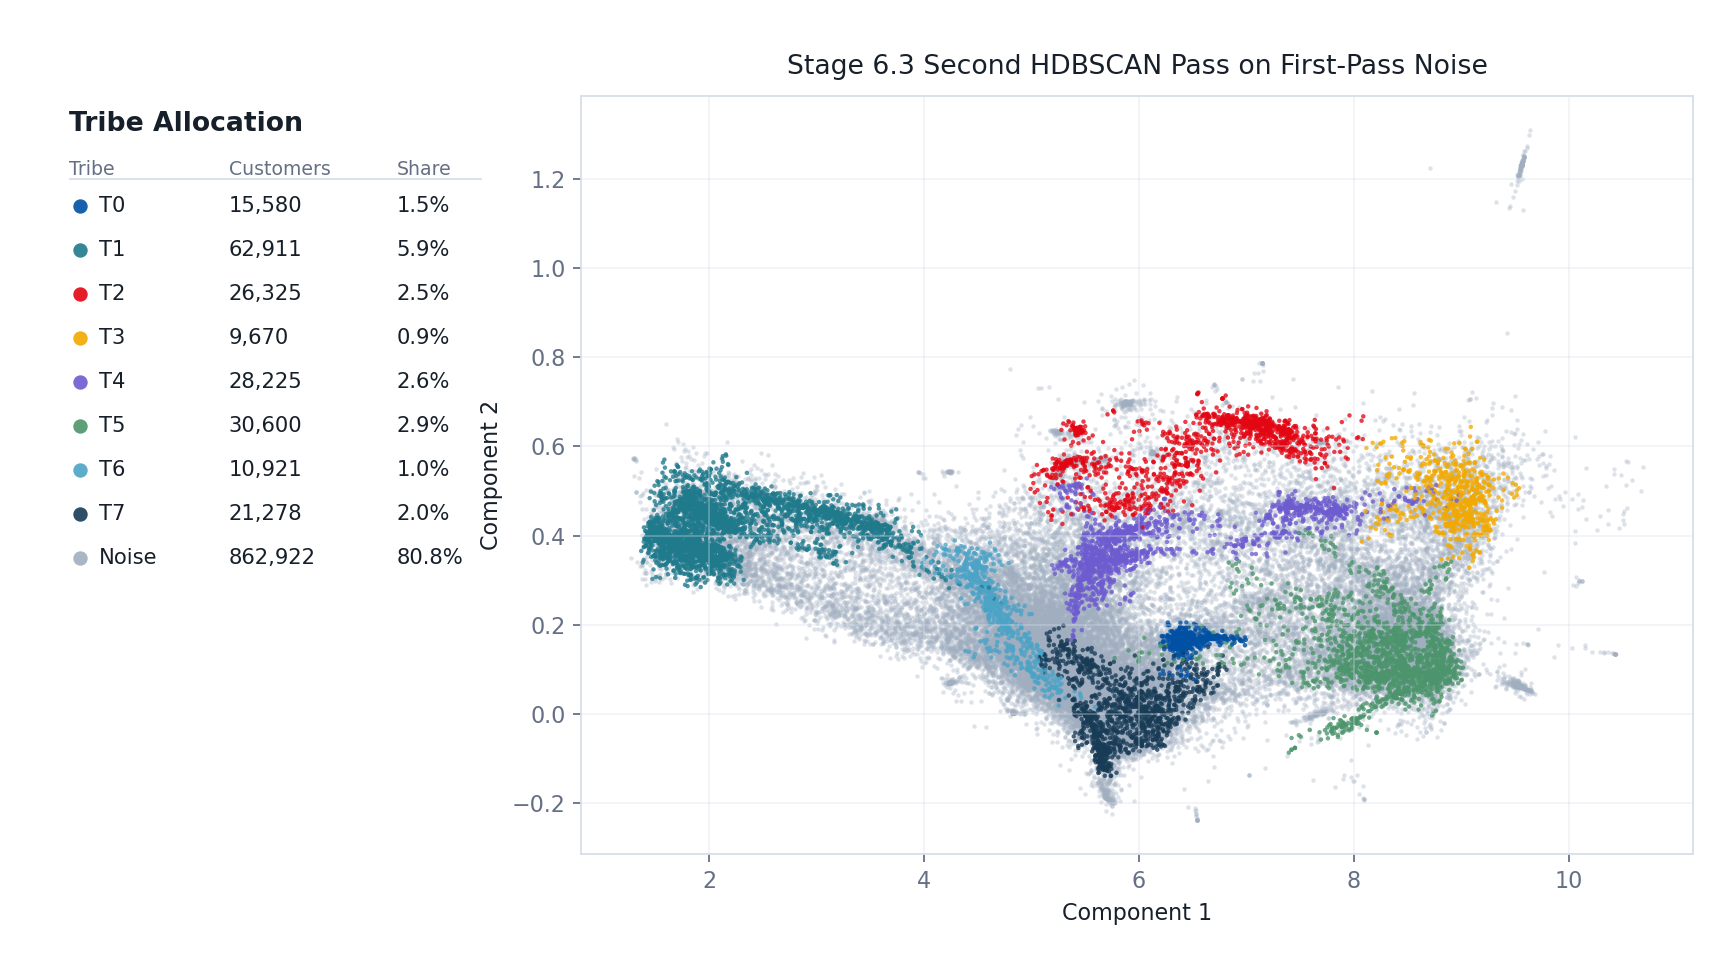

In [12]:
(
    stage6_stage2_noise_feature_path,
    stage6_stage2_noise_customers,
    stage6_stage2_assignment_path,
    stage6_stage2_result_path,
    stage6_stage2_candidate,
) = run_official_three_stage_hdbscan_second_pass(
    stage6_umap_path,
    stage1_assignment_path=stage6_stage1_assignment_path,
    cfg=CONFIG,
)

if stage6_stage2_assignment_path is not None and stage6_stage2_result_path is not None:
    stage6_stage2_checks_path = build_stage6_hdbscan_diagnostics(
        stage6_stage2_noise_feature_path,
        stage6_stage2_assignment_path,
        stage6_stage2_result_path,
        output_path=CONFIG.artifacts / "stage6" / "stage6_3_second_noise_hdbscan_checks.csv",
        stage_name="6.3_second_noise_hdbscan",
        cfg=CONFIG,
    )
    stage6_stage2_checks = pl.read_csv(stage6_stage2_checks_path)
    stage6_stage2_assignment_source_table = (
        pl.read_parquet(stage6_stage2_assignment_path)
        .group_by("assignment_source")
        .agg(pl.len().alias("customers"))
        .sort("customers", descending=True)
    )
    stage6_stage2_figure = plot_stage6_hdbscan_assignment_map(
        stage6_stage2_noise_feature_path,
        stage6_stage2_assignment_path,
        output_path=CONFIG.figures / "stage_06_3_second_noise_hdbscan_assignment_map.png",
        title="Stage 6.3 Second HDBSCAN Pass on First-Pass Noise",
        cfg=CONFIG,
    )
    display(stage6_stage2_checks)
    display(stage6_stage2_assignment_source_table)
    display(Image(filename=str(stage6_stage2_figure)))
    blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_stage2_checks.columns else "check_status"
    blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_stage2_checks.columns else "check_issues"
    if stage6_stage2_checks[0, blocking_status_col] != "pass":
        raise ValueError(f"Stage 6.3 second HDBSCAN structural checks failed: {stage6_stage2_checks[0, blocking_issues_col]}")
else:
    stage6_stage2_checks_path = None
    stage6_stage2_figure = None
    stage6_stage2_assignment_source_table = pl.DataFrame()
    stage6_stage2_checks = pl.DataFrame([
        {
            "stage": "6.3_second_noise_hdbscan",
            "check_status": "skipped",
            "check_issues": "first-pass noise below second-pass min_cluster_size",
            "noise_customers": stage6_stage2_noise_customers,
        }
    ])
    display(Markdown(
        f"Stage 6.3 skipped: first-pass noise customers ({stage6_stage2_noise_customers:,}) "
        "are below the configured second-pass min_cluster_size."
    ))
    display(stage6_stage2_checks)


### Stage 6.4: Third Hard HDBSCAN Pass Over Remaining Noise

Run one final hard HDBSCAN pass on customers still unassigned after Stage 6.3. This is a last chance to find dense remaining pockets; the later merge and product-lift filter still decide whether those pockets are retained.


[19:09:12] Stage 6 HDBSCAN: cache hit | results=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\model_selection\model_e_three_stage_hdbscan_lift_core_stage3_remaining_noise_results.parquet
[19:09:13] Stage 6.2 checks: wrote hard HDBSCAN diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_4_third_remaining_noise_hdbscan_checks.csv
[19:09:13] Stage 6.2 figures: wrote hard HDBSCAN assignment map | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage_06_4_third_remaining_noise_hdbscan_assignment_map.png


stage,check_status,check_issues,blocking_check_status,blocking_check_issues,quality_gate_status,quality_gate_issues,umap_path,assignment_path,result_path,umap_rows,assignment_rows,missing_umap_customers,extra_assignment_customers,duplicate_assignment_customers,cluster_count,assigned_customers,noise_customers,noise_pct,core_coverage_pct,assignment_policy,soft_assignment_enabled,soft_assigned_pct,soft_assignment_source_rows,passes_quality_gate,quality_gate_reason
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,bool,f64,i64,bool,str
"""6.4_third_remaining_noise_hdbs…","""fail""","""noise_pct>60.0""","""pass""","""pass""","""fail""","""noise_pct>60.0""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",862922,862922,0,0,0,6,60932,801990,92.9389,7.0611,"""hard_hdbscan_core_noise_retain…",false,0.0,0,false,"""noise_pct>60.0"""


assignment_source,customers
str,u32
"""hdbscan_noise_unassigned""",801990
"""hdbscan_approximate_predict""",60932


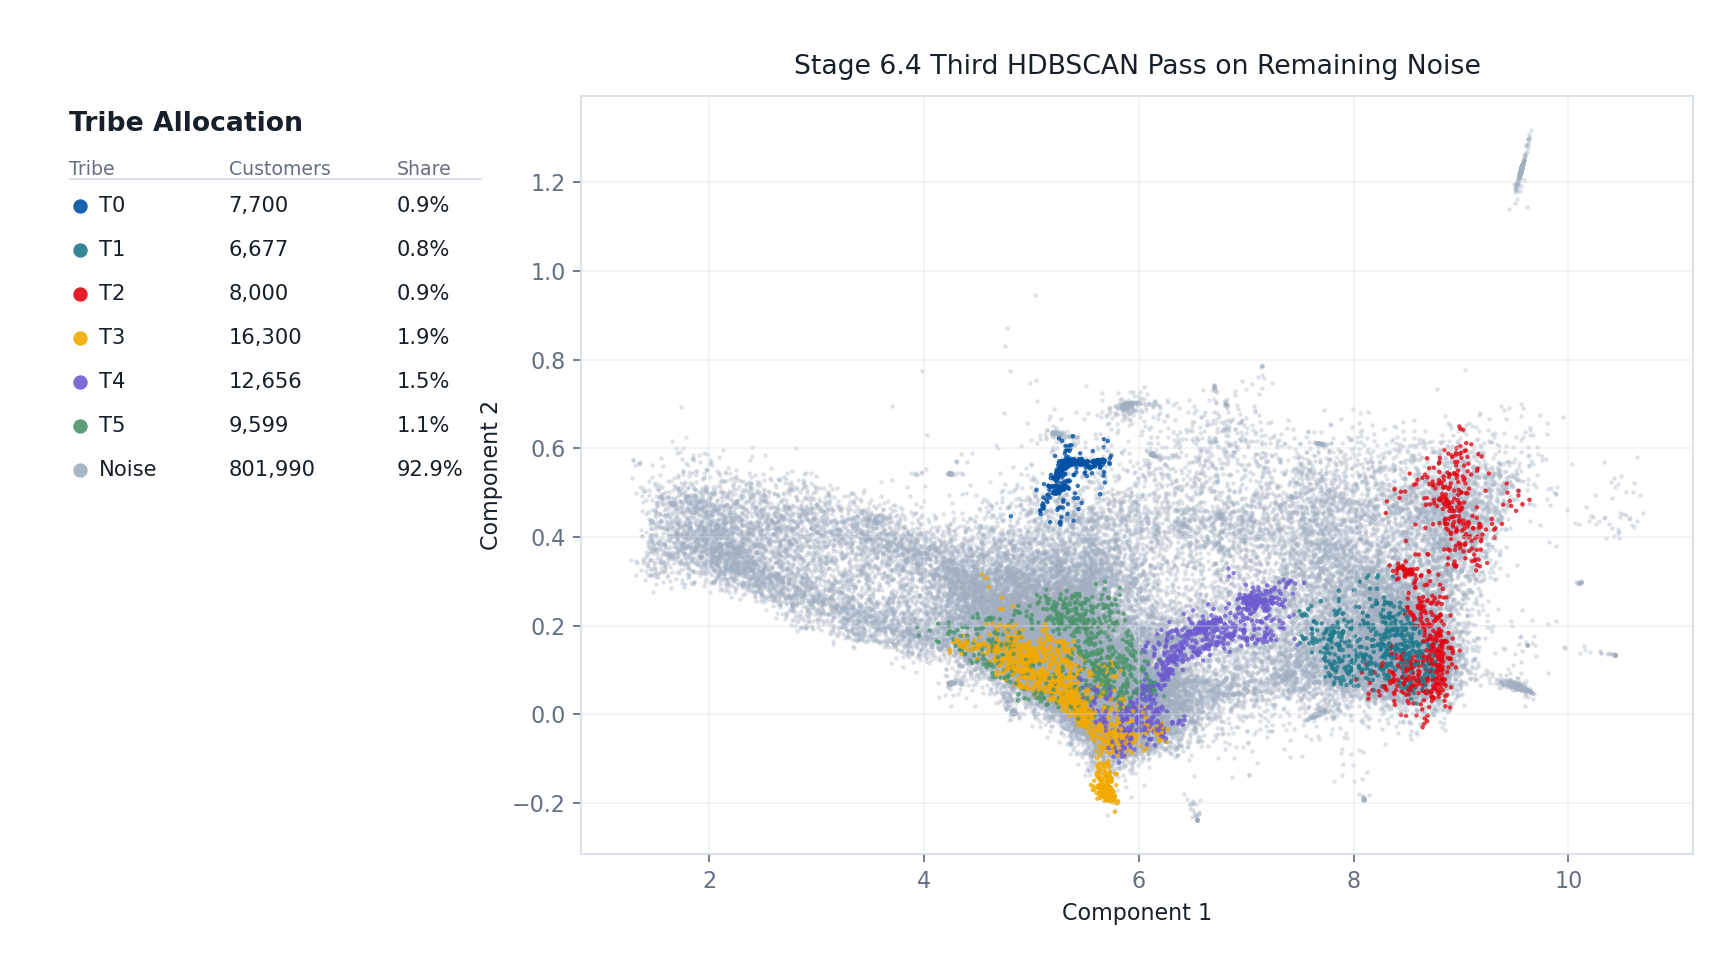

In [13]:
(
    stage6_stage3_noise_feature_path,
    stage6_stage3_noise_customers,
    stage6_stage3_assignment_path,
    stage6_stage3_result_path,
    stage6_stage3_candidate,
) = run_official_three_stage_hdbscan_third_pass(
    stage6_umap_path,
    stage1_assignment_path=stage6_stage1_assignment_path,
    stage2_assignment_path=stage6_stage2_assignment_path,
    cfg=CONFIG,
)

if stage6_stage3_assignment_path is not None and stage6_stage3_result_path is not None:
    stage6_stage3_checks_path = build_stage6_hdbscan_diagnostics(
        stage6_stage3_noise_feature_path,
        stage6_stage3_assignment_path,
        stage6_stage3_result_path,
        output_path=CONFIG.artifacts / "stage6" / "stage6_4_third_remaining_noise_hdbscan_checks.csv",
        stage_name="6.4_third_remaining_noise_hdbscan",
        cfg=CONFIG,
    )
    stage6_stage3_checks = pl.read_csv(stage6_stage3_checks_path)
    stage6_stage3_assignment_source_table = (
        pl.read_parquet(stage6_stage3_assignment_path)
        .group_by("assignment_source")
        .agg(pl.len().alias("customers"))
        .sort("customers", descending=True)
    )
    stage6_stage3_figure = plot_stage6_hdbscan_assignment_map(
        stage6_stage3_noise_feature_path,
        stage6_stage3_assignment_path,
        output_path=CONFIG.figures / "stage_06_4_third_remaining_noise_hdbscan_assignment_map.png",
        title="Stage 6.4 Third HDBSCAN Pass on Remaining Noise",
        cfg=CONFIG,
    )
    display(stage6_stage3_checks)
    display(stage6_stage3_assignment_source_table)
    display(Image(filename=str(stage6_stage3_figure)))
    blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_stage3_checks.columns else "check_status"
    blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_stage3_checks.columns else "check_issues"
    if stage6_stage3_checks[0, blocking_status_col] != "pass":
        raise ValueError(f"Stage 6.4 third HDBSCAN structural checks failed: {stage6_stage3_checks[0, blocking_issues_col]}")
else:
    stage6_stage3_checks_path = None
    stage6_stage3_figure = None
    stage6_stage3_assignment_source_table = pl.DataFrame()
    stage6_stage3_checks = pl.DataFrame([
        {
            "stage": "6.4_third_remaining_noise_hdbscan",
            "check_status": "skipped",
            "check_issues": "remaining second-pass noise below third-pass minimum",
            "noise_customers": stage6_stage3_noise_customers,
        }
    ])
    display(Markdown(
        f"Stage 6.4 skipped: remaining second-pass noise customers ({stage6_stage3_noise_customers:,}) "
        "are below the configured third-pass minimum."
    ))
    display(stage6_stage3_checks)


### Stage 6.5: Merge Three Passes and Apply Product-Lift Filter

Merge retained clusters from the three HDBSCAN passes, then keep only clusters with enough strong significant product-lift evidence. Unsupported candidate clusters and residual noise stay unassigned.


[19:09:13] Stage 6.5 three-stage merge: cache hit | results=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\models\model_selection\model_e_three_stage_hdbscan_lift_core_results.parquet
[19:09:14] Stage 6.2 checks: wrote hard HDBSCAN diagnostics | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_5_merged_three_stage_hdbscan_checks.csv
[19:09:16] Stage 6.2 figures: wrote hard HDBSCAN assignment map | path=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\figures\stage_06_5_merged_three_stage_hdbscan_assignment_map.png


stage,check_status,check_issues,blocking_check_status,blocking_check_issues,quality_gate_status,quality_gate_issues,umap_path,assignment_path,result_path,umap_rows,assignment_rows,missing_umap_customers,extra_assignment_customers,duplicate_assignment_customers,cluster_count,assigned_customers,noise_customers,noise_pct,core_coverage_pct,assignment_policy,soft_assignment_enabled,soft_assigned_pct,soft_assignment_source_rows,passes_quality_gate,quality_gate_reason
str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,bool,f64,i64,bool,str
"""6.5_merged_three_stage_lift_co…","""pass""","""pass""","""pass""","""pass""","""pass""","""pass""","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…","""C:\Users\rothl\Desktop\IE Caps…",1478831,1478831,0,0,0,22,676841,801990,54.2313,45.7687,"""hard_three_stage_hdbscan_lift_…",false,0.0,0,true,"""pass"""


assignment_source,customers
str,u32
"""three_stage_hdbscan_noise_unas…",801990
"""three_stage_hdbscan_stage1_cor…",410399
"""three_stage_hdbscan_stage2_noi…",205510
"""three_stage_hdbscan_stage3_rem…",60932


tribe_id,n_customers,strong_product_lift_threshold,min_strong_product_lifts,require_significant_product_lift,strong_product_lift_count,significant_strong_product_lift_count,passes_lift_filter
i64,i64,f64,i64,bool,i64,i64,bool
0,24245,1.5,2,true,15,15,true
1,23060,1.5,2,true,15,15,true
2,35321,1.5,2,true,15,15,true
3,26297,1.5,2,true,15,15,true
4,73534,1.5,2,true,15,15,true
…,…,…,…,…,…,…,…
17,6677,1.5,2,true,15,15,true
18,8000,1.5,2,true,15,15,true
19,16300,1.5,2,true,15,15,true


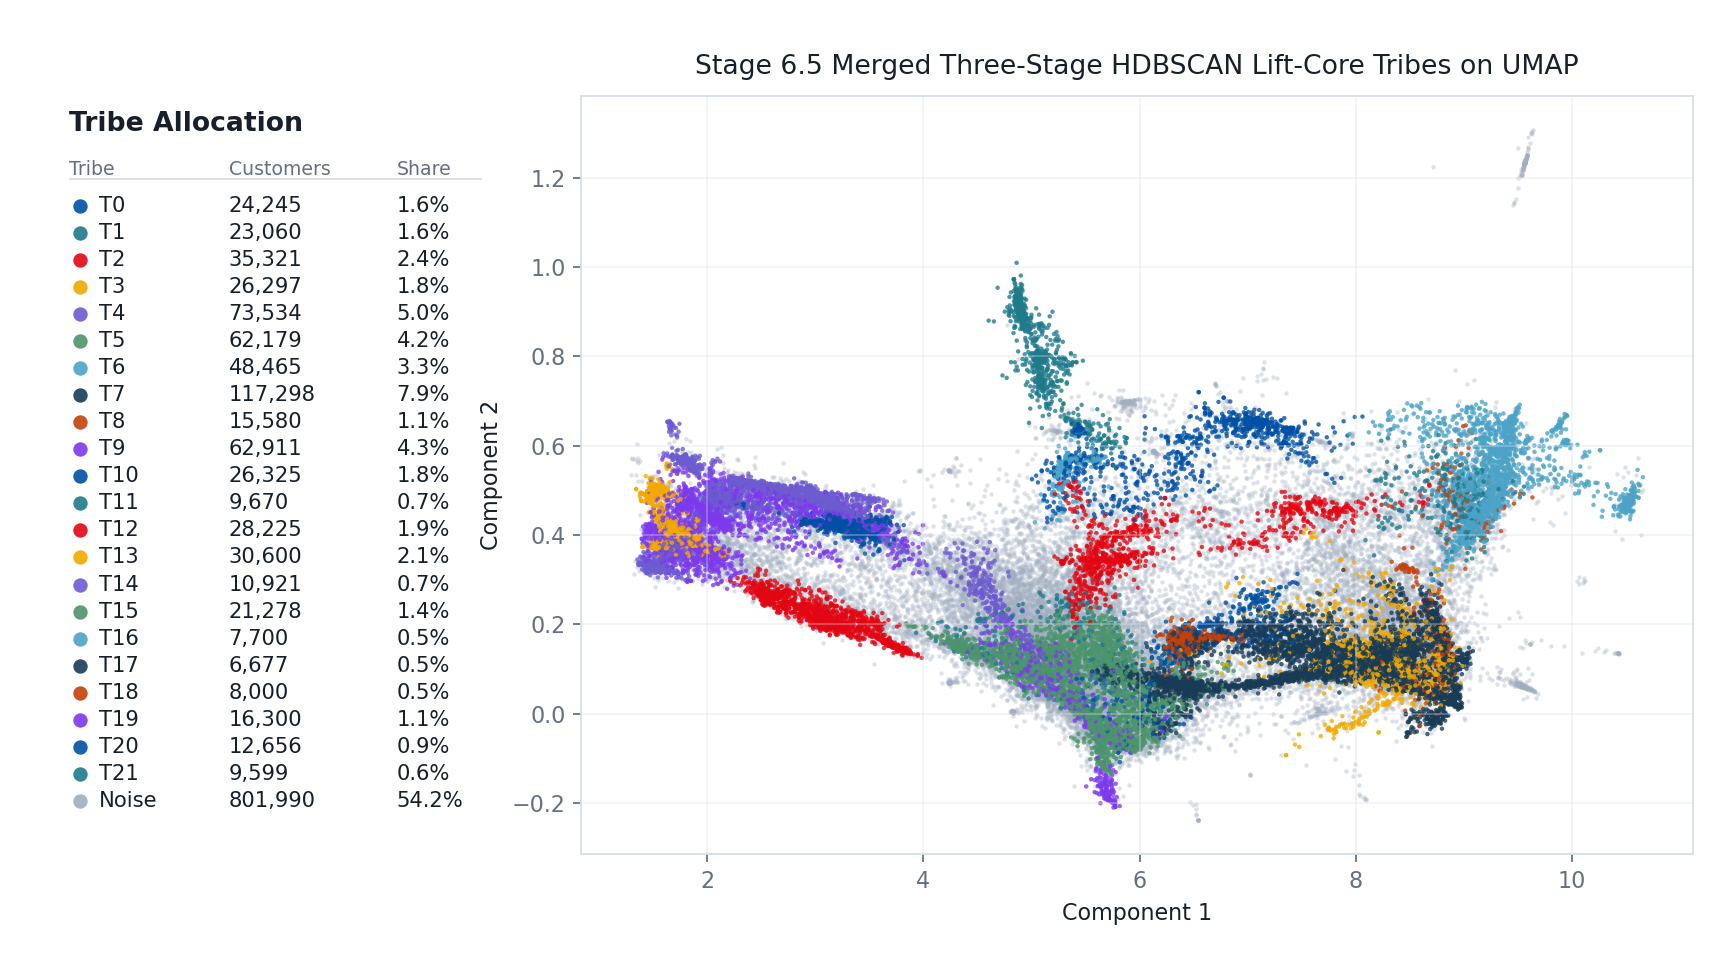

In [14]:
stage6_assignment_path, stage6_result_path, stage6_core_candidate = merge_official_three_stage_hdbscan_lift_core(
    stage6_feature_path,
    stage6_umap_path,
    stage1_assignment_path=stage6_stage1_assignment_path,
    stage1_results_path=stage6_stage1_result_path,
    stage2_assignment_path=stage6_stage2_assignment_path,
    stage2_results_path=stage6_stage2_result_path,
    stage2_noise_feature_path=stage6_stage2_noise_feature_path,
    stage2_noise_customers=stage6_stage2_noise_customers,
    stage3_assignment_path=stage6_stage3_assignment_path,
    stage3_results_path=stage6_stage3_result_path,
    stage3_noise_feature_path=stage6_stage3_noise_feature_path,
    stage3_noise_customers=stage6_stage3_noise_customers,
    cfg=CONFIG,
)
stage6_hdbscan_checks_path = build_stage6_hdbscan_diagnostics(
    stage6_umap_path,
    stage6_assignment_path,
    stage6_result_path,
    output_path=CONFIG.artifacts / "stage6" / "stage6_5_merged_three_stage_hdbscan_checks.csv",
    stage_name="6.5_merged_three_stage_lift_core",
    cfg=CONFIG,
)
stage6_hdbscan_checks = pl.read_csv(stage6_hdbscan_checks_path)
stage6_assignment_source_table = (
    pl.read_parquet(stage6_assignment_path)
    .group_by("assignment_source")
    .agg(pl.len().alias("customers"))
    .sort("customers", descending=True)
)
stage6_lift_evidence_path = stage6_core_candidate.get("lift_filter_evidence_csv_path")
stage6_lift_evidence = pl.read_csv(stage6_lift_evidence_path) if stage6_lift_evidence_path else pl.DataFrame()
stage6_assignment_figure = plot_stage6_hdbscan_assignment_map(
    stage6_umap_path,
    stage6_assignment_path,
    output_path=CONFIG.figures / "stage_06_5_merged_three_stage_hdbscan_assignment_map.png",
    title="Stage 6.5 Merged Three-Stage HDBSCAN Lift-Core Tribes on UMAP",
    cfg=CONFIG,
)

display(stage6_hdbscan_checks)
display(stage6_assignment_source_table)
if not stage6_lift_evidence.is_empty():
    display(stage6_lift_evidence)
display(Image(filename=str(stage6_assignment_figure)))
blocking_status_col = "blocking_check_status" if "blocking_check_status" in stage6_hdbscan_checks.columns else "check_status"
blocking_issues_col = "blocking_check_issues" if "blocking_check_issues" in stage6_hdbscan_checks.columns else "check_issues"
if stage6_hdbscan_checks[0, blocking_status_col] != "pass":
    raise ValueError(f"Stage 6.5 merged HDBSCAN structural checks failed: {stage6_hdbscan_checks[0, blocking_issues_col]}")


### Stage 6.5a: Post-Hoc Coverage Rescue (Activation Layer)

After the three hard HDBSCAN passes and the product-lift filter, customers still at `tribe_id = -1` are assigned to the nearest valid tribe centroid in 20-D UMAP space. A customer is rescued only if its centroid distance falls within the q75 intra-cluster threshold.

**This is an activation layer, not tribe discovery.** Hard HDBSCAN assignments are unchanged. Rescued customers are used for:
- Dashboard coverage counts (total tribe reach)
- Campaign audience sizing (Stage 7.7)

They are **excluded** from product lift profiling (Stage 6.8) to avoid diluting tribe distinctiveness.

In [ ]:
stage6_activation_assignment_path, stage6_noise_rescue_stats = apply_noise_rescue_soft_assignment(
    stage6_assignment_path,
    stage6_umap_path,
    cfg=CONFIG,
)
stage6_activation_assignment_path = Path(stage6_activation_assignment_path)
stage6_noise_rescue_assignment_path = Path(
    stage6_noise_rescue_stats.get("noise_rescue_path", stage6_activation_assignment_path)
)
stage6_core_profile_assignment_path = Path(
    stage6_noise_rescue_stats.get("core_only_path", stage6_assignment_path)
)
stage6_noise_rescue_summary = pl.DataFrame([stage6_noise_rescue_stats])
stage6_activation_source_table = (
    pl.read_parquet(stage6_activation_assignment_path)
    .group_by("assignment_source")
    .agg(pl.len().alias("customers"))
    .sort("customers", descending=True)
)
stage6_noise_rescue_provenance_figure = plot_stage6_noise_rescue_provenance(
    stage6_umap_path,
    stage6_activation_assignment_path,
    output_path=CONFIG.figures / "stage_06_5a_noise_rescue_provenance.png",
    title="Stage 6.5a Coverage Rescue - Activation Layer Only",
    cfg=CONFIG,
)
stage6_noise_rescue_breakdown_figure = plot_noise_rescue_tribe_breakdown(
    stage6_activation_assignment_path,
    output_path=CONFIG.figures / "stage_06_5a_noise_rescue_tribe_breakdown.png",
    cfg=CONFIG,
)

display(stage6_noise_rescue_summary)
display(stage6_activation_source_table)
display(Image(filename=str(stage6_noise_rescue_provenance_figure)))
display(Image(filename=str(stage6_noise_rescue_breakdown_figure)))


### Stage 6 Quality Evidence: Representation and Density

After the merged hard assignment exists, write compact evidence about representation quality, density validity, noise, balance, and core-only separation. This is model-quality context before the cluster-level readiness audit.


In [ ]:
model_suite = model_suite_from_single_candidate(
    stage6_assignment_path,
    stage6_result_path,
    stage6_core_candidate,
    umap_path=stage6_umap_path,
)
stage6_diagnostics = build_candidate_model_diagnostics(model_suite, cfg=CONFIG)
stage6_quality_path = build_stage6_representation_cluster_diagnostics(
    stage6_feature_path,
    stage6_umap_path,
    stage6_assignment_path,
    stage6_result_path,
    output_path=CONFIG.artifacts / "stage6" / "stage6_6_representation_cluster_quality.csv",
    cfg=CONFIG,
)
stage6_quality = pl.read_csv(stage6_quality_path)
stage6_figure = plot_stage6_quality_evidence(
    stage6_quality_path,
    output_path=CONFIG.figures / "stage_06_6_quality_evidence.png",
    title="Stage 6.6 Representation and Assignment Evidence",
    cfg=CONFIG,
)
stage6_ranked = pl.read_parquet(stage6_diagnostics["parquet"]).sort("stage6_rank")
stage6_quality_display_cols = [
    "aligned_rows",
    "source_feature_count",
    "umap_component_count",
    "umap_quality_sample_size",
    "umap_neighbor_k",
    "umap_trustworthiness",
    "umap_mean_knn_overlap_pct",
    "umap_distance_spearman",
    "cluster_count",
    "noise_pct",
    "core_coverage_pct",
    "avg_assignment_confidence",
]
stage6_quality_table = stage6_quality.select([c for c in stage6_quality_display_cols if c in stage6_quality.columns])
stage6_display_cols = [
    "stage6_rank",
    "candidate_id",
    "model_name",
    "algorithm_name",
    "assignment_policy",
    "model_variant",
    "cluster_count",
    "noise_pct",
    "core_coverage_pct",
    "lift_supported_cluster_count",
    "lift_rejected_cluster_count",
    "passes_quality_gate",
]
stage6_table = stage6_ranked.select([c for c in stage6_display_cols if c in stage6_ranked.columns])
stage6_best = stage6_ranked.row(0, named=True)
stage6_quality_best = stage6_quality.row(0, named=True)
stage6_report_metrics = [
    ("pca_dimension_reduction", stage6_pca_summary[0, "dimension_reduction"], "pre-UMAP PCA reduction"),
    ("pca_retained_variance_pct", stage6_pca_summary[0, "retained_variance_pct"], "standardized variance retained before UMAP"),
    ("first_pass_cluster_count", stage6_stage1_candidate.get("cluster_count"), "diagnostic first pass"),
    ("first_pass_noise_pct", stage6_stage1_candidate.get("noise_pct"), "noise inspected in Stage 6.3"),
    ("second_pass_cluster_count", stage6_stage2_candidate.get("cluster_count"), "recovered from first-pass noise"),
    ("second_pass_noise_customers", stage6_stage2_noise_customers, "remaining candidates for second pass"),
    ("third_pass_cluster_count", stage6_stage3_candidate.get("cluster_count"), "recovered from remaining second-pass noise"),
    ("third_pass_noise_customers", stage6_stage3_noise_customers, "remaining candidates for third pass"),
    ("unfiltered_cluster_count", stage6_best.get("unfiltered_cluster_count"), "before product-lift filtering"),
    ("lift_supported_cluster_count", stage6_best.get("lift_supported_cluster_count"), "official retained clusters"),
    ("lift_rejected_cluster_count", stage6_best.get("lift_rejected_cluster_count"), "clusters rejected for weak product evidence"),
    ("cluster_count", stage6_quality_best.get("cluster_count"), "10-15 client hypothesis; not a hard constraint"),
    ("noise_pct", stage6_quality_best.get("noise_pct"), "<= 60% quality gate; <= 40% strong"),
    ("core_coverage_pct", stage6_quality_best.get("core_coverage_pct"), ">= 40% useful; >= 60% strong"),
    ("quality_gate_status", stage6_hdbscan_checks[0, "quality_gate_status"] if "quality_gate_status" in stage6_hdbscan_checks.columns else stage6_best.get("passes_quality_gate"), "pass"),
    ("quality_gate_issues", stage6_hdbscan_checks[0, "quality_gate_issues"] if "quality_gate_issues" in stage6_hdbscan_checks.columns else stage6_best.get("quality_gate_reason"), "pass / None"),
    ("umap_trustworthiness", stage6_quality_best.get("umap_trustworthiness"), ">= 0.95 strong; >= 0.90 usable"),
    ("umap_mean_knn_overlap_pct", stage6_quality_best.get("umap_mean_knn_overlap_pct"), ">= 25% useful; >= 15% review"),
    ("umap_distance_spearman", stage6_quality_best.get("umap_distance_spearman"), "supporting context"),
    ("avg_assignment_confidence", stage6_quality_best.get("avg_assignment_confidence"), ">= 0.40 stronger; >= 0.30 review"),
    ("centroid_rescue_strategy", stage6_noise_rescue_stats.get("strategy") if "stage6_noise_rescue_stats" in globals() else None, "post-hoc activation layer"),
    ("centroid_rescued_customers", stage6_noise_rescue_stats.get("rescued_customers") if "stage6_noise_rescue_stats" in globals() else None, "assigned for activation coverage only"),
    ("still_unassigned_after_rescue", stage6_noise_rescue_stats.get("still_noise_customers") if "stage6_noise_rescue_stats" in globals() else None, "remain outside tribes"),
    ("assignment_policy", stage6_best.get("assignment_policy"), "hard_three_stage_hdbscan_lift_core_noise_retained"),
    ("soft_assigned_pct", stage6_best.get("soft_assigned_pct"), "0% for official hard-core recipe"),
]
stage6_report = write_stage_report(
    "06",
    "Hard Three-Stage UMAP-HDBSCAN Core Tribe Discovery",
    summary=[
        f"Selection feature set: {selection_feature_set} (official signal is product identity, quantity, and optional product-derived exposure; no spend or demographic inputs).",
        f"Stage 6.1 PCA pre-reduces {stage6_pca_summary[0, 'dimension_reduction']} dimensions and retains {stage6_pca_summary[0, 'retained_variance_pct']:.1f}% standardized variance before UMAP.",
        "Stage 6.1 builds the UMAP customer manifold; Stage 6.2 runs first-pass hard HDBSCAN; Stage 6.3 reruns stricter HDBSCAN over first-pass noise.",
        "Stage 6.4 runs the third pass; Stage 6.5 merges all three passes and keeps only clusters with strong significant product-lift evidence.",
        "Stage 6.6 reports stakeholder-safe representation quality, transparent noise handling, assignment confidence, and readiness evidence.",
        "Stage 6.5a adds a separate centroid-rescue activation layer; Stage 6.8 profiling remains core-only to protect product lift evidence.",
        f"Official core model: {stage6_best['model_name']} / {stage6_best['model_variant']}",
    ],
    metrics=stage6_report_metrics,
    figures={
        "Stage 6.1 UMAP representation": stage6_umap_figure,
        "Stage 6.2 first HDBSCAN assignment map": stage6_stage1_figure,
        "Stage 6.3 second-pass noise HDBSCAN assignment map": stage6_stage2_figure,
        "Stage 6.5 merged lift-core assignment map": stage6_assignment_figure,
        "Stage 6.5a rescue provenance map": stage6_noise_rescue_provenance_figure if "stage6_noise_rescue_provenance_figure" in globals() else None,
        "Stage 6.5a hard-vs-rescue breakdown": stage6_noise_rescue_breakdown_figure if "stage6_noise_rescue_breakdown_figure" in globals() else None,
        "Stage 6.6 representation and assignment evidence": stage6_figure,
    },
    artifacts={
        "Stage 6.1 PCA summary": stage6_pca_summary_path,
        "UMAP representation": model_suite.get("umap_path"),
        "Stage 6.1 UMAP checks": stage6_umap_checks_path,
        "Stage 6.2 first-pass assignments": stage6_stage1_assignment_path,
        "Stage 6.2 first-pass checks": stage6_stage1_checks_path,
        "Stage 6.3 noise feature subset": stage6_stage2_noise_feature_path,
        "Stage 6.3 second-pass assignments": stage6_stage2_assignment_path,
        "Stage 6.3 second-pass checks": stage6_stage2_checks_path,
        "Stage 6.5 merged lift-core assignments": stage6_assignment_path,
        "Stage 6.5a activation/rescued assignments": stage6_activation_assignment_path if "stage6_activation_assignment_path" in globals() else None,
        "Stage 6.5a core-only profiling assignments": stage6_core_profile_assignment_path if "stage6_core_profile_assignment_path" in globals() else stage6_assignment_path,
        "Stage 6.5 merged checks": stage6_hdbscan_checks_path,
        "Stage 6.5 lift filter evidence": stage6_lift_evidence_path,
        "Stage 6.6 representation and cluster quality CSV": stage6_quality_path,
        "Diagnostics parquet": stage6_diagnostics["parquet"],
        "Diagnostics summary CSV": stage6_diagnostics["summary_csv"],
    },
    cfg=CONFIG,
    max_metric_rows=30,
)
display_stage_report(stage6_report)
display(Image(filename=str(stage6_figure)))
display(stage6_quality_table)
display(stage6_table.head(12))
display(stage6_assignment_source_table)


<a id="stage-6-6"></a>

## Stage 6.6: Tribe Quality Audit

Each cluster passes stability and confidence checks before it is called a tribe. The three readiness labels are:

| Label | Meaning |
|-------|---------|
| **✓ Strong** | Jitter recovery ≥ 80%, confident assignments. Fully validated — use freely. |
| **~ Usable** | Promoted but below the strong threshold. Reliable, but note the caveat. |
| **? Review** | Failed a quality gate (too few customers, unstable geometry, low confidence). Not a final tribe — treated as a hypothesis. |

**Jitter recovery** is a stability test: add small noise to customer vectors, re-assign to nearest centroid, measure how often the original tribe is recovered. Low recovery means the tribe's shape is fragile or sits close to another cluster boundary.

In [ ]:
from IPython.display import Image, display
import polars as pl

from src.cluster_validation import build_cluster_promotion_audit, build_cluster_validity_stability_report
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import build_2d_projection_figures, plot_stage6_cluster_readiness

cluster_stability = build_cluster_validity_stability_report(
    model_suite,
    feature_sets[selection_feature_set],
    output_path=CONFIG.artifacts / "stage6" / "stage6_6_cluster_stability_readiness.parquet",
    cfg=CONFIG,
)

stability_table = pl.read_csv(cluster_stability["summary_csv"]).select([
    "candidate_id",
    "cluster_count",
    "noise_pct",
    "cluster_size_cv",
    "jitter_ari_mean",
    "jitter_ari_std",
    "jitter_label_recovery_accuracy_mean",
    "validity_note",
])
stage6_winner_key = pl.read_parquet(stage6_diagnostics["parquet"]).sort("stage6_rank")[0, "candidate_id"]
stage6_6_winner_stability = stability_table.filter(pl.col("candidate_id") == stage6_winner_key)
cluster_readiness_table = pl.read_csv(cluster_stability["cluster_summary_csv"])
stage6_6_cluster_readiness = cluster_readiness_table.filter(pl.col("candidate_id") == stage6_winner_key)

stage6_6_promotion_audit_paths = build_cluster_promotion_audit(
    stage6_core_candidate.get("unfiltered_assignment_path"),
    stage6_core_candidate.get("lift_filter_evidence_path"),
    cluster_stability["cluster_summary_csv"],
    output_csv=CONFIG.artifacts / "stage6" / f"stage6_6_cluster_promotion_audit_{CONFIG.mode}.csv",
    output_md=CONFIG.artifacts / "stage6" / f"stage6_6_cluster_promotion_audit_{CONFIG.mode}.md",
    cfg=CONFIG,
)
stage6_6_promotion_audit = pl.read_csv(stage6_6_promotion_audit_paths["csv"])

stage6_6_projection_dir = CONFIG.figures
stage6_6_projection_figures = build_2d_projection_figures(
    feature_sets[selection_feature_set],
    model_suite["assignment_paths"][stage6_winner_key],
    output_dir=stage6_6_projection_dir,
    output_prefix="stage6_6_winner_projection",
    stage_label="Stage 6.6 figures",
    cfg=CONFIG,
)
stage6_6_cluster_readiness_figure = plot_stage6_cluster_readiness(
    cluster_stability["cluster_summary_csv"],
    output_path=CONFIG.figures / "stage_06_6_cluster_readiness.png",
    title="Stage 6.6 Cluster Readiness Before Profiling",
    cfg=CONFIG,
)
stage6_6_metrics_row = stage6_6_winner_stability.row(0, named=True)
stage6_6_report_metrics = [
    ("cluster_count", stage6_6_metrics_row.get("cluster_count"), "10-15 client hypothesis; not a hard constraint"),
    ("noise_pct", stage6_6_metrics_row.get("noise_pct"), "<= 60% quality gate; <= 40% strong"),
    ("cluster_size_cv", stage6_6_metrics_row.get("cluster_size_cv"), "<= 1.5 gate; lower is more balanced"),
    ("jitter_ari_mean", stage6_6_metrics_row.get("jitter_ari_mean"), ">= 0.80 strong; >= 0.60 usable"),
    ("jitter_label_recovery_accuracy_mean", stage6_6_metrics_row.get("jitter_label_recovery_accuracy_mean"), ">= 0.80 strong; < 0.60 review blocker"),
    ("clusters_marked_review", stage6_6_cluster_readiness.filter(pl.col("profile_readiness") == "review").height, "0 ideal; review before profiling if > 0"),
    ("promotion_audit_review_not_promoted", stage6_6_promotion_audit.filter(pl.col("promotion_status") == "review_not_promoted").height, "retained but not promoted"),
    ("promotion_audit_rejected_lift_filter", stage6_6_promotion_audit.filter(pl.col("promotion_status") == "rejected_lift_filter").height, "candidate clusters rejected for product evidence"),
    ("clusters_marked_usable_or_strong", stage6_6_cluster_readiness.filter(pl.col("profile_readiness").is_in(["usable", "strong"])).height, "all retained clusters"),
]
stage6_6_report = write_stage_report(
    "06_6",
    "Quality, Stability, Readiness, and Promotion Audit",
    summary=[
        f"Stage 6 winner checked: {stage6_winner_key}",
        "Stage 6.6 focuses on the retained and rejected candidate clusters: quality, stability, confidence, size, readiness, and explicit promotion blockers.",
        "This is the technical and evidence gate before Stage 7 business interpretation.",
    ],
    metrics=stage6_6_report_metrics,
    figures={
        "Cluster readiness": stage6_6_cluster_readiness_figure,
        "PCA projection": stage6_6_projection_figures.get("pca"),
        "UMAP projection": stage6_6_projection_figures.get("umap"),
    },
    artifacts={
        "Stability/readiness parquet": cluster_stability["parquet"],
        "Stability/readiness summary CSV": cluster_stability["summary_csv"],
        "Cluster readiness parquet": cluster_stability["cluster_parquet"],
        "Cluster readiness summary CSV": cluster_stability["cluster_summary_csv"],
        "Cluster promotion audit CSV": stage6_6_promotion_audit_paths["csv"],
        "Cluster promotion audit MD": stage6_6_promotion_audit_paths["markdown"],
        "Projection figures root": stage6_6_projection_dir,
    },
    cfg=CONFIG,
    max_metric_rows=16,
)
display_stage_report(stage6_6_report)
display(stability_table.head(20))
display(stage6_6_winner_stability)
display(stage6_6_promotion_audit)

display(stage6_6_cluster_readiness.select([
    "tribe_id",
    "customers",
    "customer_share_pct",
    "mean_assignment_confidence",
    "p10_assignment_confidence",
    "jitter_label_recovery_accuracy_mean",
    "profile_readiness",
    "readiness_issues",
]).sort("tribe_id"))
display(Image(filename=str(stage6_6_cluster_readiness_figure)))
if "umap" in stage6_6_projection_figures:
    display(Image(filename=str(stage6_6_projection_figures["umap"])))
display(Image(filename=str(stage6_6_projection_figures["pca"])))


<a id="stage-6-7"></a>

## Stage 6.7: Remaining-Customer Evidence

Stage 6.7 analyzes customers still unassigned after the hard merge. It creates descriptive remaining-customer segments and soft-affinity scores for possible campaign audiences. These are not tribe memberships and do not change the official hard assignment.


In [17]:
from IPython.display import Markdown, display
import polars as pl

from src.profiling import write_remaining_customer_segment_artifacts
from src.stage_reports import display_stage_report, write_stage_report

stage6_7_remaining_paths = write_remaining_customer_segment_artifacts(
    stage6_assignment_path,
    behavior_path=behavior_path if "behavior_path" in globals() else None,
    output_csv=CONFIG.artifacts / "stage6" / f"stage6_7_remaining_customer_segments_{CONFIG.mode}.csv",
    output_md=CONFIG.artifacts / "stage6" / f"stage6_7_remaining_customer_segments_{CONFIG.mode}.md",
    output_html=CONFIG.artifacts / "stage6" / f"stage6_7_remaining_customer_segments_{CONFIG.mode}.html",
    affinity_output_parquet=CONFIG.artifacts / "stage6" / f"stage6_7_remaining_customer_affinity_{CONFIG.mode}.parquet",
    cfg=CONFIG,
)
stage6_7_remaining_segments = pl.read_csv(stage6_7_remaining_paths["csv"])
stage6_7_affinity = pl.read_parquet(stage6_7_remaining_paths["affinity_parquet"])
stage6_7_affinity_summary = (
    stage6_7_affinity.group_by("affinity_confidence_band")
    .agg(pl.len().alias("customers"))
    .sort("customers", descending=True)
    if not stage6_7_affinity.is_empty()
    else pl.DataFrame()
)

stage6_7_report_metrics = [
    ("remaining_customer_segments", stage6_7_remaining_segments.height, "business-readable descriptive segments"),
    ("remaining_customers", int(stage6_7_remaining_segments["customer_count"].sum()) if not stage6_7_remaining_segments.is_empty() else 0, "still unassigned after hard merge"),
    ("affinity_rows", stage6_7_affinity.height, "remaining customers scored against hard-tribe centroids"),
    ("high_confidence_affinity_rows", stage6_7_affinity.filter(pl.col("affinity_confidence_band") == "high").height if not stage6_7_affinity.is_empty() else 0, "eligible for later soft-audience review"),
]
stage6_7_report = write_stage_report(
    "06_7",
    "Remaining-Customer Evidence",
    summary=[
        "Stage 6.7 keeps hard assignments authoritative and analyzes the customers still outside the retained tribes.",
        "Segments are descriptive business groups, not hidden hard tribes.",
        "Soft affinity is campaign-use evidence only and does not alter official membership.",
    ],
    metrics=stage6_7_report_metrics,
    artifacts={
        "Remaining customer segments CSV": stage6_7_remaining_paths["csv"],
        "Remaining customer segments MD": stage6_7_remaining_paths["markdown"],
        "Remaining customer segments HTML": stage6_7_remaining_paths["html"],
        "Remaining customer affinity parquet": stage6_7_remaining_paths["affinity_parquet"],
    },
    cfg=CONFIG,
    max_metric_rows=16,
)
display_stage_report(stage6_7_report)
display(stage6_7_remaining_segments)
if not stage6_7_affinity_summary.is_empty():
    display(Markdown("### Remaining-Customer Soft Affinity Bands"))
    display(stage6_7_affinity_summary)


# Stage 6.7: Remaining-Customer Evidence

- Mode: `prod`

## Status
- Stage 6.7 keeps hard assignments authoritative and analyzes the customers still outside the retained tribes.
- Segments are descriptive business groups, not hidden hard tribes.
- Soft affinity is campaign-use evidence only and does not alter official membership.

## Key Metrics

| Metric | Value | Ideal Value / Range |
|---|---|---|
| remaining_customer_segments | 6 | business-readable descriptive segments |
| remaining_customers | 801990 | still unassigned after hard merge |
| affinity_rows | 801990 | remaining customers scored against hard-tribe centroids |
| high_confidence_affinity_rows | 120910 | eligible for later soft-audience review |

## Artifacts
- Remaining customer segments CSV: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_7_remaining_customer_segments_prod.csv`
- Remaining customer segments MD: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_7_remaining_customer_segments_prod.md`
- Remaining customer segments HTML: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_7_remaining_customer_segments_prod.html`
- Remaining customer affinity parquet: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_7_remaining_customer_affinity_prod.parquet`

_Notebook-facing compact report. Detailed data artifacts are kept for reproducibility._

segment_id,segment_name,customer_count,share_of_remaining_pct,share_of_total_pct,closest_tribe_id,closest_tribe_affinity_mean,second_tribe_id,affinity_margin_mean,product_theme_signal,targetability,likely_reason_for_no_hard_cluster,recommended_action,avg_ticket_count,avg_total_spend,avg_basket_value,avg_promo_share,avg_unique_products,avg_unique_sectors,avg_recency_days,avg_frequency_per_30d
str,str,i64,f64,f64,i64,f64,i64,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""near_tribe_fringe_customers""","""Near-tribe fringe customers""",120910,15.076,8.176,0,0.824936,1,0.197754,"""Behaviorally close to one hard…","""high""","""Close to a core tribe but outs…","""Use as a measured expansion au…",10.89713,244.784514,27.667974,0.22508,44.144852,3.159987,51.512001,11.31732
"""bridge_customers_between_tribe…","""Bridge customers between tribe…",341588,42.593,23.099,5,0.775251,21,0.027335,"""Affinity is split across multi…","""medium""","""Mixed purchase missions blur t…","""Avoid exclusive tribe messagin…",16.579845,683.542209,46.127025,0.224907,125.452873,3.580802,25.309762,6.882049
"""high_value_broad_basket_custom…","""High-value broad-basket custom…",35172,4.386,2.378,5,0.720817,21,0.086125,"""High spend plus broad product …","""high""","""Large baskets span multiple mi…","""Prioritize retention, premium …",52.977368,1838.676443,57.822594,0.244132,276.674684,4.306153,7.416155,9.301893
"""broad_generalist_shoppers""","""Broad generalist shoppers""",95140,11.863,6.433,0,0.577827,19,0.095312,"""Wide product or sector variety…","""medium""","""Generalist baskets dilute prod…","""Use lifecycle, store, and bask…",14.259943,338.664838,33.003157,0.246597,75.066544,3.982153,21.138711,3.148432
"""sparse_low_signal_shoppers""","""Sparse or low-signal shoppers""",155025,19.33,10.483,2,0.579946,2,0.07363,"""Low spend, low visits, or few …","""low""","""Too little behavioral evidence…","""Use onboarding, reactivation, …",2.575404,86.630564,44.411637,0.210549,21.821384,2.819249,60.71851,12.725574
"""unclear_long_tail_customers""","""Unclear long-tail customers""",54155,6.753,3.662,6,0.492855,4,0.065967,"""No strong affinity or simple b…","""low""","""Long-tail behavior remains het…","""Monitor after more transaction…",8.332102,188.275809,27.383211,0.220066,43.388533,2.854824,29.214791,2.39379


### Remaining-Customer Soft Affinity Bands

affinity_confidence_band,customers
str,u32
"""low""",434792
"""medium""",246288
"""high""",120910


<a id="stage-6-8"></a>

## Stage 6.8: Evidence Assembly

Locks tribe membership and pre-computes all profiling data: product lifts, sector lifts, behavioral KPIs, spend metrics, and loyalty segments — one evidence record per tribe.

Profiling uses **core HDBSCAN members only** (centroid-rescued customers are excluded). Rescued customers re-enter for activation audience and coverage counts in Stage 7.7.

In [ ]:
import json
import polars as pl
from IPython.display import Image, display

from src.profiling import build_stage68_tribe_evidence
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import plot_stage68_evidence_overview

cluster_readiness_source = cluster_stability.get("cluster_summary_csv") if "cluster_stability" in globals() else None
stage6_profile_assignment_path = stage6_core_profile_assignment_path if "stage6_core_profile_assignment_path" in globals() else stage6_assignment_path
stage6_8_evidence = build_stage68_tribe_evidence(
    stage6_profile_assignment_path,
    cluster_readiness_path=cluster_readiness_source,
    behavior_path=behavior_path if "behavior_path" in globals() else None,
    cfg=CONFIG,
)
stage6_8_manifest_path = stage6_8_evidence["manifest_json"]
stage6_8_tribe_evidence_path = stage6_8_evidence["tribe_evidence_path"]
stage6_8_product_lifts_path = stage6_8_evidence["product_lifts_path"]
stage6_8_sector_lifts_path = stage6_8_evidence["sector_lifts_path"]
stage6_8_customer_metric_tests_path = stage6_8_evidence["customer_metric_tests_csv"]
stage6_8_manifest = stage6_8_evidence["manifest"]
stage6_8_counts = stage6_8_manifest.get("row_counts", {})
stage6_8_readiness_summary = stage6_8_manifest.get("readiness_summary", {})
stage6_8_overview_figure = plot_stage68_evidence_overview(
    stage6_8_tribe_evidence_path,
    noise_vs_core_path=stage6_8_evidence.get("noise_vs_core_customer_metrics_csv"),
    output_path=CONFIG.figures / f"stage6_8_tribe_evidence_overview_{CONFIG.mode}.png",
    cfg=CONFIG,
)
stage6_8_report = write_stage_report(
    "06_8",
    "Tribe Evidence Assembly",
    summary=[
        "Stage 6.8 precomputes product lifts, sector lifts, co-purchase, behavioral, temporal, loyalty, ANOVA, and analyst exports from hard HDBSCAN core members only.",
        "The retained evidence count is allowed to differ from the final promoted profile count; Stage 7 profiles only the Stage 6.6 promoted readiness statuses carried here.",
        "Stage 7 consumes the saved core-only evidence parquet, Stage 6.8 manifest, and per-tribe exports; the rescued assignment is used only for audience coverage/activation.",
        f"Evidence root: {stage6_8_manifest_path.parent}",
    ],
    metrics=[
        ("tribe_evidence_rows", stage6_8_counts.get("tribe_evidence"), "one row per retained Stage 6 tribe before readiness filtering"),
        ("stage6_6_promoted_tribes", stage6_8_readiness_summary.get("promoted_tribes"), "Stage 7 card/index candidates"),
        ("stage6_6_review_tribes", stage6_8_readiness_summary.get("review_tribes"), "held for review; no Stage 7 card/index row"),
        ("stage6_6_missing_readiness", stage6_8_readiness_summary.get("missing_readiness_tribes"), "0 required for a coherent Stage 6.8-to-Stage 7 handoff"),
        ("product_lift_rows", stage6_8_counts.get("product_lifts"), "full tribe x product evidence table"),
        ("sector_lift_rows", stage6_8_counts.get("sector_lifts"), "full tribe x sector evidence table"),
        ("customer_metric_tests", stage6_8_counts.get("customer_metric_tests"), "precomputed ANOVA rows"),
        ("transaction_export_files", len(stage6_8_manifest.get("transaction_exports", [])), "one parquet per tribe"),
        ("customer_export_files", len(stage6_8_manifest.get("customer_exports", [])), "one customer KPI parquet per tribe"),
    ],
    figures={
        "Stage 6.8 evidence overview": stage6_8_overview_figure,
    },
    artifacts={
        "Stage 6.8 manifest": stage6_8_manifest_path,
        "Core-only profiling assignment": stage6_profile_assignment_path,
        "Activation/rescued assignment": stage6_activation_assignment_path if "stage6_activation_assignment_path" in globals() else None,
        "Tribe evidence parquet": stage6_8_tribe_evidence_path,
        "Product lifts parquet": stage6_8_product_lifts_path,
        "Sector lifts parquet": stage6_8_sector_lifts_path,
        "Customer metric ANOVA CSV": stage6_8_customer_metric_tests_path,
        "Transaction exports": stage6_8_evidence.get("transaction_export_dir"),
        "Customer summary exports": stage6_8_evidence.get("customer_export_dir"),
    },
    cfg=CONFIG,
    max_metric_rows=12,
)
display_stage_report(stage6_8_report)
display(Image(filename=str(stage6_8_overview_figure)))


<a id="stage-7"></a>

## Stage 7: Tribe Profiling

Turns the frozen Stage 6.8 evidence into stakeholder-ready tribe profiles. No assignments change here — this is pure interpretation.

The 15 **promoted tribes** (✓ strong, ~ usable) are the final deliverable. The 7 **review tribes** are included as hypotheses and clearly labelled throughout.

### Stage 7.0: Evidence Preflight

Generate the Stage 7 artifact pack from the Stage 6.8 evidence bundle. This confirms the read-only evidence boundary, promoted tribe count, potential review tribe count, remaining-customer coverage, visual evidence paths, and handoff paths before interpretation starts.


In [ ]:
import polars as pl
from pathlib import Path
from IPython.display import Image, Markdown, display

from src.profiling import (
    profile_quality_summary,
    write_stage7_final_handoff_pack,
)
from src.stage_reports import display_stage_report, write_stage_report
from src.visualization import (
    plot_stage7_customer_coverage_bar,
    plot_stage7_remaining_customer_segments,
    plot_stage7_relationship_heatmap,
    plot_stage7_review_blockers,
    plot_stage7_soft_audience_opportunities,
    plot_tribe_profile_comparison_heatmap,
    plot_tribe_theme_lift_heatmap,
    plot_tribe_vs_population_evidence_dashboard,
)

stage6_ranked = pl.read_parquet(stage6_diagnostics["parquet"]).sort("stage6_rank")
stage6_winner = stage6_ranked.row(0, named=True)
selected_key = stage6_winner["candidate_id"]

stage7_artifacts_dir = CONFIG.artifacts / "stage7"
stage7_figures_dir = CONFIG.figures
stage7_artifacts_dir.mkdir(parents=True, exist_ok=True)
stage7_figures_dir.mkdir(parents=True, exist_ok=True)

selected_profile_path = stage6_8_tribe_evidence_path
stage68_manifest_path = stage6_8_manifest_path
stage7_quality = profile_quality_summary(selected_profile_path, cfg=CONFIG)
stage7_activation_assignment_path = stage6_activation_assignment_path if "stage6_activation_assignment_path" in globals() else stage6_assignment_path
stage7_behavior_path = behavior_path if "behavior_path" in globals() else None

stage7_final_pack = write_stage7_final_handoff_pack(
    selected_profile_path,
    assignments_path=stage7_activation_assignment_path,
    behavior_path=stage7_behavior_path,
    stage68_manifest_path=stage68_manifest_path,
    output_dir=stage7_artifacts_dir / "final_handoff",
    write_cards=True,
    cfg=CONFIG,
)
stage7_final_index = stage7_final_pack["final_index"]
stage7_card_paths = stage7_final_pack["card_paths"]
stage7_card_count = len(stage7_card_paths)
stage7_final_tribes = stage7_final_index.height
stage7_review_candidates = stage7_final_pack["review_candidates"]
stage7_review_clusters = stage7_review_candidates.height

stage7_substage_paths = stage7_final_pack["substage_paths"]
stage7_all_tribe_profiles = pl.read_csv(stage7_substage_paths["all_tribe_profiles"]["csv"])
stage7_promoted_tribe_validation = pl.read_csv(stage7_substage_paths["promoted_tribe_validation"]["csv"])
stage7_review_tribe_validation = pl.read_csv(stage7_substage_paths["review_tribe_validation"]["csv"])
stage7_all_tribe_product_identity = pl.read_csv(stage7_substage_paths["all_tribe_product_identity"]["csv"])
stage7_all_tribe_behavior_differentiation = pl.read_csv(stage7_substage_paths["all_tribe_behavior_differentiation"]["csv"])
stage7_review_tribe_audit = pl.read_csv(stage7_substage_paths["review_tribe_audit"]["csv"])
stage7_remaining_customer_analysis = pl.read_csv(stage7_substage_paths["remaining_customer_analysis"]["csv"])
stage7_soft_audience_opportunities = pl.read_csv(stage7_substage_paths["soft_audience_opportunities"]["csv"])
stage7_relationship_atlas = pl.read_csv(stage7_substage_paths["all_tribe_relationship_atlas"]["csv"])
stage7_all_tribe_dossiers_path = Path(stage7_substage_paths["all_tribe_dossiers"]["markdown"])
stage7_persona_deep_dives_path = stage7_all_tribe_dossiers_path
stage7_stakeholder_readiness_paths = stage7_final_pack["stakeholder_readiness_paths"]
stage7_campaign_playbook_paths = stage7_final_pack["campaign_playbook_paths"]
stage7_stakeholder_readiness = pl.read_csv(stage7_stakeholder_readiness_paths["csv"])
stage7_campaign_playbook = pl.read_csv(stage7_campaign_playbook_paths["csv"])
stage7_soft_activation_customers_path = stage7_final_pack["soft_audience_activation_customers_csv"]
stage7_soft_activation_customers = pl.read_csv(stage7_soft_activation_customers_path)
stage7_customer_metric_tests_path = stage7_final_pack["customer_metric_tests_csv"]
stage7_customer_metric_tests = pl.read_csv(stage7_customer_metric_tests_path)
stage7_llm_evidence_path = stage7_final_pack["llm_evidence_csv"]
q_threshold = float(CONFIG.get("profiling.significance_q_threshold", 0.05))
stage7_significant_customer_metric_tests = (
    stage7_customer_metric_tests.filter(pl.col("anova_q_value") <= q_threshold).height
    if not stage7_customer_metric_tests.is_empty() and "anova_q_value" in stage7_customer_metric_tests.columns
    else 0
)

tribe_vs_population_dashboard = plot_tribe_vs_population_evidence_dashboard(
    selected_profile_path,
    output_path=stage7_figures_dir / f"stage7_tribe_vs_population_evidence_dashboard_{CONFIG.mode}.png",
    assignment_path=stage7_activation_assignment_path,
    cfg=CONFIG,
)
stage7_product_theme_heatmap = plot_tribe_theme_lift_heatmap(
    selected_profile_path,
    output_path=stage7_figures_dir / f"stage7_all_tribe_product_theme_lift_heatmap_{CONFIG.mode}.png",
    cfg=CONFIG,
)
stage7_behavior_heatmap = plot_tribe_profile_comparison_heatmap(
    selected_profile_path,
    output_path=stage7_figures_dir / f"stage7_all_tribe_behavior_metric_heatmap_{CONFIG.mode}.png",
    cfg=CONFIG,
)
stage7_relationship_heatmap = plot_stage7_relationship_heatmap(
    stage7_relationship_atlas,
    output_path=stage7_figures_dir / f"stage7_all_tribe_relationship_heatmap_{CONFIG.mode}.png",
    cfg=CONFIG,
)

stage7_model_table = pl.DataFrame([
    {
        "stage6_rank": stage6_winner.get("stage6_rank"),
        "candidate_id": selected_key,
        "cluster_count": stage6_winner.get("cluster_count"),
        "profile_path": str(selected_profile_path),
        "final_story": str(stage7_final_pack["story_markdown"]),
        "final_index": str(stage7_final_pack["index_csv"]),
        "tribe_cards": str(stage7_final_pack["card_directory"]),
    }
])
stage7_scope_table = pl.DataFrame([
    {
        "total_profiled_tribes": int(stage7_all_tribe_profiles.height),
        "promoted_tribes": int(stage7_final_tribes),
        "review_tribes": int(stage7_review_clusters),
        "remaining_customer_segments": int(stage7_remaining_customer_analysis.height),
        "soft_audience_opportunities": int(stage7_soft_audience_opportunities.height),
        "relationship_pairs": int(stage7_relationship_atlas.height),
        "stakeholder_readiness_status": stage7_stakeholder_readiness.filter(pl.col("check_id") == "overall_delivery_readiness")[0, "status"] if not stage7_stakeholder_readiness.is_empty() else "missing",
        "stakeholder_readiness_critical_findings": stage7_stakeholder_readiness.filter((pl.col("status") == "fail") & (pl.col("severity") == "critical")).height if not stage7_stakeholder_readiness.is_empty() else 0,
        "soft_activation_customer_rows": int(stage7_soft_activation_customers.height),
    }
])
stage7_report = write_stage_report(
    "07",
    "Tribe Profiling and Communication",
    summary=[
        f"Profiling selected Stage 6 model: {selected_key}",
        "Accepted Stage 6.6 readiness as final; final promotion is separated in Stage 7.2, while Stage 7.3 onward profiles every retained tribe with status labels.",
        "Read Stage 6.8 core-only product evidence plus per-tribe transaction/customer exports; use the rescued assignment only for audience sizing and activation coverage.",
        "Only Stage 7.2 separates final promoted tribes from potential review tribes; Stage 7.3 onward includes every retained tribe with a status label.",
        "Review tribes receive full potential-tribe profiles and are explicitly marked potential_review.",
        "Cards and dossier rows combine core-only product evidence, widely purchased products, sector spend share, spend percentiles, recency, temporal, and loyalty context.",
    ],
    metrics=[
        ("profiled_candidate_tribes", stage7_quality.get("profiled_clusters"), "all retained Stage 6 clusters reviewed"),
        ("final_promoted_tribes", stage7_final_tribes, "Stage 6.6 promoted readiness only"),
        ("tribe_cards", stage7_card_count, "one PNG card per retained tribe; review cards are potential/review"),
        ("review_candidate_clusters", stage7_review_clusters, "held out and recorded in manifest"),
        ("all_tribe_profile_rows", stage7_all_tribe_profiles.height, "promoted plus review-only tribes"),
        ("remaining_customer_segments", stage7_remaining_customer_analysis.height, "descriptive groups outside hard tribes"),
        ("soft_audience_opportunities", stage7_soft_audience_opportunities.height, "campaign-use only; no assignment mutation"),
        ("tribe_relationship_pairs", stage7_relationship_atlas.height, "pairwise similarity/difference map"),
        ("clusters_with_significant_product_lift", stage7_quality.get("clusters_with_significant_product_lift"), "context only; not a Stage 7 gate"),
        ("avg_significant_product_lifts_per_cluster", stage7_quality.get("avg_significant_product_lifts_per_cluster"), "context only"),
        ("avg_max_product_lift_vs_rest", stage7_quality.get("avg_max_product_lift_vs_rest"), ">1.5 indicates clear over-indexing"),
        ("customer_metric_anova_tests", stage7_customer_metric_tests.height, "precomputed in Stage 6.8"),
        ("significant_customer_metric_anova_tests", stage7_significant_customer_metric_tests, "q<=0.05 after FDR in Stage 6.8"),
        ("stage68_product_lift_rows", stage6_8_counts.get("product_lifts"), "precomputed in Stage 6.8"),
        ("stage68_transaction_export_files", len(stage6_8_manifest.get("transaction_exports", [])), "precomputed in Stage 6.8"),
        ("stakeholder_readiness_critical_findings", stage7_stakeholder_readiness.filter((pl.col("status") == "fail") & (pl.col("severity") == "critical")).height if not stage7_stakeholder_readiness.is_empty() else 0, "Stage 7.9 delivery gate"),
        ("soft_activation_customer_rows", stage7_soft_activation_customers.height, "customer-level campaign-use rows"),
    ],
    figures={
        "Tribe vs population dashboard": tribe_vs_population_dashboard,
        "All-tribe product-theme heatmap": stage7_product_theme_heatmap,
        "All-tribe behavior heatmap": stage7_behavior_heatmap,
        "All-tribe relationship heatmap": stage7_relationship_heatmap,
        "Tribe card directory": stage7_final_pack["card_directory"],
    },
    artifacts={
        "Final story MD": stage7_final_pack["story_markdown"],
        "Final story HTML": stage7_final_pack["story_html"],
        "Final index CSV": stage7_final_pack["index_csv"],
        "Final manifest": stage7_final_pack["manifest_json"],
        "Selected core profile parquet": selected_profile_path,
        "Stage 6.8 manifest": stage68_manifest_path,
        "Stage 6 core-only profiling assignment": stage6_profile_assignment_path if "stage6_profile_assignment_path" in globals() else selected_profile_path,
        "Stage 6 activation/rescued assignment": stage7_activation_assignment_path,
        "All-tribe product summary long table": stage7_final_pack["product_summary_paths"]["combined_csv"],
        "Evidence long CSV": stage7_llm_evidence_path,
        "All-tribe comparison HTML": stage7_final_pack["comparison_paths"]["html"],
        "Customer metric context": stage7_customer_metric_tests_path,
        "All-tribe profiles": stage7_substage_paths["all_tribe_profiles"]["csv"],
        "Promoted tribe validation": stage7_substage_paths["promoted_tribe_validation"]["csv"],
        "Review tribe validation": stage7_substage_paths["review_tribe_validation"]["csv"],
        "All-tribe product identity": stage7_substage_paths["all_tribe_product_identity"]["csv"],
        "All-tribe behavior differentiation": stage7_substage_paths["all_tribe_behavior_differentiation"]["csv"],
        "All-tribe dossiers": stage7_substage_paths["all_tribe_dossiers"]["markdown"],
        "Remaining customer analysis": stage7_substage_paths["remaining_customer_analysis"]["csv"],
        "Soft audience opportunities": stage7_substage_paths["soft_audience_opportunities"]["csv"],
        "Soft audience activation customers": stage7_soft_activation_customers_path,
        "Campaign playbook": stage7_campaign_playbook_paths["csv"],
        "Stakeholder readiness": stage7_stakeholder_readiness_paths["csv"],
        "All-tribe relationship atlas": stage7_substage_paths["all_tribe_relationship_atlas"]["csv"],
    },
    cfg=CONFIG,
    max_metric_rows=14,
)

display_stage_report(stage7_report, max_lines=80)
display(stage7_scope_table)
display(stage7_model_table)
display(stage7_final_index)


### Stage 7.1: Customer Coverage

Where do all 1.48M customers go?

- **Promoted tribes** (15): hard HDBSCAN core members assigned to a validated tribe
- **Review tribes** (7): hard members in lower-confidence clusters, kept as hypotheses
- **Rescued / soft-assigned**: centroid-proximity rescue — counted in coverage, excluded from profiling
- **Remaining noise**: genuinely unassigned customers (broad generalists or weak-signal shoppers)

In [ ]:
stage7_coverage_table = pl.DataFrame([
    {
        "coverage_group": "final_promoted_tribes",
        "tribes": stage7_final_tribes,
        "customers": int(stage7_final_index["customers"].sum()) if not stage7_final_index.is_empty() else 0,
        "membership_policy": "final stakeholder tribes",
    },
    {
        "coverage_group": "potential_review_tribes",
        "tribes": stage7_review_clusters,
        "customers": int(stage7_review_candidates["customers"].sum()) if not stage7_review_candidates.is_empty() and "customers" in stage7_review_candidates.columns else 0,
        "membership_policy": "potential tribes; not final validation",
    },
    {
        "coverage_group": "remaining_noise_segments",
        "tribes": None,
        "customers": int(stage7_remaining_customer_analysis["customer_count"].sum()) if not stage7_remaining_customer_analysis.is_empty() else 0,
        "membership_policy": "descriptive remaining-customer segments",
    },
])
stage7_coverage_figure = plot_stage7_customer_coverage_bar(
    stage7_coverage_table,
    output_path=stage7_figures_dir / f"stage7_customer_coverage_{CONFIG.mode}.png",
    cfg=CONFIG,
)
display(stage7_coverage_table)
display(Image(filename=str(stage7_coverage_figure)))
display(stage7_scope_table)


### Stage 7.2A: Promoted Tribe Validation

The 15 promoted tribes and their quality evidence. ✓ Strong tribes are fully validated; ~ Usable tribes are promoted with a stability caveat.

The **per-tribe evidence panel** (figure below) shows each tribe's size, top product and sector lift, evidence count, and behavioral fingerprint versus the rest of the assigned population.

tribe_id,tribe_name,promotion_status,promotion_decision,validation_tier,technical_name,business_name,legacy_tribe_name,business_confidence,validation_blockers,coverage_group,membership_policy,tribe_status,tribe_status_label,stage6_profile_readiness,promotion_blocker,readiness_caveat,recommended_use,customers,population_share_pct,mean_assignment_confidence,p10_assignment_confidence,jitter_label_recovery_accuracy,who_is_the_tribe,defining_behavior,distinctive_products,broad_reach_products,sector_theme_evidence,shopping_mission,promo_loyalty_recency,targeting_idea,revenue_lever,confidence_level,evidence_caveat,actionability_proof
i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str
0,"""Purina Gourmet Perle Buyers""","""promoted""","""promoted""","""promoted_usable""","""Purina Gourmet Perle Buyers""","""Purina Gourmet Perle Buyers""","""Purina Gourmet Perle Buyers""","""medium""","""pass""","""core_promoted_tribe""","""official hard-assigned promote…","""final_usable""","""Final - usable""","""usable""","""pass""","""Promoted for final profiling, …","""Usable for stakeholder segment…",24245,3.582,0.987066,1.0,null,"""Purina Gourmet Perle Buyers ar…","""total spend: 0.94x vs rest, €4…","""PURINA GOURMET PERLE FINAS LÁM…","""GOURMET GOLD FONDANT POLLO 85G…","""No curated product theme passe…","""GOURMET NATURE'S CREATIONS POL…","""promo share 20.5%; Tenure 144 …","""Build a test audience around C…","""Increase frequency and basket …","""medium""","""Purchase behavior only; not a …","""Lifted-product proof: CATISFAC…"
1,"""Desayuno Empleado Especial Buy…","""promoted""","""promoted""","""promoted_usable""","""Desayuno Empleado Especial Buy…","""Desayuno Empleado Especial Buy…","""Desayuno Empleado Especial Buy…","""medium""","""pass""","""core_promoted_tribe""","""official hard-assigned promote…","""final_usable""","""Final - usable""","""usable""","""pass""","""Promoted for final profiling, …","""Usable for stakeholder segment…",23060,3.407,0.944504,0.735571,null,"""Desayuno Empleado Especial Buy…","""total spend: 0.74x vs rest, €3…","""DESAYUNO EMPLEADO ESPECIAL (PR…","""PORCION PIZZA+BEBIDA (5.0% rea…","""No curated product theme passe…","""DESAYUNO EMPLEADO BASICO + FLA…","""promo share 17.5%; Tenure 137 …","""Build a test audience around D…","""Increase frequency and basket …","""medium""","""Purchase behavior only; not a …","""Lifted-product proof: DESAYUNO…"
2,"""Aceite Corporal Natural Buyers""","""promoted""","""promoted""","""promoted_usable""","""Aceite Corporal Natural Buyers""","""Aceite Corporal Natural Buyers""","""Aceite Corporal Natural Buyers""","""medium""","""pass""","""core_promoted_tribe""","""official hard-assigned promote…","""final_usable""","""Final - usable""","""usable""","""pass""","""Promoted for final profiling, …","""Usable for stakeholder segment…",35321,5.219,0.942849,0.767499,null,"""Aceite Corporal Natural Buyers…","""total spend: 0.21x vs rest, €1…","""ACEITE CORPORAL BB NATURAL HON…","""ENJUAGUE BUCAL LISTERINE MENTO…","""No curated product theme passe…","""DENTIFRICO VIAJE COLGATE TOTAL…","""promo share 27.3%; Tenure 114 …","""Build a test audience around M…","""Use margin-aware promotions an…","""medium""","""Purchase behavior only; not a …","""Lifted-product proof: MAYBELLI…"
3,"""Set Piezas Cuberteria Buyers""","""promoted""","""promoted""","""promoted_strong""","""Set Piezas Cuberteria Buyers""","""Set Piezas Cuberteria Buyers""","""Set Piezas Cuberteria Buyers""","""high""","""pass""","""core_promoted_tribe""","""official hard-assigned promote…","""final_strong""","""Final - strong""","""strong""","""pass""","""Passed final readiness with st…","""Ready for stakeholder segmenta…",26297,3.885,0.964974,0.832719,null,"""Set Piezas Cuberteria Buyers a…","""total spend: 0.33x vs rest, €1…","""SET 24 PIEZAS CUBERTERIA ACERO…","""ESCURRIDOR GRAND CHEF INOX 24C…","""No curated product theme passe…","""ENCIMERA P

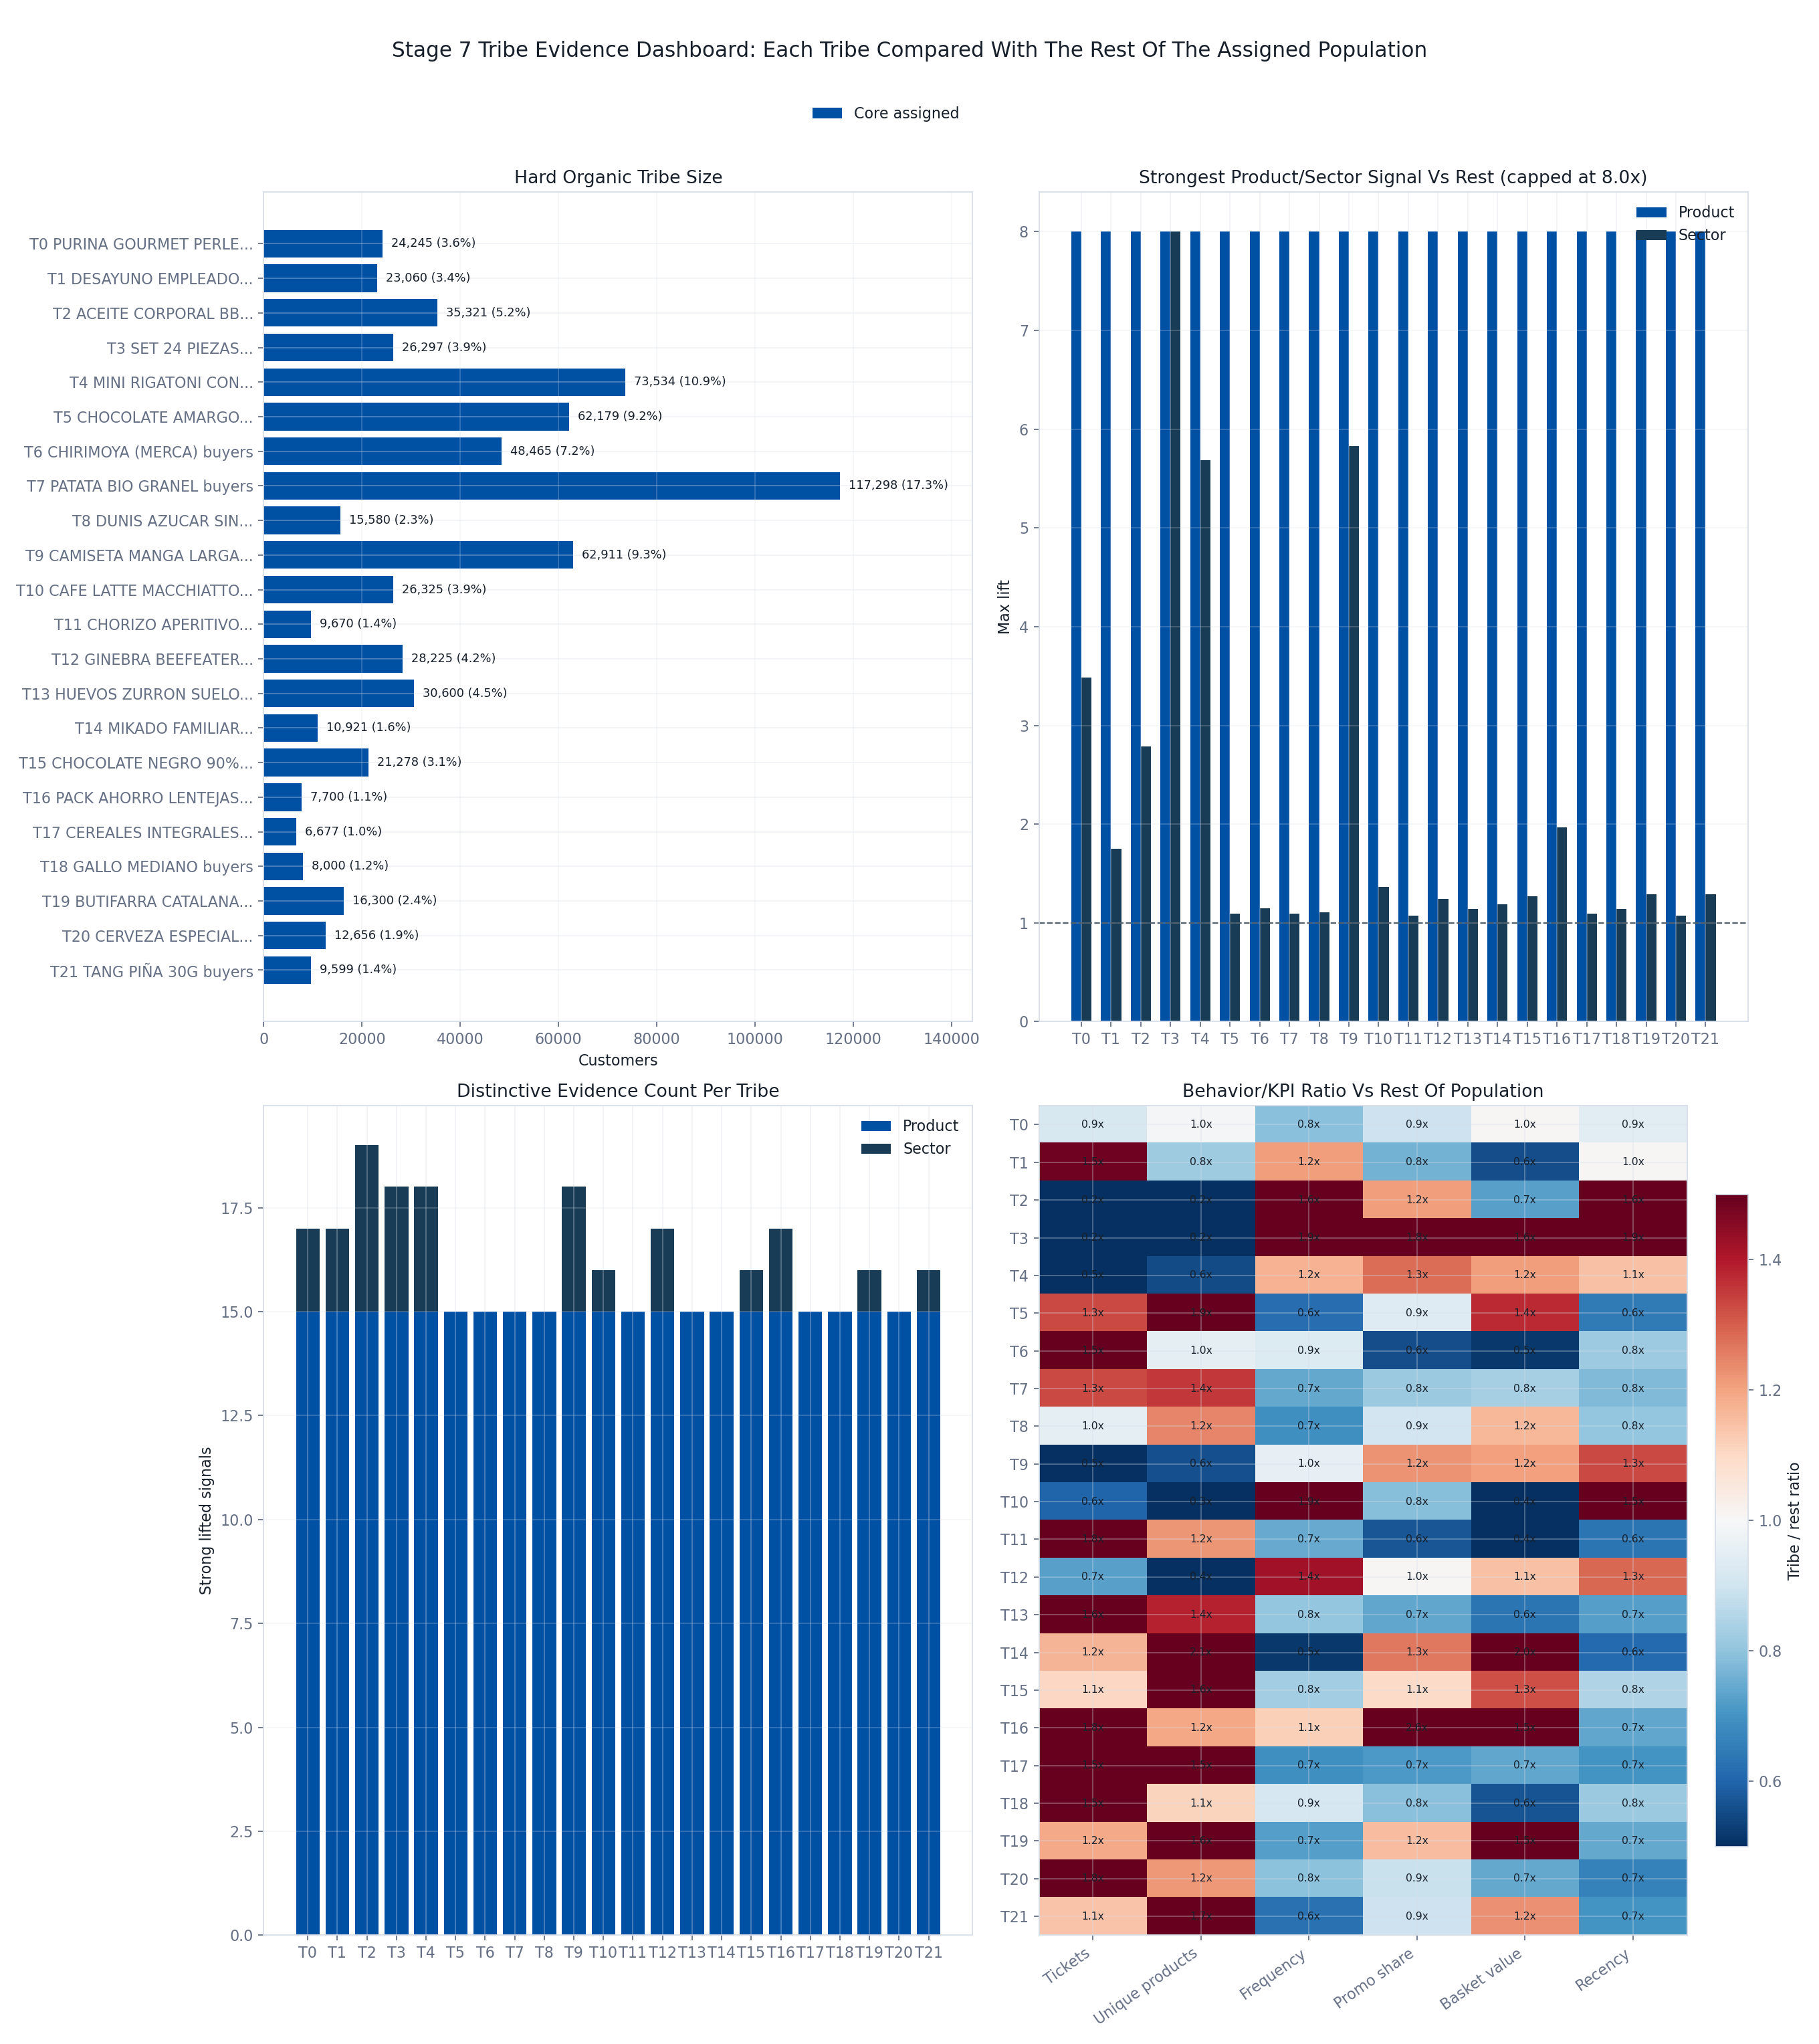

In [21]:
display(stage7_promoted_tribe_validation)
display(Image(filename=str(tribe_vs_population_dashboard)))


### Stage 7.2B: Review Tribe Audit

The 7 review tribes failed at least one quality gate — typically too few core customers, low jitter recovery, or low assignment confidence. They are **not final tribes**.

**Why they are still shown:** several have strong product-lift evidence and real purchasing signal. They are included as hypotheses that a future run (more data, relaxed size threshold) could validate.

The **blockers chart** shows which specific quality gate each review tribe failed.

In [ ]:
display(stage7_review_tribe_validation)
stage7_review_blocker_figure = plot_stage7_review_blockers(
    stage7_review_tribe_validation,
    output_path=stage7_figures_dir / f"stage7_review_tribe_blockers_{CONFIG.mode}.png",
    cfg=CONFIG,
)
display(Image(filename=str(stage7_review_blocker_figure)))
if not stage7_review_candidates.is_empty():
    display(stage7_review_candidates)


### Stage 7.3: What Each Tribe Buys

The table shows each tribe's top products and sectors. The **heatmap** below maps every tribe against the top product themes, ranked by strongest over-index.

> **How to read the heatmap:** Each cell value is the lift — `2.5x` means this tribe buys that product theme 2.5x more than the average customer. Darker blue = stronger over-index. Blank cells = near average or below the significance threshold.

tribe_id,tribe_name,promotion_decision,validation_tier,technical_name,business_name,legacy_tribe_name,business_confidence,validation_blockers,coverage_group,membership_policy,tribe_status,tribe_status_label,customers,population_share_pct,distinctive_products,broad_reach_products,sector_theme_evidence,shopping_mission,readiness_caveat,recommended_use
i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,f64,str,str,str,str,str,str
0,"""Purina Gourmet Perle Buyers""","""promoted""","""promoted_usable""","""Purina Gourmet Perle Buyers""","""Purina Gourmet Perle Buyers""","""Purina Gourmet Perle Buyers""","""medium""","""pass""","""core_promoted_tribe""","""official hard-assigned promote…","""final_usable""","""Final - usable""",24245,3.582,"""PURINA GOURMET PERLE FINAS LÁM…","""GOURMET GOLD FONDANT POLLO 85G…","""No curated product theme passe…","""GOURMET NATURE'S CREATIONS POL…","""Promoted for final profiling, …","""Usable for stakeholder segment…"
1,"""Desayuno Empleado Especial Buy…","""promoted""","""promoted_usable""","""Desayuno Empleado Especial Buy…","""Desayuno Empleado Especial Buy…","""Desayuno Empleado Especial Buy…","""medium""","""pass""","""core_promoted_tribe""","""official hard-assigned promote…","""final_usable""","""Final - usable""",23060,3.407,"""DESAYUNO EMPLEADO ESPECIAL (PR…","""PORCION PIZZA+BEBIDA (5.0% rea…","""No curated product theme passe…","""DESAYUNO EMPLEADO BASICO + FLA…","""Promoted for final profiling, …","""Usable for stakeholder segment…"
2,"""Aceite Corporal Natural Buyers""","""promoted""","""promoted_usable""","""Aceite Corporal Natural Buyers""","""Aceite Corporal Natural Buyers""","""Aceite Corporal Natural Buyers""","""medium""","""pass""","""core_promoted_tribe""","""official hard-assigned promote…","""final_usable""","""Final - usable""",35321,5.219,"""ACEITE CORPORAL BB NATURAL HON…","""ENJUAGUE BUCAL LISTERINE MENTO…","""No curated product theme passe…","""DENTIFRICO VIAJE COLGATE TOTAL…","""Promoted for final profiling, …","""Usable for stakeholder segment…"
3,"""Set Piezas Cuberteria Buyers""","""promoted""","""promoted_strong""","""Set Piezas Cuberteria Buyers""","""Set Piezas Cuberteria Buyers""","""Set Piezas Cuberteria Buyers""","""high""","""pass""","""core_promoted_tribe""","""official hard-assigned promote…","""final_strong""","""Final - strong""",26297,3.885,"""SET 24 PIEZAS CUBERTERIA ACERO…","""ESCURRIDOR GRAND CHEF INOX 24C…","""No curated product theme passe…","""ENCIMERA POLY 150CM NAVY + PAC…","""Passed final readiness with st…","""Ready for stakeholder segmenta…"
4,"""Mini Rigatoni Con Buyers""","""review""","""review""","""Mini Rigatoni Con Buyers""","""Mini Rigatoni Con Buyers""","""Mini Rigatoni Con Buyers""","""review_only""","""statistical_validity=review""","""review_tribe""","""hard-assigned tribe held outsi…","""potential_review""","""Potential / Review""",73534,10.864,"""MINI RIGATONI CON SALSA CREMOS…","""CREMA SUAVE CALABAZA JAMON Y Q…","""No curated product theme passe…","""CREMA SUAVE CALABAZA JAMON Y Q…","""Potential tribe only; held for…","""Promising behavioral pocket; u…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
17,"""Cereales Integrales Nesquik Bu…","""promoted""","""promoted_usable""","""Cereales Integrales Nesquik Bu…","""Cereales Integrales Nesquik Bu…","""Cereales Integrales Nesquik Bu…","""medium""","""pass""","""core_promoted_tribe""","""official hard-assigned promote…","""final_usable""","""Final - usable""",6677,0.986,"""CEREALES INTEGRALES NESQUIK NE…","""CROISSANT CARREFOUR X 6 (5.9% …","""No curated product theme passe…","""SUAVIZANTE CONCENTRADO VERNEL …","""Promoted for final profiling, …","""Usable for stakeholder segment…"
18,"""Gallo Mediano Buyers""","""review""","""review""","""Gallo Mediano Buyers""","""Gallo Mediano Buyers""","""Gallo Mediano Buyers""","""review_only""","""statistical_validity=review""","""review_tribe""","""hard-assigned tribe held outsi…","""potential_review""","""Potential / Review""",8000,1.182,"""GALLO

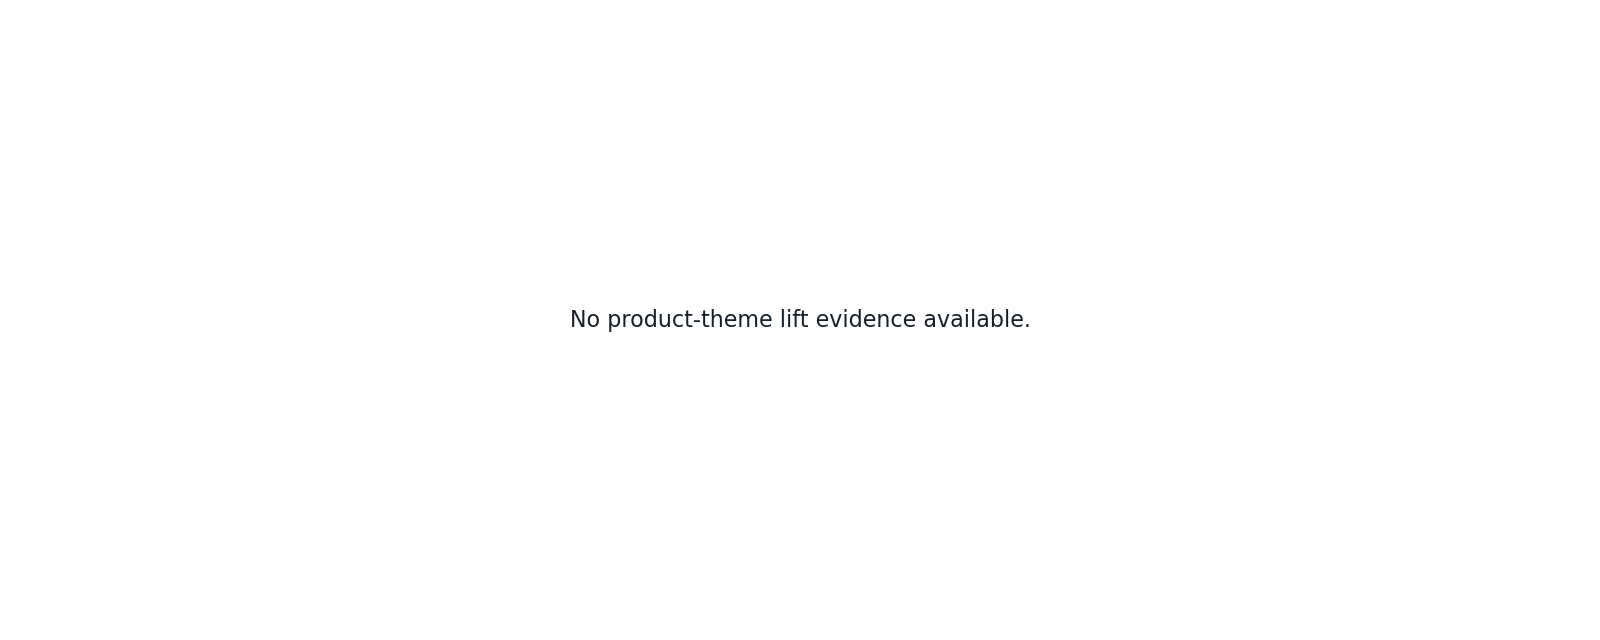

In [23]:
display(stage7_all_tribe_product_identity)
display(Image(filename=str(stage7_product_theme_heatmap)))


### Stage 7.4: How Each Tribe Shops

The table compares spending, visit frequency, basket size, and promotion use across tribes. The **heatmap** below shows the same data visually.

> **How to read the heatmap:** Each cell = tribe rate divided by all other shoppers' rate. `2.0x` = tribe does this twice as much as others. `0.5x` = half the average. `--` = near average. Warm green = tribe over-indexes here. Blue/purple = under-indexes.

tribe_id,tribe_name,tribe_status,tribe_status_label,customers,population_share_pct,total_spend_ratio_vs_rest,visit_frequency_ratio_vs_rest,basket_value_ratio_vs_rest,promo_sensitivity_ratio_vs_rest,behavioral_signature,promo_loyalty_recency,readiness_caveat,recommended_use
i64,str,str,str,i64,f64,f64,f64,f64,f64,str,str,str,str
0,"""Purina Gourmet Perle Buyers""","""final_usable""","""Final - usable""",24245,3.582,0.9404,0.7893,1.0054,0.8971,"""total spend: 0.94x vs rest, €4…","""promo share 20.5%; Tenure 144 …","""Promoted for final profiling, …","""Usable for stakeholder segment…"
1,"""Desayuno Empleado Especial Buy…","""final_usable""","""Final - usable""",23060,3.407,0.744,1.2073,0.5565,0.7618,"""total spend: 0.74x vs rest, €3…","""promo share 17.5%; Tenure 137 …","""Promoted for final profiling, …","""Usable for stakeholder segment…"
2,"""Aceite Corporal Natural Buyers""","""final_usable""","""Final - usable""",35321,5.219,0.2106,1.6469,0.7298,1.2101,"""total spend: 0.21x vs rest, €1…","""promo share 27.3%; Tenure 114 …","""Promoted for final profiling, …","""Usable for stakeholder segment…"
3,"""Set Piezas Cuberteria Buyers""","""final_strong""","""Final - strong""",26297,3.885,0.3283,1.9277,1.65,1.7796,"""total spend: 0.33x vs rest, €1…","""promo share 39.4%; Tenure 113 …","""Passed final readiness with st…","""Ready for stakeholder segmenta…"
4,"""Mini Rigatoni Con Buyers""","""potential_review""","""Potential / Review""",73534,10.864,0.575,1.1739,1.2092,1.2776,"""total spend: 0.57x vs rest, €2…","""promo share 28.3%; Tenure 123 …","""Potential tribe only; held for…","""Promising behavioral pocket; u…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
17,"""Cereales Integrales Nesquik Bu…","""final_usable""","""Final - usable""",6677,0.986,1.0581,0.6937,0.741,0.7123,"""total spend: 1.06x vs rest, €4…","""promo share 16.3%; Tenure 149 …","""Promoted for final profiling, …","""Usable for stakeholder segment…"
18,"""Gallo Mediano Buyers""","""potential_review""","""Potential / Review""",8000,1.182,0.8623,0.9157,0.5682,0.7899,"""total spend: 0.86x vs rest, €3…","""promo share 18.1%; Tenure 145 …","""Potential tribe only; held for…","""Promising behavioral pocket; u…"
19,"""Butifarra Catalana Exentis Buy…","""final_usable""","""Final - usable""",16300,2.408,1.7354,0.7243,1.5124,1.1544,"""total spend: 1.74x vs rest, €7…","""promo share 26.2%; Tenure 149 …","""Promoted for final profiling, …","""Usable for stakeholder segment…"


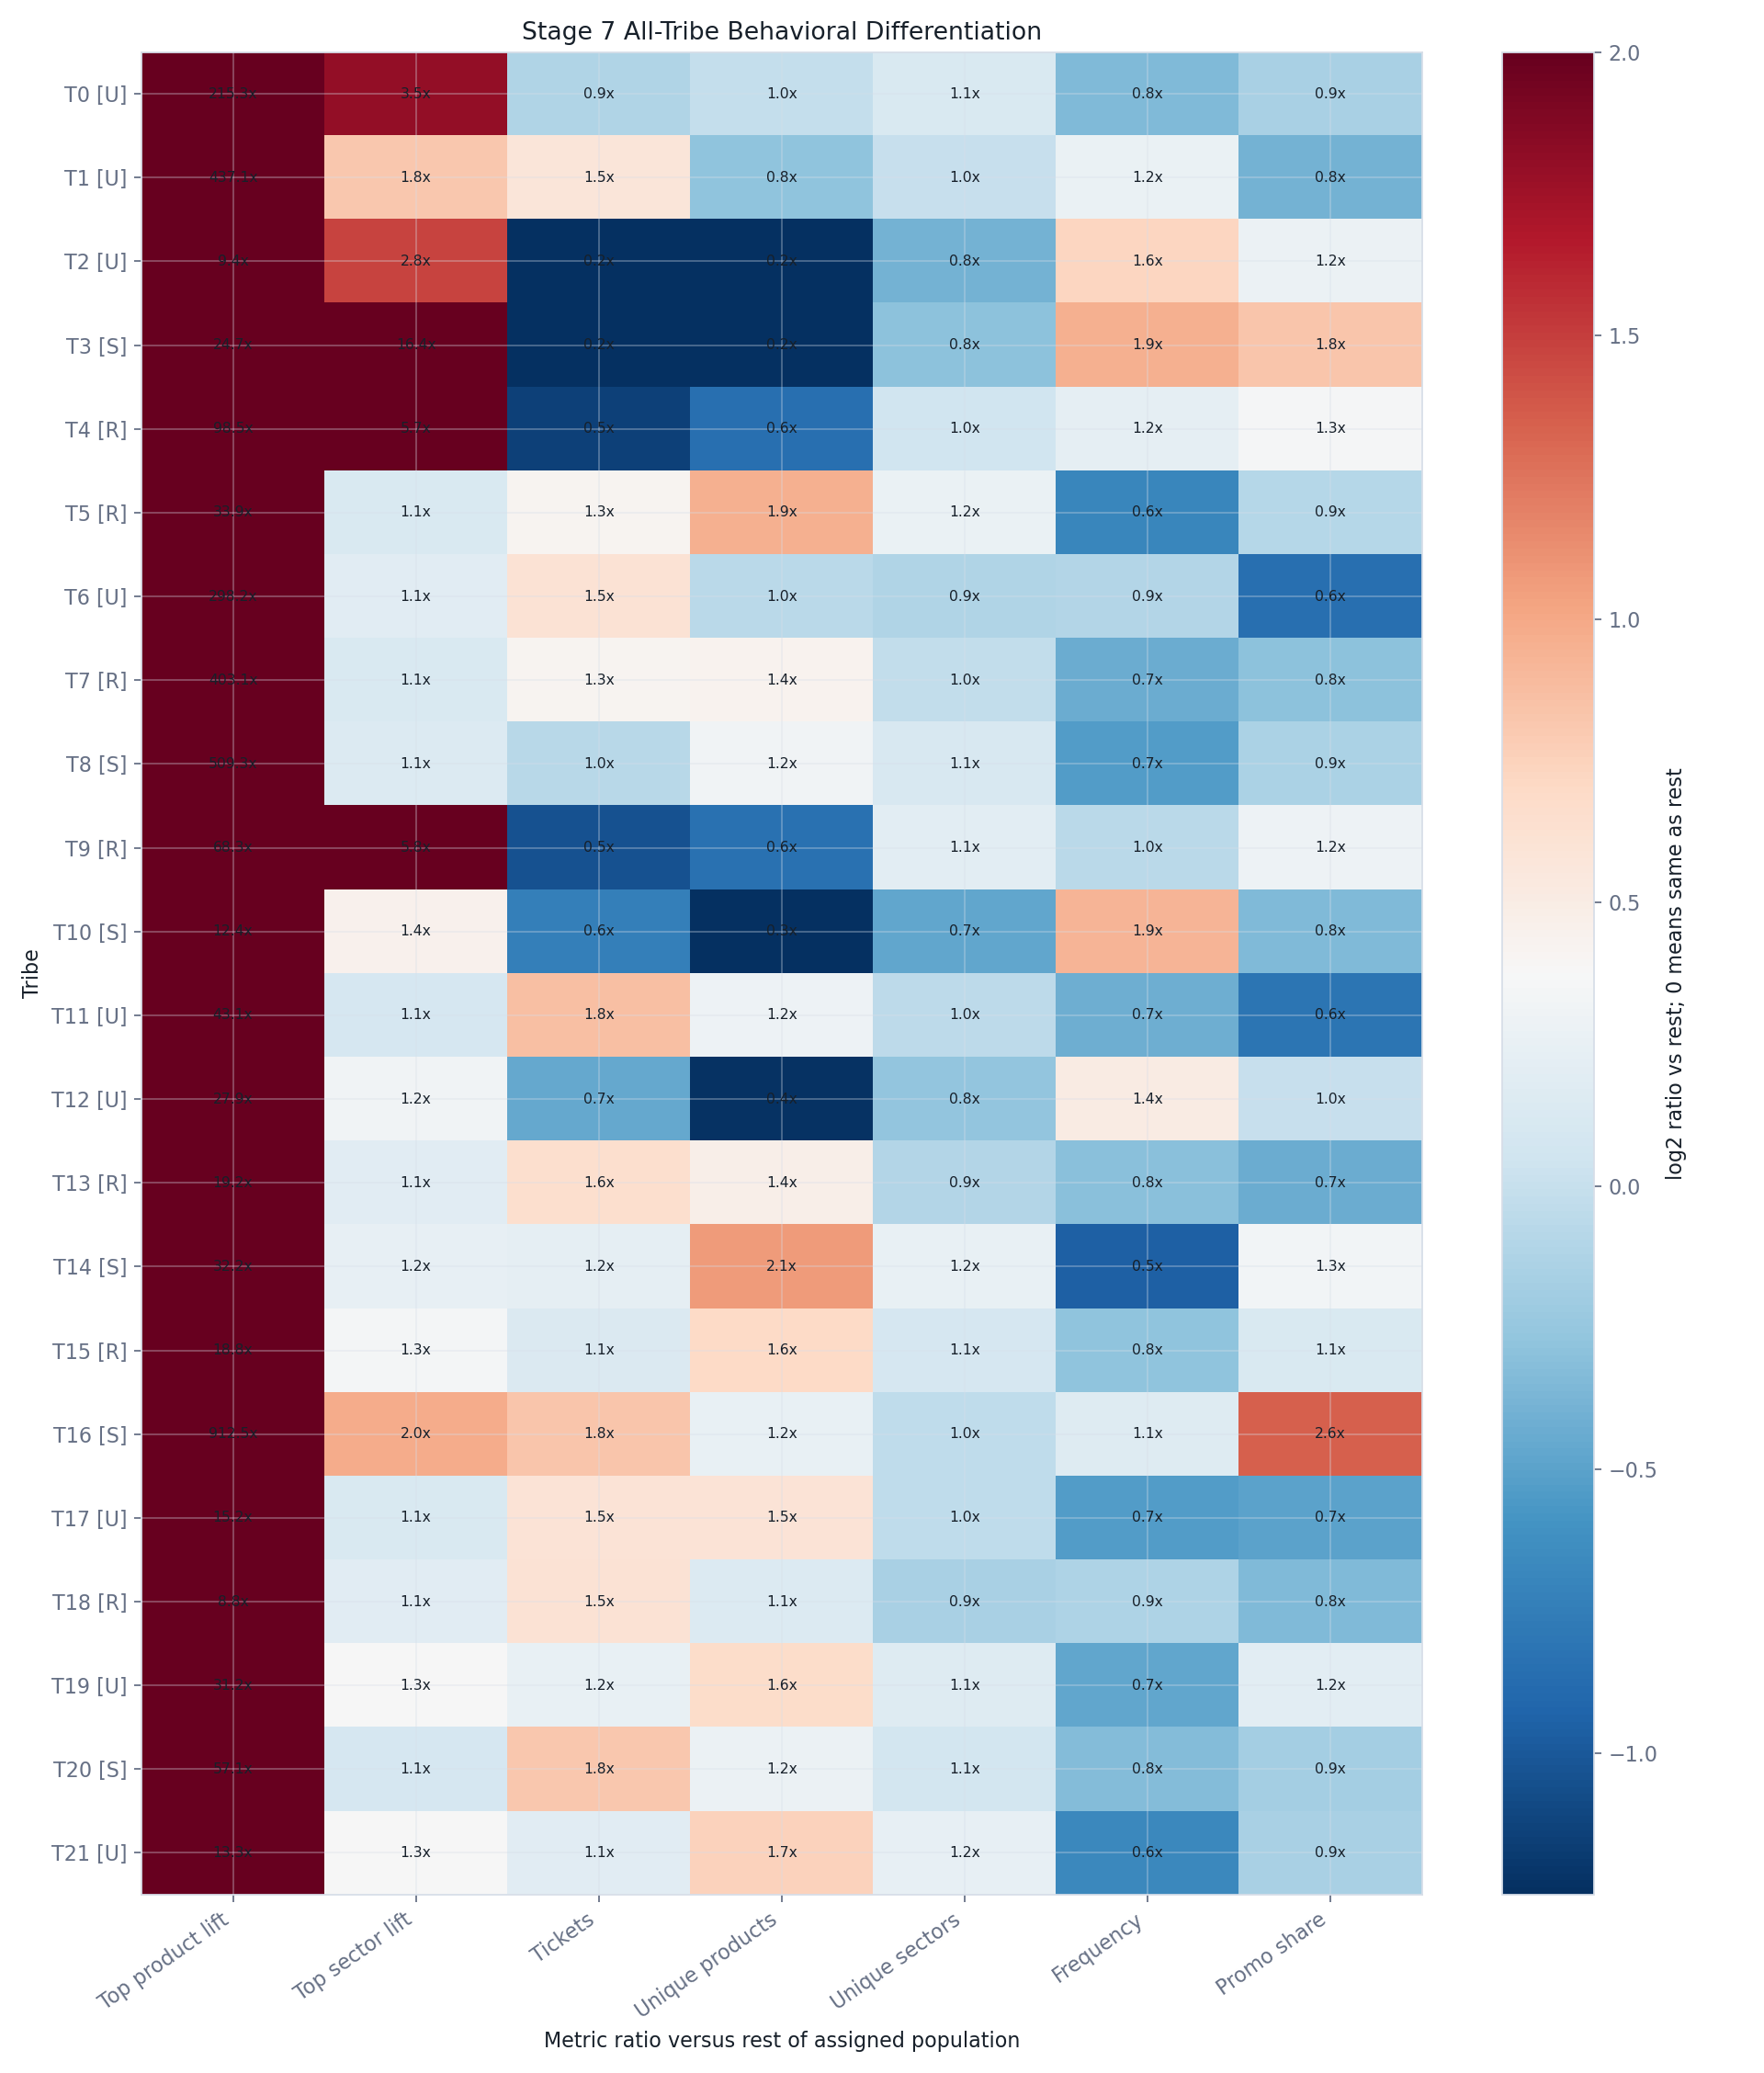

In [24]:
display(stage7_all_tribe_behavior_differentiation)
display(Image(filename=str(stage7_behavior_heatmap)))


### Stage 7.5: All-Tribe Dossiers

One concise dossier per retained tribe: top products, behavioral summary, a plain-language description, and a caveat where applicable.

Final promoted tribes are ready for stakeholder use. Review tribes are labelled **Potential / Review** and should be treated as hypotheses only.

# Stage 7.5 All-Tribe Dossiers

## T0: Purina Gourmet Perle Buyers [Final - usable]

**Recommended use:** Usable for stakeholder segmentation with the stability caveat stated.

**Who they are:** Purina Gourmet Perle Buyers are defined by repeat over-indexing in PURINA GOURMET PERLE FINAS LÁMINAS CARNES DELIC. 4X85GR (BAZAR, 123.27x vs rest, 1.7% reach); FELIX FANTASTIC DUO FESTIN DEL MAR 340G (BAZAR, 120.58x vs rest, 1.8% reach); PURINA GOURMET GOLD TERRINE CONEJO 85G (BAZAR, 112.64x vs rest, 2.5% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.94x vs rest, €435.10 avg; visit frequency: 0.79x vs rest, 7.8/30d; basket value: 1.01x vs rest, €39.08 avg; promo sensitivity: 0.90x vs rest, 20.5% promo share

**Evidence:** PURINA GOURMET PERLE FINAS LÁMINAS CARNES DELIC. 4X85GR (BAZAR, 123.27x vs rest, 1.7% reach); FELIX FANTASTIC DUO FESTIN DEL MAR 340G (BAZAR, 120.58x vs rest, 1.8% reach); PURINA GOURMET GOLD TERRINE CONEJO 85G (BAZAR, 112.64x vs rest, 2.5% reach); GOURMET PERLE GRAVY DELIGHT DELICIAS EN SALSA POLLO Y BUEY P (BAZAR, 112.58x vs rest, 2.0% reach); CATISFACTION SNACKS QUESO 180GRS (BAZAR, 152.00x vs rest, 0.4% reach)

**Broad-reach products:** GOURMET GOLD FONDANT POLLO 85GR (3.1% reach, n=763); GOURMET GOLD TARTELETTE BUEY /TOMATE 85G (2.9% reach, n=707); PURINA GOURMET GOLD TERRINE CONEJO 85G (2.5% reach, n=611); GOURMET PERLE GRAVY DELICHT DELICIAS EN SALSA SALMON Y ATUN (2.1% reach, n=519); SHEBA CARNE EN SALSA  4X85G (2.0% reach, n=493)

**Mission:** GOURMET NATURE'S CREATIONS POLLO 85GR. + GOURMET GOLD TARTELETTE POLLO Y ZANAHORIA 85GR (20.88x vs rest); GOURMET SOUP PACK POLLO 4X40G + GOURMET MOM PETIT SELECCION DE PESCADOS PACK 6X50GR GATO (17.02x vs rest); GOURMET SOUP PACK POLLO 4X40G + GOURMET MON PETIT SELECCION POLLO 6X50G GATO (17.02x vs rest)

**Commercial meaning:** Increase frequency and basket breadth with mission-led product recommendations.

**Nearest related tribe:** T8: Dunis Azucar Sin Buyers (similar_product_mission, score=0.4851)

**Clearest differentiator:** Top lifted products differ: T0 PURINA GOURMET PERLE FINAS LÁMINAS CARNES DELIC. 4X85GR; T8 DUNIS AZUCAR SIN GLUTEN 2 UDS 100 G.

**Targeting idea:** Build a test audience around CATISFACTION SNACKS QUESO 180GRS and adjacent basket missions.

**Confidence:** medium

**Caveat:** Promoted for final profiling, but below the strong stability tier.; pass; Purchase behavior only; not a demographic claim.

## T1: Desayuno Empleado Especial Buyers [Final - usable]

**Recommended use:** Usable for stakeholder segmentation with the stability caveat stated.

**Who they are:** Desayuno Empleado Especial Buyers are defined by repeat over-indexing in DESAYUNO EMPLEADO ESPECIAL (PROD. FRESCOS TRADIC, 437.08x vs rest, 0.8% reach); PINCHO TORTILLA RELLENA DE ATUN Y PIMIENTO (PROD. FRESCOS TRADIC, 396.92x vs rest, 0.1% reach); MEDIA TOSTADA (PROD. FRESCOS TRADIC, 200.35x vs rest, 0.5% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.74x vs rest, €346.53 avg; visit frequency: 1.21x vs rest, 11.8/30d; basket value: 0.56x vs rest, €21.97 avg; promo sensitivity: 0.76x vs rest, 17.5% promo share

**Evidence:** DESAYUNO EMPLEADO ESPECIAL (PROD. FRESCOS TRADIC, 437.08x vs rest, 0.8% reach); PINCHO TORTILLA RELLENA DE ATUN Y PIMIENTO (PROD. FRESCOS TRADIC, 396.92x vs rest, 0.1% reach); MEDIA TOSTADA (PROD. FRESCOS TRADIC, 200.35x vs rest, 0.5% reach); PORCIÓN DE TARTA COMBO SNACK (PROD. FRESCOS TRADIC, 174.28x vs rest, 0.9% reach); TOSTADA DE TOMATE (PROD. FRESCOS TRADIC, 223.27x vs rest, 0.3% reach)

**Broad-reach products:** PORCION PIZZA+BEBIDA (5.0% reach, n=1160); DESAYUNO EMPLEADO BASICO (2.4% reach, n=546); INFUSION CARREFOUR (1.6% reach, n=363); CAFE CORTADO (1.5% reach, n=347); PERRITOS CALIENTES (1.4% reach, n=312)

**Mission:** DESAYUNO EMPLEADO BASICO + FLAUTIN PALETA IBERICA CARREFOUR (10.68x vs rest); CAFE CON LECHE + MEDIA TOSTADA (10.60x vs rest); COMBO MENÚ BÁSICO CARREFOUR + DESAYUNO EMPLEADO BASICO (9.91x vs rest)

**Commercial meaning:** Increase frequency and basket breadth with mission-led product recommendations.

**Nearest related tribe:** T18: Gallo Mediano Buyers (similar_product_mission, score=0.4736)

**Clearest differentiator:** Top lifted products differ: T1 DESAYUNO EMPLEADO ESPECIAL; T18 GALLO MEDIANO.

**Targeting idea:** Build a test audience around DESAYUNO EMPLEADO ESPECIAL and adjacent basket missions.

**Confidence:** medium

**Caveat:** Promoted for final profiling, but below the strong stability tier.; pass; Purchase behavior only; not a demographic claim.

## T2: Aceite Corporal Natural Buyers [Final - usable]

**Recommended use:** Usable for stakeholder segmentation with the stability caveat stated.

**Who they are:** Aceite Corporal Natural Buyers are defined by repeat over-indexing in ACEITE CORPORAL BB NATURAL HONEY 100ML (P.G.C., 9.45x vs rest, 0.0% reach); GEL INTIMO CHILLY VERDE FORMATO VIAJE 50 ML (P.G.C., 4.52x vs rest, 0.5% reach); MAYBELLINE BASE DE MAQUILLAJE ANTIEDAD EL BORRADOR 030 SAND (P.G.C., 6.22x vs rest, 0.1% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.21x vs rest, €101.39 avg; visit frequency: 1.65x vs rest, 15.7/30d; basket value: 0.73x vs rest, €28.78 avg; promo sensitivity: 1.21x vs rest, 27.3% promo share

**Evidence:** ACEITE CORPORAL BB NATURAL HONEY 100ML (P.G.C., 9.45x vs rest, 0.0% reach); GEL INTIMO CHILLY VERDE FORMATO VIAJE 50 ML (P.G.C., 4.52x vs rest, 0.5% reach); MAYBELLINE BASE DE MAQUILLAJE ANTIEDAD EL BORRADOR 030 SAND (P.G.C., 6.22x vs rest, 0.1% reach); TOALLITAS INTIMAS ROSA MOSQUETA BABARIA 12UDS (P.G.C., 7.48x vs rest, 0.0% reach); MINI BODY MILK NUTRITIVO 75 ML (P.G.C., 3.93x vs rest, 0.4% reach)

**Broad-reach products:** ENJUAGUE BUCAL LISTERINE MENTOL 95 ML (1.0% reach, n=338); GEL LIQUIDO MINI CLASSIC MOUSSEL 60ML (0.5% reach, n=182); GEL INTIMO CHILLY VERDE FORMATO VIAJE 50 ML (0.5% reach, n=177); MINI BODY MILK NUTRITIVO 75 ML (0.4% reach, n=157); CHAMPÚ RIZOS PANTENE NUTRI PRO-V 640ML (0.4% reach, n=157)

**Mission:** DENTIFRICO VIAJE COLGATE TOTAL PACK 3 X 20 ML + GEL INTIMO CHILLY VERDE FORMATO VIAJE 50 ML (6.75x vs rest); TOALLITAS DESODORANTES CRF X12 + GEL DUCHA ORQUÍDEA CARREFOUR SOFT MINI'S 100ML (6.25x vs rest); GEL INTIMO VIAJE CARREFOUR 75ML + GEL LIQUIDO MINI CLASSIC MOUSSEL 60ML (4.60x vs rest)

**Commercial meaning:** Use margin-aware promotions and personalized offers rather than blanket discounts.

**Nearest related tribe:** T10: Cafe Latte Macchiatto Buyers (similar_product_mission, score=0.4193)

**Clearest differentiator:** Top lifted products differ: T2 ACEITE CORPORAL BB NATURAL HONEY 100ML; T10 CAFE LATTE MACCHIATTO LIGHT CARREFOUR  250ML.

**Targeting idea:** Build a test audience around MAYBELLINE BASE DE MAQUILLAJE ANTIEDAD EL BORRADOR 030 SAND and adjacent basket missions.

**Confidence:** medium

**Caveat:** Promoted for final profiling, but below the strong stability tier.; pass; Purchase behavior only; not a demographic claim.

## T3: Set Piezas Cuberteria Buyers [Final - strong]

**Recommended use:** Ready for stakeholder segmentation and campaign planning.

**Who they are:** Set Piezas Cuberteria Buyers are defined by repeat over-indexing in SET 24 PIEZAS CUBERTERIA ACERO INOX RECICLADO BRILLO NATUR S (BAZAR, 19.79x vs rest, 0.2% reach); PLATO LLANO MELAMINA GREEN ALFARES 25.5CM (BAZAR, 19.79x vs rest, 0.2% reach); SET 24 PIEZAS CUBERTERIA ACERO INOX RECICLADO MATE ROOT SG (BAZAR, 19.79x vs rest, 0.2% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.33x vs rest, €155.66 avg; visit frequency: 1.93x vs rest, 18.3/30d; basket value: 1.65x vs rest, €62.57 avg; promo sensitivity: 1.78x vs rest, 39.4% promo share

**Evidence:** SET 24 PIEZAS CUBERTERIA ACERO INOX RECICLADO BRILLO NATUR S (BAZAR, 19.79x vs rest, 0.2% reach); PLATO LLANO MELAMINA GREEN ALFARES 25.5CM (BAZAR, 19.79x vs rest, 0.2% reach); SET 24 PIEZAS CUBERTERIA ACERO INOX RECICLADO MATE ROOT SG (BAZAR, 19.79x vs rest, 0.2% reach); BATERIA ROYAL 6 PIEZAS (BAZAR, 18.23x vs rest, 0.2% reach); TACOMA 15PC TENESSE MADERA RENBERG (BAZAR, 19.44x vs rest, 0.1% reach)

**Broad-reach products:** ESCURRIDOR GRAND CHEF INOX 24CM (0.3% reach, n=68); VAJILLA 18 P PORCELANA BLANCA CARREFOUR (0.2% reach, n=64); ENCIMERA POLY 135CM KHAKI (0.2% reach, n=54); SET 24 PIEZAS CUBERTERIA ACERO INOX RECICLADO BRILLO NATUR S (0.2% reach, n=48); SET 24PCS CUBERTERIA  ACERO INOXIDABLE MUNICH PLATA BRILLANT (0.2% reach, n=48)

**Mission:** ENCIMERA POLY 150CM NAVY + PACK 2 FUNDAS DE ALMOHADA  POLY KAKI 150CM TEX HOME (15.45x vs rest); BATERIA DE COCINA 9 PIEZAS KOLN 2019 + CAZO NYLON CARREFOUR HOME (11.03x vs rest); CACEROLA 24X10.5CM CON TAPA COBRE SG ACERO INOXIDABLE INDUCC + CACEROLA 20X8.0CM CON TAPA COBRE SG ACERO INOXIDABLE INDUCCI (7.17x vs rest)

**Commercial meaning:** Use margin-aware promotions and personalized offers rather than blanket discounts.

**Nearest related tribe:** T2: Aceite Corporal Natural Buyers (similar_product_mission, score=0.4017)

**Clearest differentiator:** Top lifted products differ: T2 ACEITE CORPORAL BB NATURAL HONEY 100ML; T3 SET 24 PIEZAS CUBERTERIA ACERO INOX RECICLADO BRILLO NATUR S.

**Targeting idea:** Build a test audience around SET 24 PIEZAS CUBERTERIA ACERO INOX RECICLADO BRILLO NATUR S and adjacent basket missions.

**Confidence:** high

**Caveat:** Passed final readiness with strong stability evidence.; pass; Purchase behavior only; not a demographic claim.

## T4: Mini Rigatoni Con Buyers [Potential / Review]

**Recommended use:** Promising behavioral pocket; use for exploration, hypothesis testing, or cautious campaign tests only.

**Who they are:** Mini Rigatoni Con Buyers are defined by repeat over-indexing in MINI RIGATONI CON SALSA CREMOSA DE VERDURAS HIPP 250 G (P.G.C., 58.80x vs rest, 0.3% reach); TARRITO VERDURAS CON QUINOA SMILEAT 230G (P.G.C., 47.25x vs rest, 0.7% reach); TARRITO CON CACHITOS DE ARROZ Y PAVO CON VERDURAS ECO SMILEA (P.G.C., 43.73x vs rest, 0.9% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.57x vs rest, €278.31 avg; visit frequency: 1.17x vs rest, 11.3/30d; basket value: 1.21x vs rest, €45.97 avg; promo sensitivity: 1.28x vs rest, 28.3% promo share

**Evidence:** MINI RIGATONI CON SALSA CREMOSA DE VERDURAS HIPP 250 G (P.G.C., 58.80x vs rest, 0.3% reach); TARRITO VERDURAS CON QUINOA SMILEAT 230G (P.G.C., 47.25x vs rest, 0.7% reach); TARRITO CON CACHITOS DE ARROZ Y PAVO CON VERDURAS ECO SMILEA (P.G.C., 43.73x vs rest, 0.9% reach); TARRITO MELOCOTÓN Y FRAMBUESA SMILEAT 130G (P.G.C., 46.82x vs rest, 0.6% reach); TARRITO TROCITOS LENTEJA VERDURAS JAMON HERO BABY 2 X 235G (P.G.C., 50.63x vs rest, 0.3% reach)

**Broad-reach products:** CREMA SUAVE CALABAZA JAMON Y QUESO HERO BABY 2X190 GRAMOS (1.9% reach, n=1365); TARRITO DE GUISITO DE ALUBIAS ECOLÓGICO SMILEAT 230G (1.1% reach, n=836); TARRITO CON CACHITOS DE ARROZ Y PAVO CON VERDURAS ECO SMILEA (0.9% reach, n=661); TARRITO BROCOLI, CORDERO Y CHIRIVIA SMILEAT 230G (0.9% reach, n=641); TARRITO VERDURAS CON QUINOA SMILEAT 230G (0.7% reach, n=478)

**Mission:** CREMA SUAVE CALABAZA JAMON Y QUESO HERO BABY 2X190 GRAMOS + TARRITO DE VERDURAS CON LUBINA Y MERLUZA ECOLÓGICO SMILEAT 2 (10.79x vs rest); PACK TARRITO VERDURAS DORADA CARREFOUR BIO 2X200G + YOGOLINO PERA NESTLÉ 4X100 GRS. (10.26x vs rest); YOGOLINO CEREALES 4X100 G + POSTRE LACTEO FRESA FRAMBUESA NESTLE YUMMYOGS 6X60G (10.00x vs rest)

**Commercial meaning:** Use margin-aware promotions and personalized offers rather than blanket discounts.

**Nearest related tribe:** T9: Camiseta Manga Larga Buyers (similar_product_mission, score=0.5093)

**Clearest differentiator:** Top lifted products differ: T4 MINI RIGATONI CON SALSA CREMOSA DE VERDURAS HIPP 250 G; T9 CAMISETA MANGA LARGA NAVIDAD NINA TEX.

**Targeting idea:** Build a test audience around MINI RIGATONI CON SALSA CREMOSA DE VERDURAS HIPP 250 G and adjacent basket missions.

**Confidence:** review_only

**Caveat:** Potential tribe only; held for review because stage6_profile_readiness=review.; stage6_profile_readiness=review; Purchase behavior only; not a demographic claim.

## T5: Chocolate Amargo Luker Buyers [Potential / Review]

**Recommended use:** Promising behavioral pocket; use for exploration, hypothesis testing, or cautious campaign tests only.

**Who they are:** Chocolate Amargo Luker Buyers are defined by repeat over-indexing in CHOCOLATE AMARGO LUKER  PACK 6 UD 250 G (P.G.C., 32.62x vs rest, 0.8% reach); PANELA ENTERA DOÑA PANELA 454 G (P.G.C., 28.27x vs rest, 1.4% reach); CHONTADURO GOURMET LATINO PESO ESCURRIDO 520G PESO NETO 790G (P.G.C., 33.89x vs rest, 0.3% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 1.70x vs rest, €737.78 avg; visit frequency: 0.62x vs rest, 6.3/30d; basket value: 1.37x vs rest, €51.62 avg; promo sensitivity: 0.94x vs rest, 21.5% promo share

**Evidence:** CHOCOLATE AMARGO LUKER  PACK 6 UD 250 G (P.G.C., 32.62x vs rest, 0.8% reach); PANELA ENTERA DOÑA PANELA 454 G (P.G.C., 28.27x vs rest, 1.4% reach); CHONTADURO GOURMET LATINO PESO ESCURRIDO 520G PESO NETO 790G (P.G.C., 33.89x vs rest, 0.3% reach); CHOCOLATE EN POLVO A LA TAZA CORONA 250 GR (P.G.C., 24.95x vs rest, 1.3% reach); MASAREPA BLANCA GOYA 1 KG (P.G.C., 21.33x vs rest, 2.3% reach)

**Broad-reach products:** KETCHUP NATURE CARREFOUR 1 KG (6.3% reach, n=3899); MASAREPA BLANCA GOYA 1 KG (2.3% reach, n=1448); GALLETA QUESO Y MANTEQUILLA SALTIN 385 GRAMOS (1.7% reach, n=1067); HARINA DE MAIZ AMARILLA PRECOCIDA MASAREPA GOYA 1KG (1.5% reach, n=941); PANELA ENTERA DOÑA PANELA 454 G (1.4% reach, n=858)

**Mission:** GASEOSA POSTOBON MANZANA 2L + CHOCOLATE AMARGO LUKER  PACK 6 UD 250 G (33.12x vs rest); GASEOSA POSTOBON LA COLOMBIANA 2L + KETCHUP NATURE CARREFOUR 1 KG (28.74x vs rest); CHOCOLATE EN POLVO A LA TAZA CORONA 250 GR + TRIGUISAR EL REY 70 GRS (26.87x vs rest)

**Commercial meaning:** Protect and grow high-value baskets through premium bundles, replenishment, and cross-sell.

**Nearest related tribe:** T21: Tang 30G Buyers (similar_product_mission, score=0.523)

**Clearest differentiator:** Top lifted products differ: T5 CHOCOLATE AMARGO LUKER  PACK 6 UD 250 G; T21 TANG PIÑA 30G.

**Targeting idea:** Build a test audience around CHONTADURO GOURMET LATINO PESO ESCURRIDO 520G PESO NETO 790G and adjacent basket missions.

**Confidence:** review_only

**Caveat:** Potential tribe only; held for review because stage6_profile_readiness=review.; stage6_profile_readiness=review; Purchase behavior only; not a demographic claim.

## T6: Chirimoya Merca Buyers [Final - usable]

**Recommended use:** Usable for stakeholder segmentation with the stability caveat stated.

**Who they are:** Chirimoya Merca Buyers are defined by repeat over-indexing in CHIRIMOYA (MERCA) (PROD. FRESCOS TRADIC, 298.21x vs rest, 0.0% reach); MAGDALENAS REDONDAS TOLEDANAS CAJA 750 GR FRQ (P.G.C., 158.37x vs rest, 0.4% reach); HUEVOS XL 12 UNIDADES FRQ (PROD. FRESCOS TRADIC, 117.36x vs rest, 1.8% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.76x vs rest, €355.90 avg; visit frequency: 0.93x vs rest, 9.2/30d; basket value: 0.52x vs rest, €20.89 avg; promo sensitivity: 0.55x vs rest, 13.1% promo share

**Evidence:** CHIRIMOYA (MERCA) (PROD. FRESCOS TRADIC, 298.21x vs rest, 0.0% reach); MAGDALENAS REDONDAS TOLEDANAS CAJA 750 GR FRQ (P.G.C., 158.37x vs rest, 0.4% reach); HUEVOS XL 12 UNIDADES FRQ (PROD. FRESCOS TRADIC, 117.36x vs rest, 1.8% reach); BAGUETTE CARREFOUR (PROD. FRESCOS TRADIC, 194.48x vs rest, 0.1% reach); CEREZA (MERCA) (PROD. FRESCOS TRADIC, 165.31x vs rest, 0.1% reach)

**Broad-reach products:** HUEVOS XL 12 UNIDADES FRQ (1.8% reach, n=878); HUEVOS L GRANDE 12 UNIDADES FRQ (1.8% reach, n=857); FRUTERIA FRANQUICIA FRQ (1.4% reach, n=678); VENTA CHARCUTERIA QUESOS (COSTE CENTRALIZADO) (0.5% reach, n=238); PAN ESPIGA  340 GRS FRQ (0.4% reach, n=207)

**Mission:** PAN GALA 250GR FRQ + PAN CHAPATA 250GR FRQ (19.51x vs rest); FRUTERIA FRANQUICIA FRQ + PERA CONFERENCIA CARREFOUR 2PIEZAS APROX. 300GR (18.38x vs rest); CHARCUTERIA FRQ + PERA CONFERENCIA CARREFOUR 2PIEZAS APROX. 300GR (12.52x vs rest)

**Commercial meaning:** Increase frequency and basket breadth with mission-led product recommendations.

**Nearest related tribe:** T11: Chorizo Aperitivo Skin Buyers (similar_product_mission, score=0.482)

**Clearest differentiator:** Top lifted products differ: T6 CHIRIMOYA (MERCA); T11 CHORIZO APERITIVO SKIN 270G.

**Targeting idea:** Build a test audience around BAGUETTE CARREFOUR and adjacent basket missions.

**Confidence:** medium

**Caveat:** Promoted for final profiling, but below the strong stability tier.; pass; Purchase behavior only; not a demographic claim.

## T7: Patata Bio Granel Buyers [Potential / Review]

**Recommended use:** Promising behavioral pocket; use for exploration, hypothesis testing, or cautious campaign tests only.

**Who they are:** Patata Bio Granel Buyers are defined by repeat over-indexing in PATATA BIO GRANEL (PROD. FRESCOS TRADIC, 403.09x vs rest, 0.1% reach); KAKI BIO (PROD. FRESCOS TRADIC, 205.12x vs rest, 0.0% reach); BERENJENA BIO (MERCADO) (PROD. FRESCOS TRADIC, 176.50x vs rest, 0.1% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 1.05x vs rest, €481.18 avg; visit frequency: 0.74x vs rest, 7.7/30d; basket value: 0.83x vs rest, €33.39 avg; promo sensitivity: 0.82x vs rest, 19.2% promo share

**Evidence:** PATATA BIO GRANEL (PROD. FRESCOS TRADIC, 403.09x vs rest, 0.1% reach); KAKI BIO (PROD. FRESCOS TRADIC, 205.12x vs rest, 0.0% reach); BERENJENA BIO (MERCADO) (PROD. FRESCOS TRADIC, 176.50x vs rest, 0.1% reach); JAMON BIOBARDALES LONCHAS 100G (P.G.C., 116.08x vs rest, 0.1% reach); PEPINO CARREFOUR BIO GRANEL (PROD. FRESCOS TRADIC, 98.98x vs rest, 0.1% reach)

**Broad-reach products:** FUET EXTRA BIOBARDALES 200 GRAMOS (0.2% reach, n=233); PATATA BIO GRANEL (0.1% reach, n=169); PEPINO CARREFOUR BIO GRANEL (0.1% reach, n=166); JAMON BIOBARDALES LONCHAS 100G (0.1% reach, n=146); POMELO BIO (MERCADO) (0.1% reach, n=85)

**Mission:** PIMIENTO ROJO CARREFOUR  BIO GRANEL + CALABACIN CARREFOUR BIO GRANEL (14.69x vs rest); PIMIENTO ROJO CARREFOUR  BIO GRANEL + PEPINO CARREFOUR BIO GRANEL (8.74x vs rest); PEPINO CARREFOUR BIO GRANEL + CALABACIN CARREFOUR BIO GRANEL (7.78x vs rest)

**Commercial meaning:** Increase frequency and basket breadth with mission-led product recommendations.

**Nearest related tribe:** T20: Cerveza Especial Carrefour Buyers (similar_product_mission, score=0.5018)

**Clearest differentiator:** Top lifted products differ: T7 PATATA BIO GRANEL; T20 CERVEZA ESPECIAL CARREFOUR LATA 50CL.

**Targeting idea:** Build a test audience around PATATA BIO GRANEL and adjacent basket missions.

**Confidence:** review_only

**Caveat:** Potential tribe only; held for review because stage6_profile_readiness=review.; stage6_profile_readiness=review; Purchase behavior only; not a demographic claim.

## T8: Dunis Azucar Sin Buyers [Final - strong]

**Recommended use:** Ready for stakeholder segmentation and campaign planning.

**Who they are:** Dunis Azucar Sin Buyers are defined by repeat over-indexing in DUNIS AZUCAR SIN GLUTEN 2 UDS 100 G (P.G.C., 388.52x vs rest, 2.3% reach); PALMERAS DE CHOCOLATE BLANCO SIN GLUTEN AIROS 150 G (P.G.C., 362.89x vs rest, 3.3% reach); BIZCOCHO PAUSA SI SCHAR 300G (P.G.C., 509.31x vs rest, 0.5% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 1.13x vs rest, €521.48 avg; visit frequency: 0.69x vs rest, 6.9/30d; basket value: 1.17x vs rest, €45.17 avg; promo sensitivity: 0.90x vs rest, 20.7% promo share

**Evidence:** DUNIS AZUCAR SIN GLUTEN 2 UDS 100 G (P.G.C., 388.52x vs rest, 2.3% reach); PALMERAS DE CHOCOLATE BLANCO SIN GLUTEN AIROS 150 G (P.G.C., 362.89x vs rest, 3.3% reach); BIZCOCHO PAUSA SI SCHAR 300G (P.G.C., 509.31x vs rest, 0.5% reach); LASAÑA CARNE SIN GLUTEN MAHESO 525 G (P.G.C., 321.65x vs rest, 4.0% reach); DUNIS 2 UNIDADES SIN GLUTEN (CHOCOLATE) (P.G.C., 349.19x vs rest, 2.3% reach)

**Broad-reach products:** BIZCOCHO SIN GLUTEN RECUBIERTO DE CHOCOLATE MENAL 200G (5.2% reach, n=816); CHURROS LAZO SIN GLUTEN MAHESO 200G (5.1% reach, n=794); COOKIES SIN GLUTEN BAÑO CACAO MENAL 200G (4.3% reach, n=667); LASAÑA CARNE SIN GLUTEN MAHESO 525 G (4.0% reach, n=629); SNACK MILLY GRIS&CIOCC SIN GLUTEN SCHAR 52 GRS. (3.9% reach, n=607)

**Mission:** GALLETAS MINI SORRISI SCHAR 100 GRS. + BON MATIN SIN GLUTEN SCHAR 200 GR (25.86x vs rest); PANECILLOS SIN GLUTEN  SCHAR 150 GRS. + BON MATIN SIN GLUTEN SCHAR 200 GR (18.32x vs rest); PALMERAS DE CHOCOLATE BLANCO SIN GLUTEN AIROS 150 G + BOLLOS PAUSA CLOCK SIN GLUTEN  MULTIPACK SCHAR 350 GRS. (16.60x vs rest)

**Commercial meaning:** Protect and grow high-value baskets through premium bundles, replenishment, and cross-sell.

**Nearest related tribe:** T20: Cerveza Especial Carrefour Buyers (similar_product_mission, score=0.4904)

**Clearest differentiator:** Top lifted products differ: T8 DUNIS AZUCAR SIN GLUTEN 2 UDS 100 G; T20 CERVEZA ESPECIAL CARREFOUR LATA 50CL.

**Targeting idea:** Build a test audience around BIZCOCHO PAUSA SI SCHAR 300G and adjacent basket missions.

**Confidence:** high

**Caveat:** Passed final readiness with strong stability evidence.; pass; Purchase behavior only; not a demographic claim.

## T9: Camiseta Manga Larga Buyers [Potential / Review]

**Recommended use:** Promising behavioral pocket; use for exploration, hypothesis testing, or cautious campaign tests only.

**Who they are:** Camiseta Manga Larga Buyers are defined by repeat over-indexing in CAMISETA MANGA LARGA NAVIDAD NINA TEX (TEXTIL, 68.31x vs rest, 0.0% reach); CINTURON INFANTIL ESTRELLAS BRILLO TEX (TEXTIL, 48.79x vs rest, 0.0% reach); CAMISETA MANGA CORTA HALLOWEEN BRILLA EN LA OSCURIDAD NINA T (TEXTIL, 32.28x vs rest, 0.1% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.58x vs rest, €278.88 avg; visit frequency: 0.96x vs rest, 9.5/30d; basket value: 1.21x vs rest, €45.98 avg; promo sensitivity: 1.22x vs rest, 27.4% promo share

**Evidence:** CAMISETA MANGA LARGA NAVIDAD NINA TEX (TEXTIL, 68.31x vs rest, 0.0% reach); CINTURON INFANTIL ESTRELLAS BRILLO TEX (TEXTIL, 48.79x vs rest, 0.0% reach); CAMISETA MANGA CORTA HALLOWEEN BRILLA EN LA OSCURIDAD NINA T (TEXTIL, 32.28x vs rest, 0.1% reach); BOLSA CORDONES MULTIUSO TEX (TEXTIL, 39.03x vs rest, 0.0% reach); CAMISETA NINA MANGA CORTA NASA (TEXTIL, 24.89x vs rest, 0.1% reach)

**Broad-reach products:** SUDADERA UNISEX HALLOWEEN TEX (0.1% reach, n=83); CAMISETA PACK MANGA RANGLAN NINA TEX (0.1% reach, n=72); MOCHILA BASICA INFANTIL (0.1% reach, n=58); CAMISETA NINA MANGA CORTA NASA (0.1% reach, n=51); CAMISETA MANGA CORTA HALLOWEEN BRILLA EN LA OSCURIDAD NINA T (0.1% reach, n=43)

**Mission:** JERSEY MANGA LARGA JACQUARD NINA TEX + CAMISETA MANGA LARGA NINA DISNEY (11.10x vs rest); CAMISETA MANGA LARGA AOP TALLAS PEQUENAS NINA TEX + JERSEY MANGA LARGA JACQUARD NINA TEX (10.24x vs rest); JERSEY MANGA LARGA JACQUARD NINA TEX + PANTALON DENIM PIERNA ANCHA NINA TEX (10.24x vs rest)

**Commercial meaning:** Use margin-aware promotions and personalized offers rather than blanket discounts.

**Nearest related tribe:** T4: Mini Rigatoni Con Buyers (similar_product_mission, score=0.5093)

**Clearest differentiator:** Top lifted products differ: T4 MINI RIGATONI CON SALSA CREMOSA DE VERDURAS HIPP 250 G; T9 CAMISETA MANGA LARGA NAVIDAD NINA TEX.

**Targeting idea:** Build a test audience around CAMISETA MANGA CORTA HALLOWEEN BRILLA EN LA OSCURIDAD NINA T and adjacent basket missions.

**Confidence:** review_only

**Caveat:** Potential tribe only; held for review because stage6_profile_readiness=review.; stage6_profile_readiness=review; Purchase behavior only; not a demographic claim.

## T10: Cafe Latte Macchiatto Buyers [Final - strong]

**Recommended use:** Ready for stakeholder segmentation and campaign planning.

**Who they are:** Cafe Latte Macchiatto Buyers are defined by repeat over-indexing in CAFE LATTE MACCHIATTO LIGHT CARREFOUR  250ML (P.G.C., 8.79x vs rest, 3.6% reach); CAFE LATTE ESPRESSO CARREFOUR 250G (P.G.C., 8.18x vs rest, 5.2% reach); SANDWICH JAMON CREMOSO CARREFOUR BON APPETIT 135G (P.G.C., 8.46x vs rest, 3.7% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.25x vs rest, €117.80 avg; visit frequency: 1.91x vs rest, 18.1/30d; basket value: 0.37x vs rest, €14.69 avg; promo sensitivity: 0.79x vs rest, 18.1% promo share

**Evidence:** CAFE LATTE MACCHIATTO LIGHT CARREFOUR  250ML (P.G.C., 8.79x vs rest, 3.6% reach); CAFE LATTE ESPRESSO CARREFOUR 250G (P.G.C., 8.18x vs rest, 5.2% reach); SANDWICH JAMON CREMOSO CARREFOUR BON APPETIT 135G (P.G.C., 8.46x vs rest, 3.7% reach); BEBIDA ENERGÉTICA ROCKSTAR FRESA LIMA 500ML (P.G.C., 12.42x vs rest, 0.4% reach); CAFE LATTE MACCHIATTO CARREFOUR 250ML (P.G.C., 7.90x vs rest, 5.2% reach)

**Broad-reach products:** CAFE LATTE MACCHIATTO CARREFOUR 250ML (5.2% reach, n=1375); SANDWICH ATUN CARREFOUR BON APPETIT 140G (5.2% reach, n=1360); CAFE LATTE ESPRESSO CARREFOUR 250G (5.2% reach, n=1358); CAFE LATTE CON CARAMELO CARREFOUR 250ML (4.7% reach, n=1228); SANDWICH MIXTO CARREFOUR BON APPETIT 135G (4.7% reach, n=1225)

**Mission:** CAFFE LATTE MR BIG KAIKU 370ML + CAFE CAPUCCINO NESCAFE LATTE 205 ML (107.74x vs rest); CAFFE LATTE MR BIG KAIKU 370ML + CAFE CARAMELO NESCAFE LATTE 205 ML (87.41x vs rest); SANDWICH ATÚN, HUEVO Y LECHUGA CARREFOUR BON APPETIT 200G + CAFFÈ LATTE TOQUE VAINILLA KAIKU 230ML (75.22x vs rest)

**Commercial meaning:** Increase frequency and basket breadth with mission-led product recommendations.

**Nearest related tribe:** T2: Aceite Corporal Natural Buyers (similar_product_mission, score=0.4193)

**Clearest differentiator:** Top lifted products differ: T2 ACEITE CORPORAL BB NATURAL HONEY 100ML; T10 CAFE LATTE MACCHIATTO LIGHT CARREFOUR  250ML.

**Targeting idea:** Build a test audience around BEBIDA ENERGÉTICA ROCKSTAR FRESA LIMA 500ML and adjacent basket missions.

**Confidence:** high

**Caveat:** Passed final readiness with strong stability evidence.; pass; Purchase behavior only; not a demographic claim.

## T11: Chorizo Aperitivo Skin Buyers [Final - usable]

**Recommended use:** Usable for stakeholder segmentation with the stability caveat stated.

**Who they are:** Chorizo Aperitivo Skin Buyers are defined by repeat over-indexing in CHORIZO APERITIVO SKIN 270G (PROD. FRESCOS TRADIC, 43.12x vs rest, 0.1% reach); POLLO PECHUGA FILETEADA CARREFOUR BANDEJA (S) (PROD. FRESCOS TRADIC, 16.38x vs rest, 5.2% reach); GALLETAS CHIPS AHOY! 300G (P.G.C., 18.75x vs rest, 2.4% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.82x vs rest, €378.99 avg; visit frequency: 0.75x vs rest, 7.4/30d; basket value: 0.45x vs rest, €17.62 avg; promo sensitivity: 0.57x vs rest, 13.1% promo share

**Evidence:** CHORIZO APERITIVO SKIN 270G (PROD. FRESCOS TRADIC, 43.12x vs rest, 0.1% reach); POLLO PECHUGA FILETEADA CARREFOUR BANDEJA (S) (PROD. FRESCOS TRADIC, 16.38x vs rest, 5.2% reach); GALLETAS CHIPS AHOY! 300G (P.G.C., 18.75x vs rest, 2.4% reach); POLLO PECHUGA ENTERA CARREFOUR BANDEJA (S) (PROD. FRESCOS TRADIC, 16.98x vs rest, 2.9% reach); LONGANIZA BLANCA EL POZO 325G (PROD. FRESCOS TRADIC, 16.70x vs rest, 2.6% reach)

**Broad-reach products:** PATATA LAVADA CARREFOUR 2KG (7.8% reach, n=756); PACK 140 SERVILLETAS  OLÉDUPLO 1 CAPA BLANCA (6.8% reach, n=657); POLLO PECHUGA FILETEADA CARREFOUR BANDEJA (S) (5.2% reach, n=505); LONCHEADO JAMON SERRANO NICO 100G (4.7% reach, n=452); ESCALOPIN LOMO EXTRATIERNO 300G I6(CF) (3.5% reach, n=338)

**Mission:** ESCALOPE DE POLLO 315G + PASTA TORTELLONI CARNE GALLO  PAQUETE 200 GR. (18.58x vs rest); CARAMELO GOMA CARTERITAS LINEA-0 SURT. 150 GR + PACK 140 SERVILLETAS  OLÉDUPLO 1 CAPA BLANCA (18.58x vs rest); SOPA DE AVE CON FIDEOS GALLINA BLANCA SOBRE 76 GRS. + LASAÑA DE CARNE ARTESANA CASA MAS 370G (17.34x vs rest)

**Commercial meaning:** Increase frequency and basket breadth with mission-led product recommendations.

**Nearest related tribe:** T6: Chirimoya Merca Buyers (similar_product_mission, score=0.482)

**Clearest differentiator:** Top lifted products differ: T6 CHIRIMOYA (MERCA); T11 CHORIZO APERITIVO SKIN 270G.

**Targeting idea:** Build a test audience around CARAMELO GOMA CARTERITAS LINEA-0 SURT. 150 GR and adjacent basket missions.

**Confidence:** medium

**Caveat:** Promoted for final profiling, but below the strong stability tier.; pass; Purchase behavior only; not a demographic claim.

## T12: Ginebra Beefeater Buyers [Final - usable]

**Recommended use:** Usable for stakeholder segmentation with the stability caveat stated.

**Who they are:** Ginebra Beefeater Buyers are defined by repeat over-indexing in GINEBRA BEEFEATER 1,5L (P.G.C., 27.88x vs rest, 0.6% reach); GINEBRA NACIONAL LARIOS 1,5L (P.G.C., 21.76x vs rest, 1.2% reach); RON AÑEJO BARCELO 1,75L (P.G.C., 21.39x vs rest, 0.8% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 2.37x vs rest, €1,034.98 avg; visit frequency: 1.42x vs rest, 13.7/30d; basket value: 1.15x vs rest, €44.28 avg; promo sensitivity: 1.00x vs rest, 22.9% promo share

**Evidence:** GINEBRA BEEFEATER 1,5L (P.G.C., 27.88x vs rest, 0.6% reach); GINEBRA NACIONAL LARIOS 1,5L (P.G.C., 21.76x vs rest, 1.2% reach); RON AÑEJO BARCELO 1,75L (P.G.C., 21.39x vs rest, 0.8% reach); GINEBRA IMPORTACIÓN BEEFEATER 1L (P.G.C., 20.35x vs rest, 0.9% reach); WHISKY ESCOCES J&B 1,5L (P.G.C., 18.45x vs rest, 0.4% reach)

**Broad-reach products:** RON AÑEJO BARCELO 1L (1.2% reach, n=348); GINEBRA NACIONAL LARIOS 1,5L (1.2% reach, n=338); GINEBRA IMPORTACIÓN BEEFEATER 1L (0.9% reach, n=248); RON AÑEJO BARCELO 1,75L (0.8% reach, n=229); GINEBRA SEAGRAMS 1L (0.8% reach, n=229)

**Mission:** RON AÑEJO BARCELO 1,75L + GINEBRA IMPORTACIÓN BEEFEATER 1L (31.82x vs rest); LICOR HIERBAS RUAVIEJA 1L + GINEBRA NACIONAL LARIOS 1,5L (31.10x vs rest); GINEBRA IMPORTACIÓN BEEFEATER 1L + WHISKY ESCOCES BALLANTINES 1,5L (30.38x vs rest)

**Commercial meaning:** Protect and grow high-value baskets through premium bundles, replenishment, and cross-sell.

**Nearest related tribe:** T4: Mini Rigatoni Con Buyers (similar_product_mission, score=0.408)

**Clearest differentiator:** Top lifted products differ: T4 MINI RIGATONI CON SALSA CREMOSA DE VERDURAS HIPP 250 G; T12 GINEBRA BEEFEATER 1,5L.

**Targeting idea:** Build a test audience around GINEBRA BEEFEATER 1,5L and adjacent basket missions.

**Confidence:** medium

**Caveat:** Promoted for final profiling, but below the strong stability tier.; pass; Purchase behavior only; not a demographic claim.

## T13: Huevos Zurron Suelo Buyers [Potential / Review]

**Recommended use:** Promising behavioral pocket; use for exploration, hypothesis testing, or cautious campaign tests only.

**Who they are:** Huevos Zurron Suelo Buyers are defined by repeat over-indexing in HUEVOS ZURRON SUELO  MAMA GALLINA XL  6 UNID. (PROD. FRESCOS TRADIC, 9.01x vs rest, 1.7% reach); HUEVOS L SUELO CARREFOUR 1/2 DOCENA (PROD. FRESCOS TRADIC, 8.17x vs rest, 2.1% reach); POLLO PECHUGA FILETEADA LS CARREFOUR (PROD. FRESCOS TRADIC, 7.26x vs rest, 3.6% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.97x vs rest, €447.56 avg; visit frequency: 0.81x vs rest, 8.0/30d; basket value: 0.64x vs rest, €25.16 avg; promo sensitivity: 0.74x vs rest, 17.1% promo share

**Evidence:** HUEVOS ZURRON SUELO  MAMA GALLINA XL  6 UNID. (PROD. FRESCOS TRADIC, 9.01x vs rest, 1.7% reach); HUEVOS L SUELO CARREFOUR 1/2 DOCENA (PROD. FRESCOS TRADIC, 8.17x vs rest, 2.1% reach); POLLO PECHUGA FILETEADA LS CARREFOUR (PROD. FRESCOS TRADIC, 7.26x vs rest, 3.6% reach); PECHUGA DE POLLO FILETEADA BJA  CRF MARKET (PROD. FRESCOS TRADIC, 8.32x vs rest, 1.4% reach); ESTUCHE DE CORBATAS CON MANTEQUILLA VEGA DE PAS 400 G (P.G.C., 15.36x vs rest, 0.1% reach)

**Broad-reach products:** LECHE UHT DESNATADA CARREFOUR SCUARE 1 LITRO (7.7% reach, n=2357); LECHE SIN LACTOSA SEMIDESNATADA CARREFOUR 1L (4.4% reach, n=1352); POLLO PECHUGA FILETEADA LS CARREFOUR (3.6% reach, n=1117); POLLO PECHUGA ENTERA LS CARREFOUR (3.5% reach, n=1077); LECHE SIN LACTOSA DESNATADA CARREFOUR 1L (3.5% reach, n=1060)

**Mission:** EMPANADA  ATÚN CARREFOUR  500G + CONTRAMUSLO DE POLLO SIN PIEL BJA CRF MARKET (19.88x vs rest); TERNERA AVILEÑA MORCILLO CORTE + LECHE SIN LACTOSA SEMIDESNATADA CARREFOUR 1L (16.57x vs rest); LECHE SIN LACTOSA SEMIDESNATADA CARREFOUR 1L + PECHUGA ENTERA POLLO GRANEL CRF (10.60x vs rest)

**Commercial meaning:** Increase frequency and basket breadth with mission-led product recommendations.

**Nearest related tribe:** T17: Cereales Integrales Nesquik Buyers (similar_product_mission, score=0.5446)

**Clearest differentiator:** Top lifted products differ: T13 HUEVOS ZURRON SUELO  MAMA GALLINA XL  6 UNID.; T17 CEREALES INTEGRALES NESQUIK NESTLE 375   GR..

**Targeting idea:** Build a test audience around MANDARINA C/HOJA DIRECTA CAMPO GRANEL (LOCAL) and adjacent basket missions.

**Confidence:** review_only

**Caveat:** Potential tribe only; held for review because stage6_profile_readiness=review.; stage6_profile_readiness=review; Purchase behavior only; not a demographic claim.

## T14: Mikado Familiar Chocoleche Buyers [Final - strong]

**Recommended use:** Ready for stakeholder segmentation and campaign planning.

**Who they are:** Mikado Familiar Chocoleche Buyers are defined by repeat over-indexing in MIKADO FAMILIAR CHOCOLECHE    4X75GRS (P.G.C., 30.49x vs rest, 1.8% reach); GALLETA OCEANIX CHOC Y PLAY TOSTA RICA 115 GRS (P.G.C., 32.20x vs rest, 1.3% reach); ACEITUNAS RELLENAS DE ANCHOA LA ESPAÑOLA LATA PACK 3 PESO ES (P.G.C., 25.29x vs rest, 2.9% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 2.25x vs rest, €1,016.65 avg; visit frequency: 0.52x vs rest, 5.1/30d; basket value: 1.97x vs rest, €75.44 avg; promo sensitivity: 1.26x vs rest, 28.7% promo share

**Evidence:** MIKADO FAMILIAR CHOCOLECHE    4X75GRS (P.G.C., 30.49x vs rest, 1.8% reach); GALLETA OCEANIX CHOC Y PLAY TOSTA RICA 115 GRS (P.G.C., 32.20x vs rest, 1.3% reach); ACEITUNAS RELLENAS DE ANCHOA LA ESPAÑOLA LATA PACK 3 PESO ES (P.G.C., 25.29x vs rest, 2.9% reach); QUESO FUNDIDO EL CASERIO 22 LONCHAS 412G (P.G.C., 24.14x vs rest, 3.3% reach); NATILLAS DANET CHOCOLATE DANONE 8 X 120 GRS (P.G.C., 22.43x vs rest, 3.1% reach)

**Broad-reach products:** PASTA SECA FIDEO Nº0 GALLO 675G (9.2% reach, n=1003); PESKITOS DE MERLUZA EMPANADAS PESCANOVA PESO ESCURRIDO 400 G (6.3% reach, n=689); PASTA SECA ESTRELLAS GALLO 450G (3.9% reach, n=422); QUESO FUNDIDO EL CASERIO 22 LONCHAS 412G (3.3% reach, n=359); NATILLAS DANET CHOCOLATE DANONE 8 X 120 GRS (3.1% reach, n=337)

**Mission:** ACEITUNAS RELLENAS DE ANCHOA LA ESPAÑOLA LATA PACK 3 PESO ES + ACTIMEL FRESA DANONE 14 X 100 GRS (63.48x vs rest); PHOSKITOS MINI 8 UNIDADES 130GRAMOS + GALLETA CHIPS AHOY 400GRS (60.30x vs rest); SOBAOS ELABORADOS EN CANTABRIA  LA BELLA EASO 24 UDS 432 GR + NATILLAS DANET CHOCOLATE DANONE 8 X 120 GRS (44.43x vs rest)

**Commercial meaning:** Protect and grow high-value baskets through premium bundles, replenishment, and cross-sell.

**Nearest related tribe:** T5: Chocolate Amargo Luker Buyers (similar_product_mission, score=0.4487)

**Clearest differentiator:** Top lifted products differ: T5 CHOCOLATE AMARGO LUKER  PACK 6 UD 250 G; T14 MIKADO FAMILIAR CHOCOLECHE    4X75GRS.

**Targeting idea:** Build a test audience around GALLETA OCEANIX CHOC Y PLAY TOSTA RICA 115 GRS and adjacent basket missions.

**Confidence:** high

**Caveat:** Passed final readiness with strong stability evidence.; pass; Purchase behavior only; not a demographic claim.

## T15: Chocolate Negro Cacao Buyers [Potential / Review]

**Recommended use:** Promising behavioral pocket; use for exploration, hypothesis testing, or cautious campaign tests only.

**Who they are:** Chocolate Negro Cacao Buyers are defined by repeat over-indexing in CHOCOLATE NEGRO 90% CACAO CARREFOUR SELECCION 80G (P.G.C., 8.95x vs rest, 1.4% reach); TORTILLAS DE TRIGO 100% HARINA INTEGRAL MEXIFOODS 8UDS 320G (P.G.C., 7.81x vs rest, 2.9% reach); MERMELADA ORANGE WHISKY MACKAY 340G (P.G.C., 18.83x vs rest, 0.1% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 1.51x vs rest, €688.26 avg; visit frequency: 0.83x vs rest, 8.2/30d; basket value: 1.32x vs rest, €50.90 avg; promo sensitivity: 1.10x vs rest, 24.9% promo share

**Evidence:** CHOCOLATE NEGRO 90% CACAO CARREFOUR SELECCION 80G (P.G.C., 8.95x vs rest, 1.4% reach); TORTILLAS DE TRIGO 100% HARINA INTEGRAL MEXIFOODS 8UDS 320G (P.G.C., 7.81x vs rest, 2.9% reach); MERMELADA ORANGE WHISKY MACKAY 340G (P.G.C., 18.83x vs rest, 0.1% reach); QUESO ESTILO GRIEGO ARISTIDES 200G (P.G.C., 9.14x vs rest, 0.7% reach); PUERROS ENTEROS FINOS 8/13 DE NUESTRA TIERRA PESO ESCURRIDO (P.G.C., 15.94x vs rest, 0.1% reach)

**Broad-reach products:** TORTILLAS DE TRIGO 100% HARINA INTEGRAL MEXIFOODS 8UDS 320G (2.9% reach, n=612); CHOCOLATE NEGRO 90% CACAO CARREFOUR SELECCION 80G (1.4% reach, n=295); QUESO FETA GRIEGO SALAKIS 200G (1.3% reach, n=278); MOZZARELLA FRESCA LIGHT TOSCANELLA FLOR DE BURGO ASTURIANA 1 (1.3% reach, n=275); ARROZ INTEGRAL NOMEN 1 KG (1.2% reach, n=245)

**Mission:** QUINOA INTEGRAL VASITO BRILLANTE 2X125 GR + CHOCOLATE NEGRO 90% CACAO CARREFOUR SELECCION 80G (28.77x vs rest); BARRITA DE FRUTAS CON SABOR BLUEBERRY MUFFIN NAKD 140 G + MOZZARELLA FRESCA TOSCANELLA FLOR DE BURGO ASTURIANA 100 GRS (23.97x vs rest); KEFIR 0% MG. PASTORET 500 G + PAN CRUJIENTE CON CENTENO CARREFOUR 250 GR (14.38x vs rest)

**Commercial meaning:** Protect and grow high-value baskets through premium bundles, replenishment, and cross-sell.

**Nearest related tribe:** T19: Butifarra Catalana Exentis Buyers (similar_product_mission, score=0.4978)

**Clearest differentiator:** Top lifted products differ: T15 CHOCOLATE NEGRO 90% CACAO CARREFOUR SELECCION 80G; T19 BUTIFARRA CATALANA EXENTIS.

**Targeting idea:** Build a test audience around PAPADA DE CERDO CON PIEL GRANEL MOSTRADOR and adjacent basket missions.

**Confidence:** review_only

**Caveat:** Potential tribe only; held for review because stage6_profile_readiness=review.; stage6_profile_readiness=review; Purchase behavior only; not a demographic claim.

## T16: Pack Ahorro Lentejas Buyers [Final - strong]

**Recommended use:** Ready for stakeholder segmentation and campaign planning.

**Who they are:** Pack Ahorro Lentejas Buyers are defined by repeat over-indexing in PACK AHORRO LENTEJAS RIOJANAS LITORAL 2X425G (P.G.C., 912.47x vs rest, 0.3% reach); SPRITE LATA PACK 9X33CL (P.G.C., 201.92x vs rest, 13.3% reach); HELADO BOMBON OREO 4 UDS (P.G.C., 210.46x vs rest, 8.1% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 3.97x vs rest, €1,772.64 avg; visit frequency: 1.12x vs rest, 11.0/30d; basket value: 1.54x vs rest, €59.39 avg; promo sensitivity: 2.55x vs rest, 57.2% promo share

**Evidence:** PACK AHORRO LENTEJAS RIOJANAS LITORAL 2X425G (P.G.C., 912.47x vs rest, 0.3% reach); SPRITE LATA PACK 9X33CL (P.G.C., 201.92x vs rest, 13.3% reach); HELADO BOMBON OREO 4 UDS (P.G.C., 210.46x vs rest, 8.1% reach); POWERADE ICE PET PACK 4X50CL (P.G.C., 156.56x vs rest, 5.9% reach); AQUARIUS NARANJA PET PACK 4X1,5L (P.G.C., 134.96x vs rest, 13.3% reach)

**Broad-reach products:** RED BULL LATA 473ML (26.6% reach, n=2048); YATEKOMO POLLO 4X 60G (21.5% reach, n=1656); BATIDO FRESA OKEY BOTELLA     750ML (19.7% reach, n=1515); HELADO SANDWICH MAXIBON WAFFLE MULTIPACK 4X140ML (14.5% reach, n=1120); SPRITE LATA PACK 9X33CL (13.3% reach, n=1027)

**Mission:** NUII MASCARPONE CON ARÁNDANOS ROJOS ESCANDINAVOS 3X90ML 201G + HELADO BOMBON OREO 4 UDS (143.64x vs rest); HELADO CALIPPO FRESA PACK 5 UDS 525 ML + HELADO BOMBON OREO 4 UDS (136.87x vs rest); BATIDO FRESA OKEY BOTELLA     750ML + SPRITE LATA PACK 9X33CL (108.86x vs rest)

**Commercial meaning:** Protect and grow high-value baskets through premium bundles, replenishment, and cross-sell.

**Nearest related tribe:** T19: Butifarra Catalana Exentis Buyers (similar_product_mission, score=0.3916)

**Clearest differentiator:** Top lifted products differ: T16 PACK AHORRO LENTEJAS RIOJANAS LITORAL 2X425G; T19 BUTIFARRA CATALANA EXENTIS.

**Targeting idea:** Build a test audience around HELADO BOMBON OREO 4 UDS and adjacent basket missions.

**Confidence:** high

**Caveat:** Passed final readiness with strong stability evidence.; pass; Purchase behavior only; not a demographic claim.

## T17: Cereales Integrales Nesquik Buyers [Final - usable]

**Recommended use:** Usable for stakeholder segmentation with the stability caveat stated.

**Who they are:** Cereales Integrales Nesquik Buyers are defined by repeat over-indexing in CEREALES INTEGRALES NESQUIK NESTLE 375   GR. (P.G.C., 12.23x vs rest, 1.1% reach); FAVORITOS PICA HARIBO 150 GRS (P.G.C., 11.17x vs rest, 1.0% reach); POLLO PECHUGA FILETEADA LS CARREFOUR (PROD. FRESCOS TRADIC, 7.83x vs rest, 4.7% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 1.06x vs rest, €488.26 avg; visit frequency: 0.69x vs rest, 6.9/30d; basket value: 0.74x vs rest, €28.88 avg; promo sensitivity: 0.71x vs rest, 16.3% promo share

**Evidence:** CEREALES INTEGRALES NESQUIK NESTLE 375   GR. (P.G.C., 12.23x vs rest, 1.1% reach); FAVORITOS PICA HARIBO 150 GRS (P.G.C., 11.17x vs rest, 1.0% reach); POLLO PECHUGA FILETEADA LS CARREFOUR (PROD. FRESCOS TRADIC, 7.83x vs rest, 4.7% reach); POLLO PECHUGA ENTERA LS CARREFOUR (PROD. FRESCOS TRADIC, 7.50x vs rest, 4.6% reach); CREMA DE YOGUR NATURAL AZUCARADO PASTORET 500 GRAMOS (P.G.C., 11.19x vs rest, 0.5% reach)

**Broad-reach products:** CROISSANT CARREFOUR X 6 (5.9% reach, n=396); POLLO PECHUGA FILETEADA LS CARREFOUR (4.7% reach, n=316); POLLO PECHUGA ENTERA LS CARREFOUR (4.6% reach, n=310); CREMA DE UNTAR NUTELLA 350 G (3.5% reach, n=234); ENTRECOT DE VACA SKIN (1.8% reach, n=122)

**Mission:** SUAVIZANTE CONCENTRADO VERNEL AROMATERAPIA 57 LV + DENTIFRICO SENSATION  BLANQUEADOR COLGATE 75ML (31.20x vs rest); HUEVO M/L MAIZ 10 UDS + LECHE UHT SEMIDESNATADA       CARREFOUR SCUARE 1 LITRO (15.60x vs rest); FILETE CADERA 1ª A TERNERA    AÑOJO. + LECHE UHT SEMIDESNATADA       CARREFOUR SCUARE 1 LITRO (10.92x vs rest)

**Commercial meaning:** Increase frequency and basket breadth with mission-led product recommendations.

**Nearest related tribe:** T13: Huevos Zurron Suelo Buyers (similar_product_mission, score=0.5446)

**Clearest differentiator:** Top lifted products differ: T13 HUEVOS ZURRON SUELO  MAMA GALLINA XL  6 UNID.; T17 CEREALES INTEGRALES NESQUIK NESTLE 375   GR..

**Targeting idea:** Build a test audience around CEREALES INTEGRALES NESQUIK NESTLE 375   GR. and adjacent basket missions.

**Confidence:** medium

**Caveat:** Promoted for final profiling, but below the strong stability tier.; pass; Purchase behavior only; not a demographic claim.

## T18: Gallo Mediano Buyers [Potential / Review]

**Recommended use:** Promising behavioral pocket; use for exploration, hypothesis testing, or cautious campaign tests only.

**Who they are:** Gallo Mediano Buyers are defined by repeat over-indexing in GALLO MEDIANO (PROD. FRESCOS TRADIC, 6.81x vs rest, 1.4% reach); HUEVOS ZURRON SUELO  MAMA GALLINA XL  6 UNID. (PROD. FRESCOS TRADIC, 6.56x vs rest, 1.6% reach); LUBINA 300 - 400  CRF X UNIDAD (PROD. FRESCOS TRADIC, 8.77x vs rest, 0.4% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 0.86x vs rest, €398.77 avg; visit frequency: 0.92x vs rest, 9.0/30d; basket value: 0.57x vs rest, €22.21 avg; promo sensitivity: 0.79x vs rest, 18.1% promo share

**Evidence:** GALLO MEDIANO (PROD. FRESCOS TRADIC, 6.81x vs rest, 1.4% reach); HUEVOS ZURRON SUELO  MAMA GALLINA XL  6 UNID. (PROD. FRESCOS TRADIC, 6.56x vs rest, 1.6% reach); LUBINA 300 - 400  CRF X UNIDAD (PROD. FRESCOS TRADIC, 8.77x vs rest, 0.4% reach); CADERA TERNERA 1ºA (PROD. FRESCOS TRADIC, 8.62x vs rest, 0.4% reach); PATATA LAVADA TODO USO CARREFOUR 3KG (PROD. FRESCOS TRADIC, 4.51x vs rest, 8.4% reach)

**Broad-reach products:** PATATA FREIR CARREFOUR 3K (9.5% reach, n=759); PATATA LAVADA TODO USO CARREFOUR 3KG (8.4% reach, n=673); PATATA COCER CARREFOUR 3KG (7.9% reach, n=635); HUEVOS XL RETRACTIL CARREFOUR  12 UDS (6.0% reach, n=480); HUEVO  XL- L CARREFOUR SUELO 12 UNIDADES (4.7% reach, n=375)

**Mission:** TRASERO POLLO GRANEL CARREFOUR + HUEVOS ZURRON SUELO  MAMA GALLINA XL  6 UNID. (19.95x vs rest); PATATA FREIR CARREFOUR 3K + QUESO FRESCO BURGOS TRADICIONAL (12.47x vs rest); GALLO DE RACION (ENTERO SIN LIMPIAR) + HUEVO M CARREFOUR SUELO 12 UNIDADES (11.64x vs rest)

**Commercial meaning:** Increase frequency and basket breadth with mission-led product recommendations.

**Nearest related tribe:** T13: Huevos Zurron Suelo Buyers (similar_product_mission, score=0.5113)

**Clearest differentiator:** Top lifted products differ: T13 HUEVOS ZURRON SUELO  MAMA GALLINA XL  6 UNID.; T18 GALLO MEDIANO.

**Targeting idea:** Build a test audience around LUBINA 300 - 400  CRF X UNIDAD and adjacent basket missions.

**Confidence:** review_only

**Caveat:** Potential tribe only; held for review because stage6_profile_readiness=review.; stage6_profile_readiness=review; Purchase behavior only; not a demographic claim.

## T19: Butifarra Catalana Exentis Buyers [Final - usable]

**Recommended use:** Usable for stakeholder segmentation with the stability caveat stated.

**Who they are:** Butifarra Catalana Exentis Buyers are defined by repeat over-indexing in BUTIFARRA CATALANA EXENTIS (PROD. FRESCOS TRADIC, 18.26x vs rest, 0.8% reach); PAVO CON OLIVAS (PROD. FRESCOS TRADIC, 13.51x vs rest, 2.3% reach); CHICHARRON FRITO EMBUTIDOS ESTEVEZ, AL CORTE (PROD. FRESCOS TRADIC, 12.12x vs rest, 4.6% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 1.74x vs rest, €787.30 avg; visit frequency: 0.72x vs rest, 7.2/30d; basket value: 1.51x vs rest, €58.08 avg; promo sensitivity: 1.15x vs rest, 26.2% promo share

**Evidence:** BUTIFARRA CATALANA EXENTIS (PROD. FRESCOS TRADIC, 18.26x vs rest, 0.8% reach); PAVO CON OLIVAS (PROD. FRESCOS TRADIC, 13.51x vs rest, 2.3% reach); CHICHARRON FRITO EMBUTIDOS ESTEVEZ, AL CORTE (PROD. FRESCOS TRADIC, 12.12x vs rest, 4.6% reach); ALISTADO LONJA (PROD. FRESCOS TRADIC, 31.17x vs rest, 0.1% reach); QUESO CINCHO FRESCO ALBE (PROD. FRESCOS TRADIC, 13.45x vs rest, 1.4% reach)

**Broad-reach products:** JAMON COCIDO EXTRA CRUCE DUROC 1954 ELPOZO (5.2% reach, n=840); CHOPPED  LATA CUADRADA LA  SELVA MOSTRADOR (4.8% reach, n=790); CHICHARRON FRITO EMBUTIDOS ESTEVEZ, AL CORTE (4.6% reach, n=751); PAVO CON TRUFA Y BOLETUS LEGADO ELPOZO (3.0% reach, n=496); QUESO FRESCO CINCHO CARREFOUR (2.8% reach, n=454)

**Mission:** QUESO CINCHO FRESCO ALBE + SEVILLANA DE PAVO GEMI VA (18.60x vs rest); CHORIZO TRONCAL + PAVO CON OLIVAS (17.36x vs rest); CHOPPED DE PAVO S/GLUTEN ELPOZO + CAÑA DE  LOMO RAZA DUROC (16.12x vs rest)

**Commercial meaning:** Protect and grow high-value baskets through premium bundles, replenishment, and cross-sell.

**Nearest related tribe:** T15: Chocolate Negro Cacao Buyers (similar_product_mission, score=0.4978)

**Clearest differentiator:** Top lifted products differ: T15 CHOCOLATE NEGRO 90% CACAO CARREFOUR SELECCION 80G; T19 BUTIFARRA CATALANA EXENTIS.

**Targeting idea:** Build a test audience around SALCHICHÓN CULAR EXTRA and adjacent basket missions.

**Confidence:** medium

**Caveat:** Promoted for final profiling, but below the strong stability tier.; pass; Purchase behavior only; not a demographic claim.

## T20: Cerveza Especial Carrefour Buyers [Final - strong]

**Recommended use:** Ready for stakeholder segmentation and campaign planning.

**Who they are:** Cerveza Especial Carrefour Buyers are defined by repeat over-indexing in CERVEZA ESPECIAL CARREFOUR LATA 50CL (P.G.C., 57.05x vs rest, 9.0% reach); CERVEZA HOLANDESA CARREFOUR LATA 50 CL (P.G.C., 46.77x vs rest, 15.1% reach); CERVEZA KOENIGSBIER  FORTE LATA 50 CL (P.G.C., 47.13x vs rest, 3.8% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 1.12x vs rest, €514.25 avg; visit frequency: 0.80x vs rest, 7.9/30d; basket value: 0.75x vs rest, €29.11 avg; promo sensitivity: 0.89x vs rest, 20.3% promo share

**Evidence:** CERVEZA ESPECIAL CARREFOUR LATA 50CL (P.G.C., 57.05x vs rest, 9.0% reach); CERVEZA HOLANDESA CARREFOUR LATA 50 CL (P.G.C., 46.77x vs rest, 15.1% reach); CERVEZA KOENIGSBIER  FORTE LATA 50 CL (P.G.C., 47.13x vs rest, 3.8% reach); CERVEZA 7 CARREFOUR LATA 33CL (P.G.C., 38.13x vs rest, 4.5% reach); CERVEZA HOLANDESA CARREFOUR LATA 33CL (P.G.C., 27.70x vs rest, 40.0% reach)

**Broad-reach products:** CERVEZA HOLANDESA CARREFOUR LATA 33CL (40.0% reach, n=5062); CERVEZA HOLANDESA CARREFOUR LATA 50 CL (15.1% reach, n=1910); CERVEZA KOENIGSBIER 4%  LATA 33CL (14.2% reach, n=1791); CERVEZA ESPECIAL CARREFOUR LATA 33CL (9.8% reach, n=1237); CERVEZA ESPECIAL CARREFOUR LATA 50CL (9.0% reach, n=1135)

**Mission:** WHISKY LOCH CASTLE VERDE 1,5L + CERVEZA HOLANDESA CARREFOUR LATA 50 CL (33.58x vs rest); WHISKY ESCOCES BLENDED WESTERLY 70CL + CERVEZA HOLANDESA CARREFOUR LATA 50 CL (30.53x vs rest); VINO SIMPL BRIK ROSADO  1L + WHISKY ESCOCES BLENDED WESTERLY 70CL (30.02x vs rest)

**Commercial meaning:** Protect and grow high-value baskets through premium bundles, replenishment, and cross-sell.

**Nearest related tribe:** T7: Patata Bio Granel Buyers (similar_product_mission, score=0.5018)

**Clearest differentiator:** Top lifted products differ: T7 PATATA BIO GRANEL; T20 CERVEZA ESPECIAL CARREFOUR LATA 50CL.

**Targeting idea:** Build a test audience around CERVEZA ESPECIAL CARREFOUR LATA 50CL and adjacent basket missions.

**Confidence:** high

**Caveat:** Passed final readiness with strong stability evidence.; pass; Purchase behavior only; not a demographic claim.

## T21: Tang 30G Buyers [Final - usable]

**Recommended use:** Usable for stakeholder segmentation with the stability caveat stated.

**Who they are:** Tang 30G Buyers are defined by repeat over-indexing in TANG PIÑA 30G (P.G.C., 11.40x vs rest, 2.2% reach); FINGER DE POLLO NICOLASA 400 G (P.G.C., 13.33x vs rest, 0.8% reach); PIZZA DE JAMON 300 GRS (P.G.C., 13.30x vs rest, 0.6% reach). No curated product theme passed the reporting gate; use SKU and product-term evidence as the primary read.

**Behavior:** total spend: 1.30x vs rest, €595.65 avg; visit frequency: 0.63x vs rest, 6.2/30d; basket value: 1.23x vs rest, €47.61 avg; promo sensitivity: 0.90x vs rest, 20.5% promo share

**Evidence:** TANG PIÑA 30G (P.G.C., 11.40x vs rest, 2.2% reach); FINGER DE POLLO NICOLASA 400 G (P.G.C., 13.33x vs rest, 0.8% reach); PIZZA DE JAMON 300 GRS (P.G.C., 13.30x vs rest, 0.6% reach); TANG TROPICAL 30G (P.G.C., 10.04x vs rest, 2.5% reach); TANG FRESA 30G (P.G.C., 10.86x vs rest, 1.6% reach)

**Broad-reach products:** CROISSANT CACAO CASADO 360G (6.2% reach, n=595); KETCHUP NATURE CARREFOUR 1 KG (6.1% reach, n=590); TANG TROPICAL 30G (2.5% reach, n=239); LASAÑA BOLOÑESA CARREFOUR 2X500G (2.3% reach, n=222); TANG PIÑA 30G (2.2% reach, n=214)

**Mission:** BARRITAS CHOCOLATE RELLENAS DE LECHE CARREFOUR 125G + CHOCOBOLLO CARREFOUR 6U 240G (63.54x vs rest); BARRITAS CHOCOLATE RELLENAS DE LECHE CARREFOUR 125G + NUGGET DE POLLO NICOLASA 500 G (45.39x vs rest); MINI CONCHAS DUOCAO BANDEJA 180 GR + DOLCESOLES DE CHOCOLATE DULCESOL 3 U (21.18x vs rest)

**Commercial meaning:** Protect and grow high-value baskets through premium bundles, replenishment, and cross-sell.

**Nearest related tribe:** T5: Chocolate Amargo Luker Buyers (similar_product_mission, score=0.523)

**Clearest differentiator:** Top lifted products differ: T5 CHOCOLATE AMARGO LUKER  PACK 6 UD 250 G; T21 TANG PIÑA 30G.

**Targeting idea:** Build a test audience around FINGER DE POLLO NICOLASA 400 G and adjacent basket missions.

**Confidence:** medium

**Caveat:** Promoted for final profiling, but below the strong stability tier.; pass; Purchase behavior only; not a demographic claim.



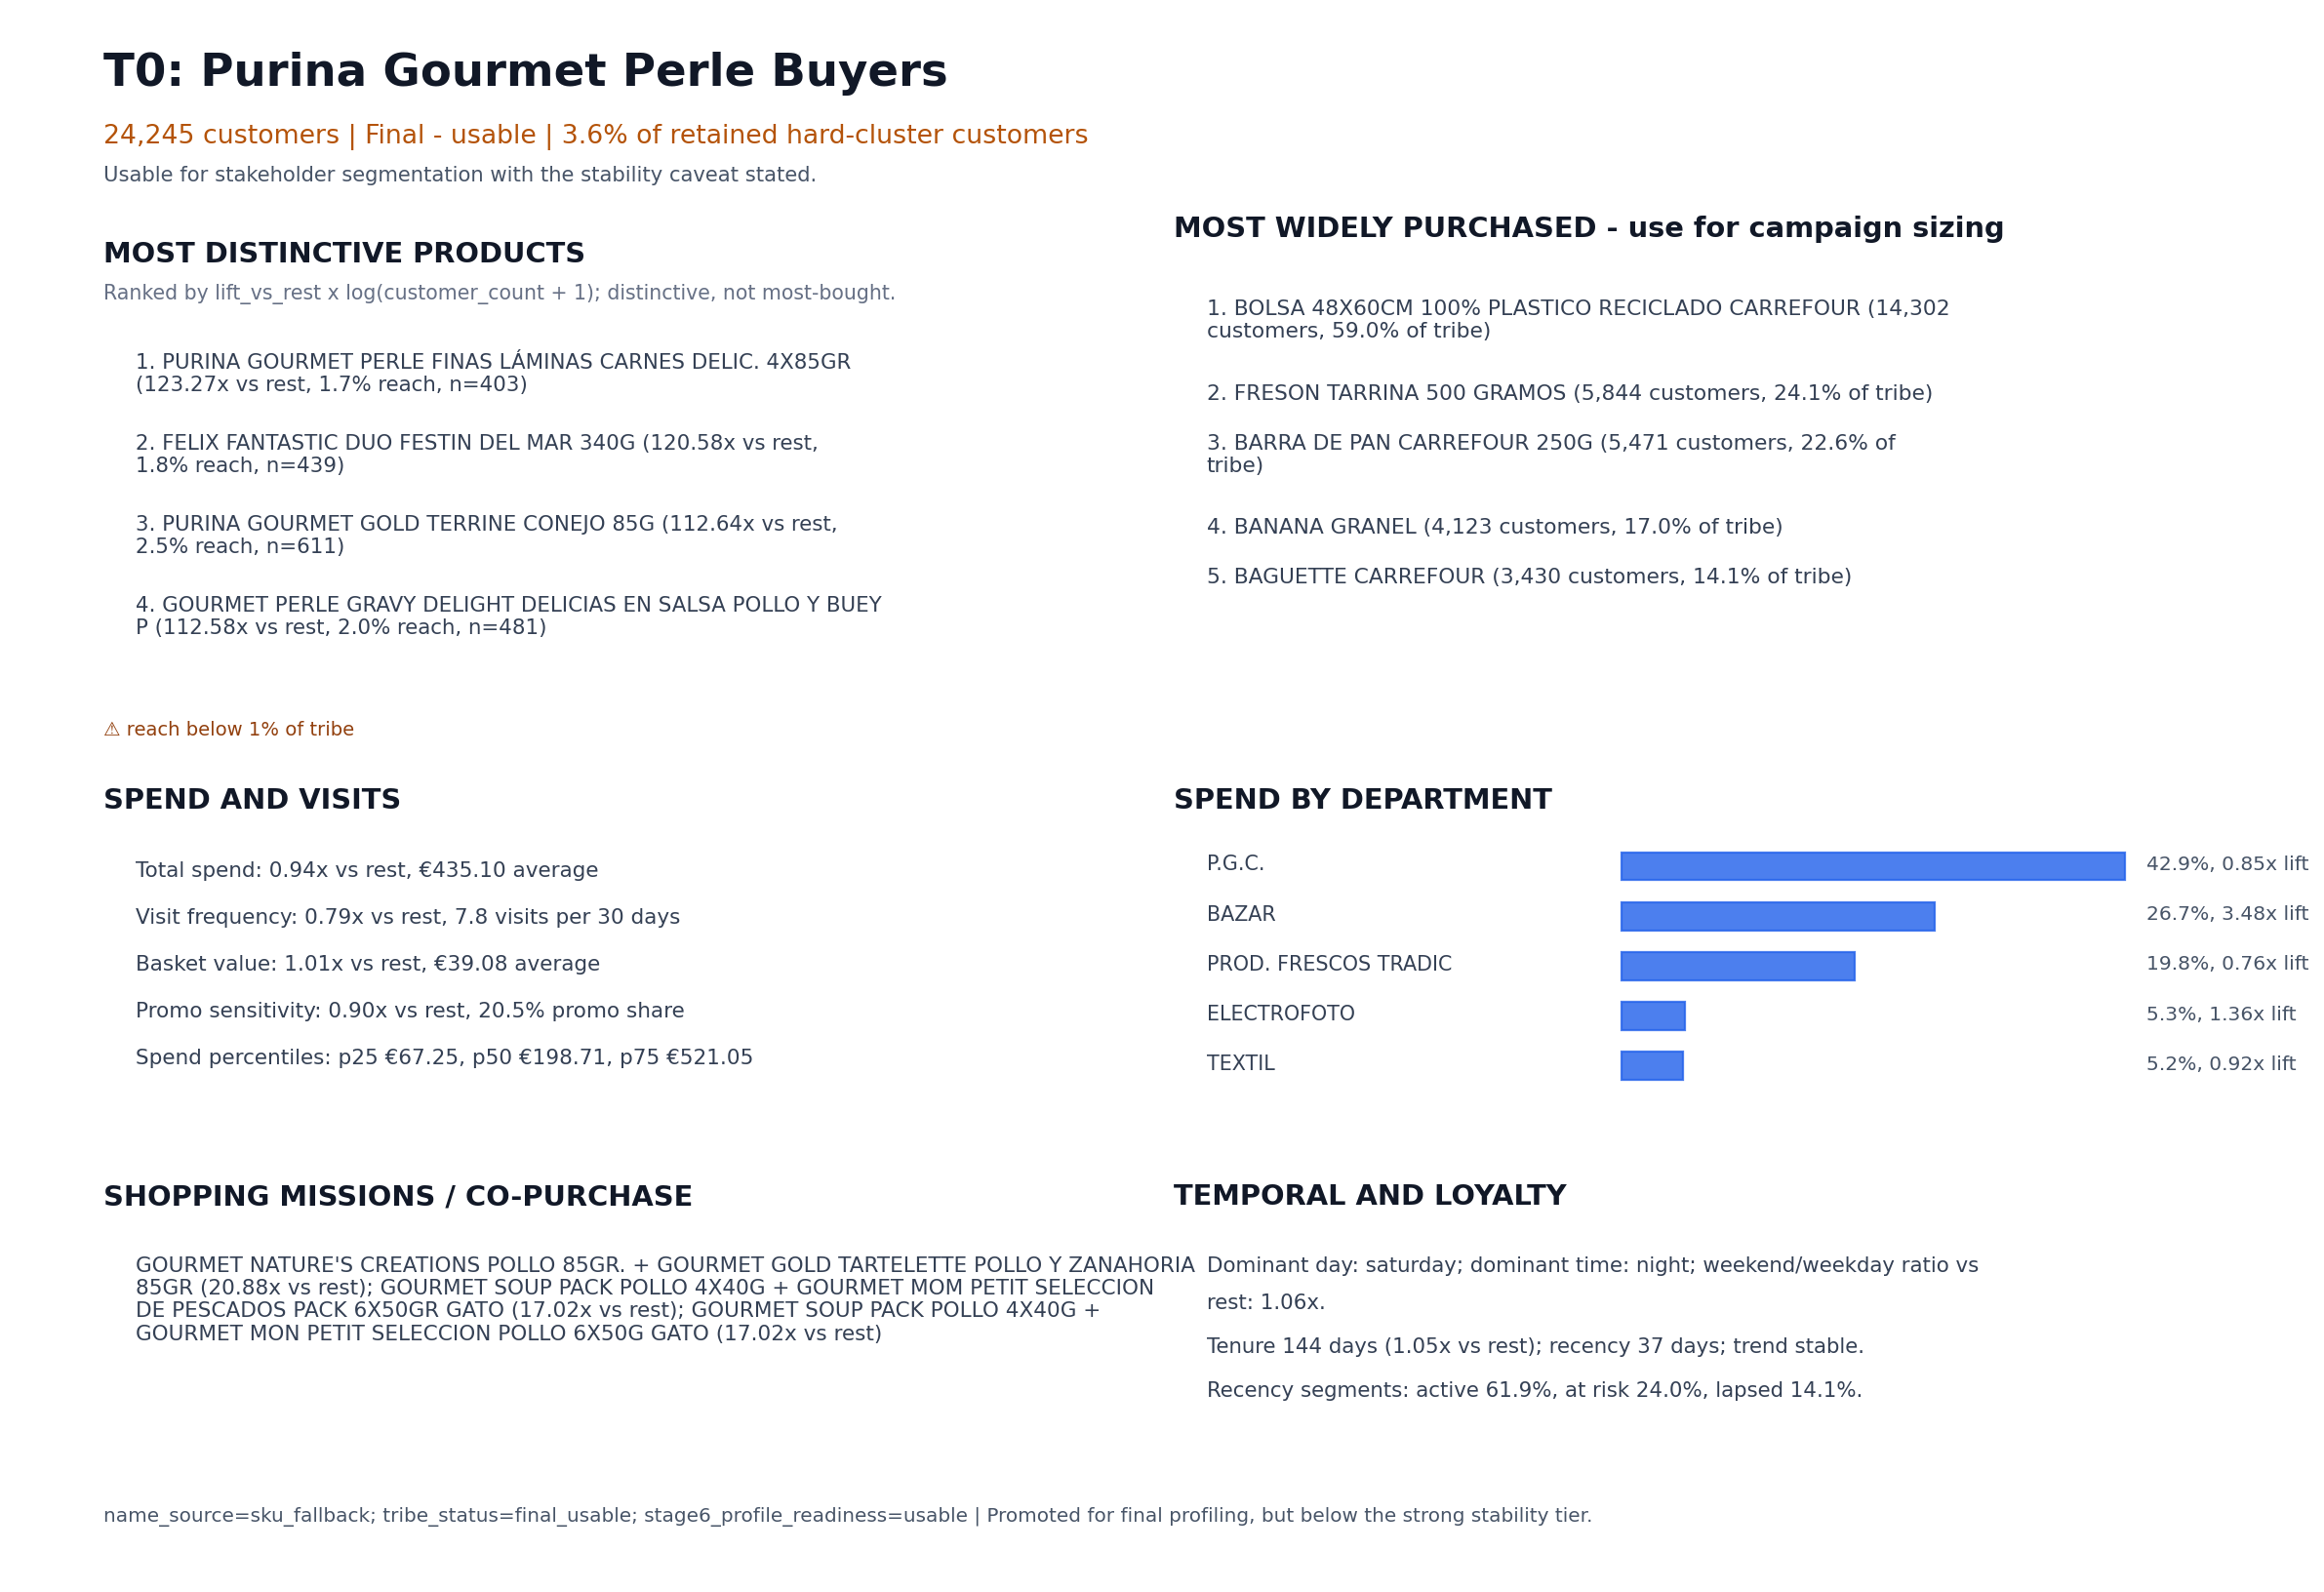

In [25]:
display(Markdown(stage7_all_tribe_dossiers_path.read_text(encoding="utf-8")))
first_card = next(iter(stage7_card_paths.values()), None)
if first_card is not None:
    display(Image(filename=str(first_card)))


### Stage 7.6: Remaining Customer Analysis

Customers still outside hard tribes after rescue. Segmented into descriptive groups (broad generalists, weak-signal, near-tribe fringe, etc.) for context — these are not tribe memberships.

In [ ]:
stage7_remaining_customer_figure = plot_stage7_remaining_customer_segments(
    stage7_remaining_customer_analysis,
    output_path=stage7_figures_dir / f"stage7_remaining_customer_segments_{CONFIG.mode}.png",
    cfg=CONFIG,
)
display(stage7_remaining_customer_analysis)
display(Image(filename=str(stage7_remaining_customer_figure)))


### Stage 7.7: Campaign-Use Soft Audiences

**Where this comes from:** centroid-rescued customers (Stage 6.5a) who landed near a specific tribe. Their top affinity score and margin to the next-closest tribe are used to filter for high-confidence assignments.

**What it shows:** for each tribe, how many rescued customers can be targeted in a campaign as a soft audience. These are not tribe members — they are activation-ready lookalikes for reach campaigns.

> Use these audiences for CRM / activation tests, not for segmentation reporting.

In [ ]:
stage7_activation_summary = (
    stage7_soft_activation_customers.group_by(["target_tribe_id", "target_tribe_name", "target_tribe_status"])
    .agg(
        pl.len().alias("activation_customers"),
        pl.col("top_affinity_score").mean().alias("mean_top_affinity"),
        pl.col("affinity_margin").mean().alias("mean_affinity_margin"),
    )
    .sort("activation_customers", descending=True)
    if not stage7_soft_activation_customers.is_empty()
    else pl.DataFrame(
        schema={
            "target_tribe_id": pl.Int64,
            "target_tribe_name": pl.Utf8,
            "target_tribe_status": pl.Utf8,
            "activation_customers": pl.Int64,
            "mean_top_affinity": pl.Float64,
            "mean_affinity_margin": pl.Float64,
        }
    )
)
if stage7_soft_audience_opportunities.is_empty():
    display(Markdown("No high-confidence campaign-use soft audience opportunities were produced."))
else:
    display(stage7_soft_audience_opportunities)
stage7_soft_audience_figure = plot_stage7_soft_audience_opportunities(
    stage7_soft_audience_opportunities,
    output_path=stage7_figures_dir / f"stage7_soft_audience_opportunities_{CONFIG.mode}.png",
    cfg=CONFIG,
)
display(Image(filename=str(stage7_soft_audience_figure)))
display(stage7_activation_summary)


### Stage 7.8: Tribe Relationships

Shows which tribes share purchasing patterns — useful for cross-sell strategy or understanding where two tribes overlap.

> **How to read the heatmap:** Each cell = combined product-overlap and behavioral-similarity score. A score near `0.6` means strong shared behavior; near `0` means fully distinct tribes. The diagonal (a tribe with itself) is masked. Only scores ≥ 0.35 are labelled.

tribe_a_id,tribe_a_name,tribe_a_status,tribe_a_status_label,tribe_b_id,tribe_b_name,tribe_b_status,tribe_b_status_label,relationship_scope,relationship_type,product_overlap_score,behavior_similarity_score,relationship_score,similarity_evidence,difference_evidence,commercial_interpretation,campaign_guidance
i64,str,str,str,i64,str,str,str,str,str,f64,f64,f64,str,str,str,str
0,"""Purina Gourmet Perle Buyers""","""final_usable""","""Final - usable""",1,"""Desayuno Empleado Especial Buy…","""final_usable""","""Final - usable""","""final_pair""","""similar_product_mission""",0.0,0.7661,0.4261,"""0 overlapping top products; sa…","""Top lifted products differ: T0…","""Treat as related missions; coo…","""Use coordinated suppression an…"
0,"""Purina Gourmet Perle Buyers""","""final_usable""","""Final - usable""",2,"""Aceite Corporal Natural Buyers""","""final_usable""","""Final - usable""","""final_pair""","""similar_product_mission""",0.0,0.5169,0.3102,"""0 overlapping top products; sa…","""Top lifted products differ: T0…","""Treat as related missions; coo…","""Use coordinated suppression an…"
0,"""Purina Gourmet Perle Buyers""","""final_usable""","""Final - usable""",3,"""Set Piezas Cuberteria Buyers""","""final_strong""","""Final - strong""","""final_pair""","""similar_product_mission""",0.0,0.4647,0.2859,"""0 overlapping top products; sa…","""Top lifted products differ: T0…","""Treat as related missions; coo…","""Use coordinated suppression an…"
0,"""Purina Gourmet Perle Buyers""","""final_usable""","""Final - usable""",4,"""Mini Rigatoni Con Buyers""","""potential_review""","""Potential / Review""","""includes_potential_review""","""similar_product_mission""",0.0,0.7246,0.4068,"""0 overlapping top products; sa…","""Top lifted products differ: T0…","""Treat as related missions; coo…","""Use coordinated suppression an…"
0,"""Purina Gourmet Perle Buyers""","""final_usable""","""Final - usable""",5,"""Chocolate Amargo Luker Buyers""","""potential_review""","""Potential / Review""","""includes_potential_review""","""similar_product_mission""",0.0,0.7524,0.4197,"""0 overlapping top products; sa…","""Top lifted products differ: T0…","""Treat as related missions; coo…","""Use coordinated suppression an…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1,"""Desayuno Empleado Especial Buy…","""final_usable""","""Final - usable""",6,"""Chirimoya Merca Buyers""","""final_usable""","""Final - usable""","""final_pair""","""similar_product_mission""",0.0,0.8673,0.4732,"""0 overlapping top products; sa…","""Top lifted products differ: T1…","""Treat as related missions; coo…","""Use coordinated suppression an…"
1,"""Desayuno Empleado Especial Buy…","""final_usable""","""Final - usable""",7,"""Patata Bio Granel Buyers""","""potential_review""","""Potential / Review""","""includes_potential_review""","""similar_product_mission""",0.0,0.759,0.4228,"""0 overlapping top products; sa…","""Top lifted products differ: T1…","""Treat as related missions; coo…","""Use coordinated suppression an…"
1,"""Desayuno Empleado Especial Buy…","""final_usable""","""Final - usable""",8,"""Dunis Azucar Sin Buyers""","""final_strong""","""Final - strong""","""final_pair""","""similar_product_mission""",0.0,0.6907,0.391,"""0 overlapping top products; sa…","""Top lifted products differ: T1…","""Treat as related missions; coo…","""Use coordinated suppression an…"


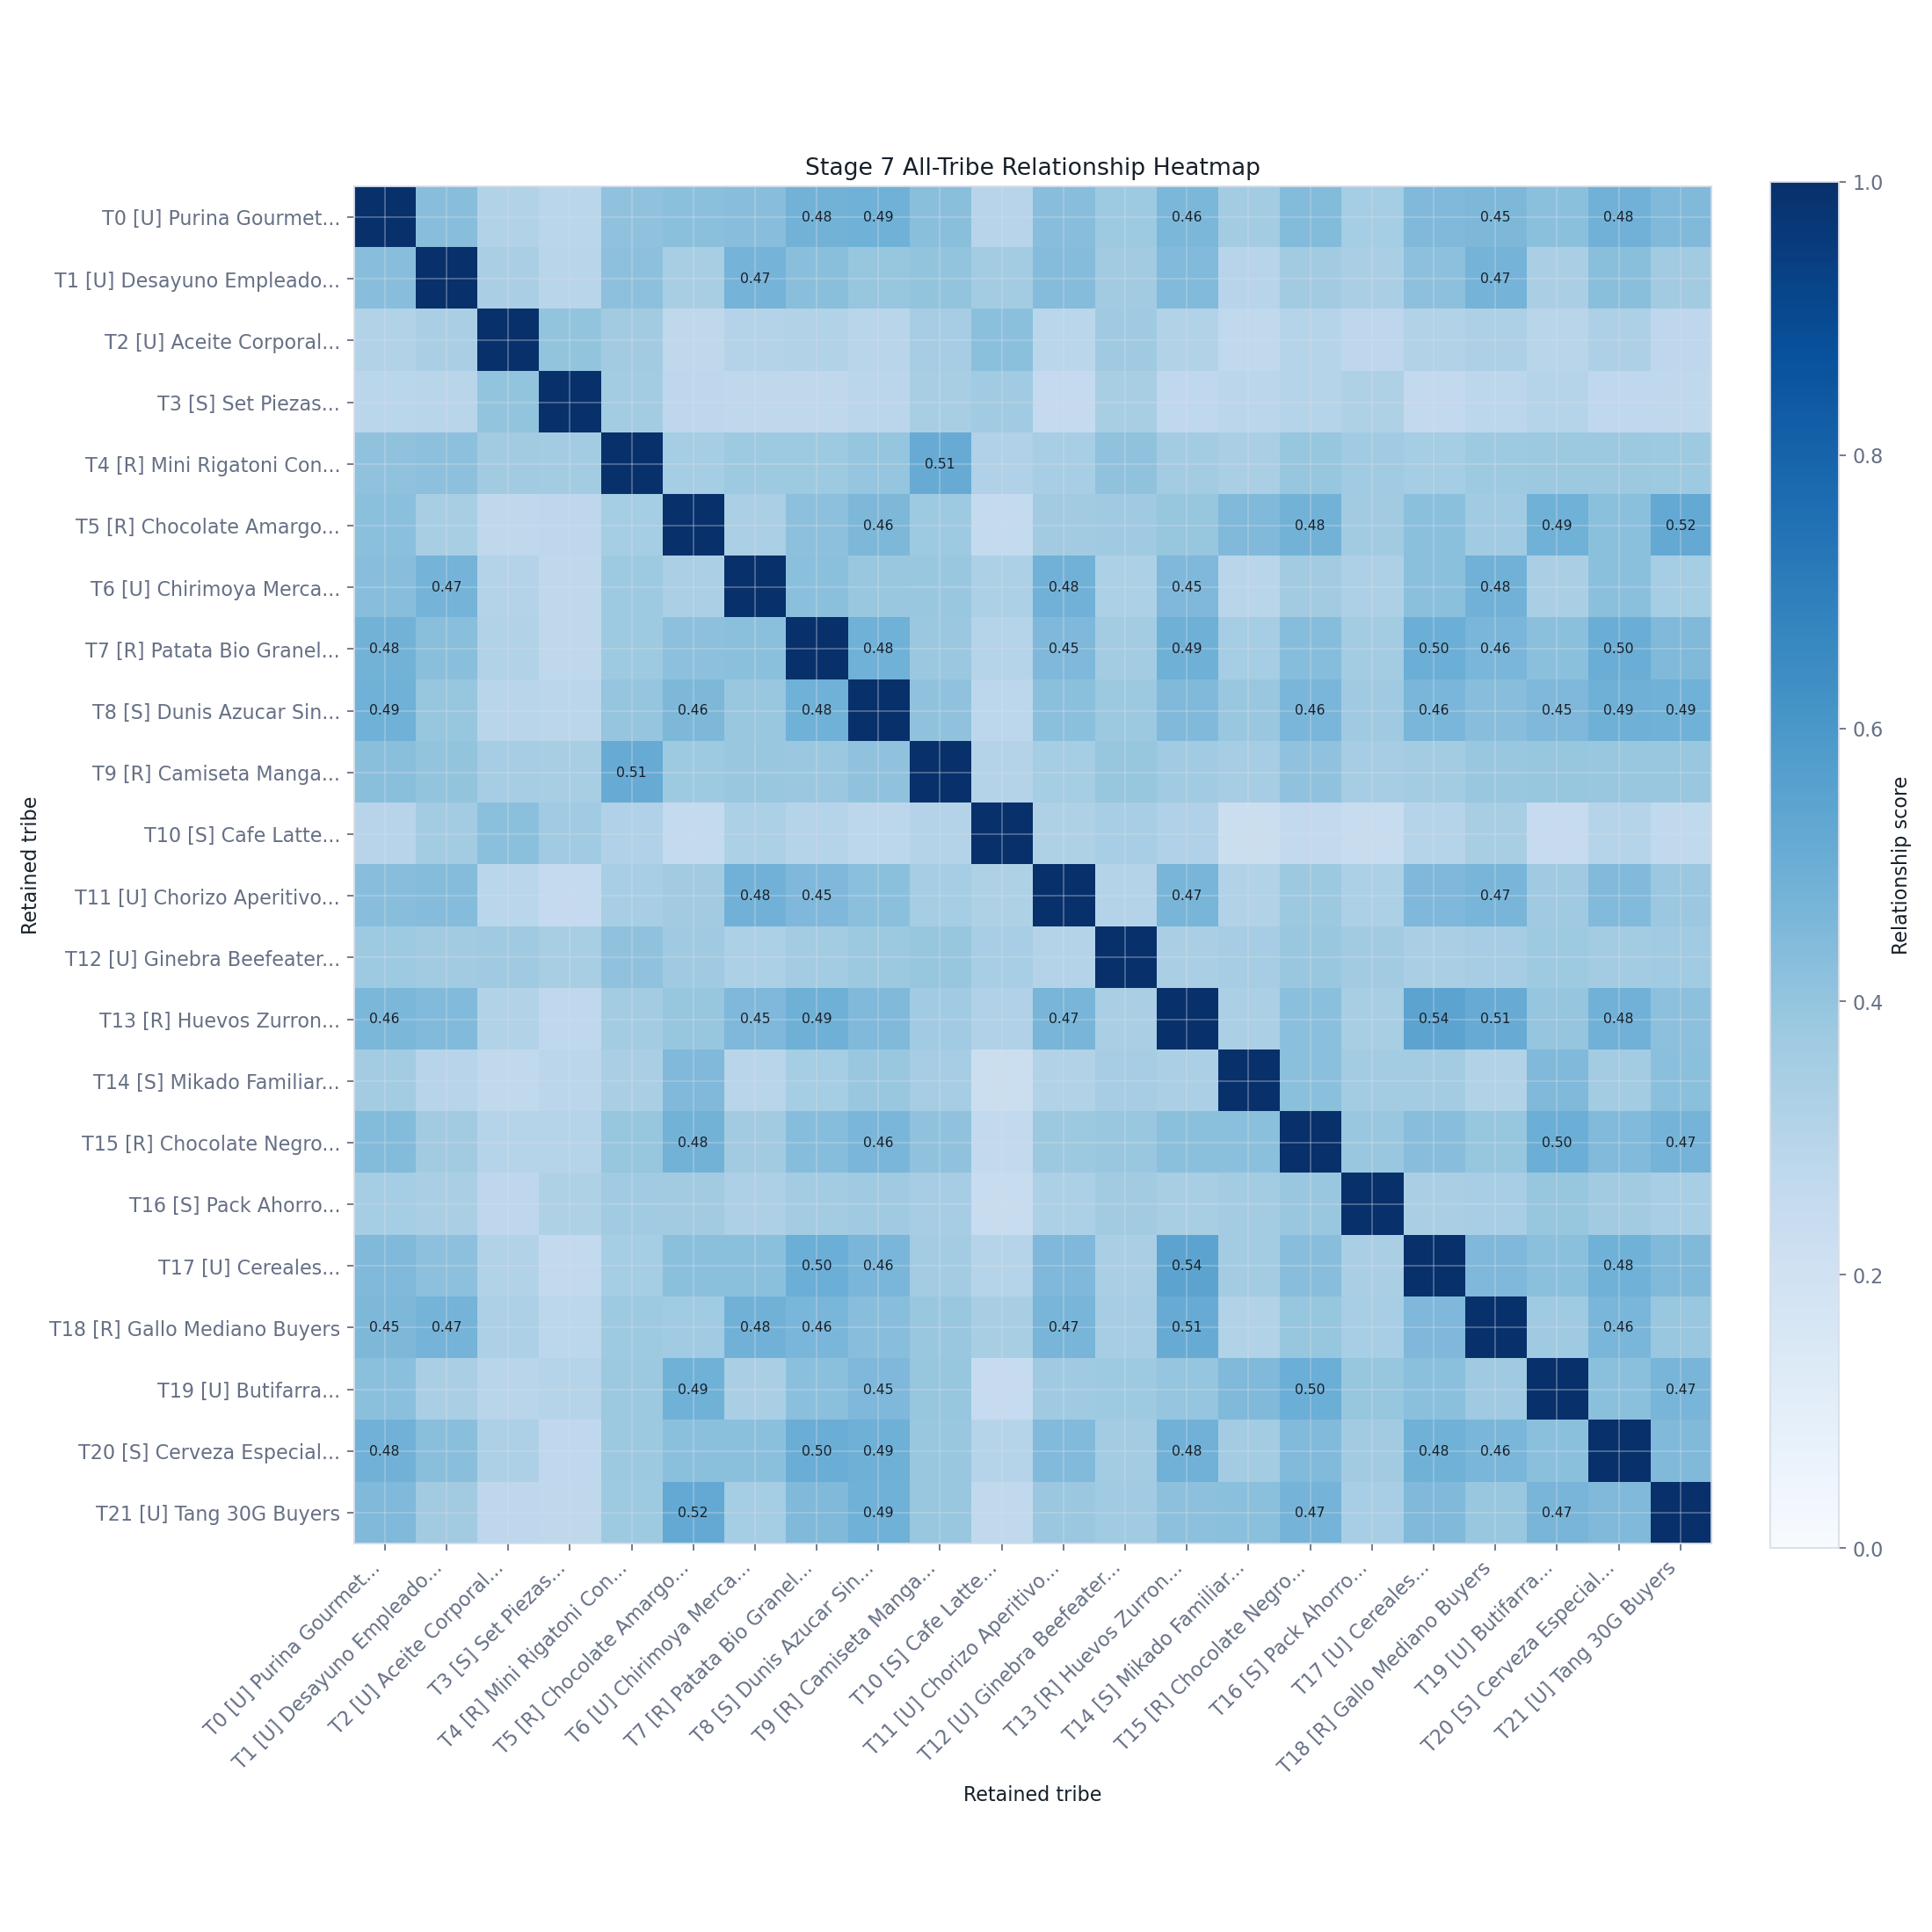

In [28]:
display(stage7_relationship_atlas.head(30))
display(Image(filename=str(stage7_relationship_heatmap)))


### Stage 7.9: Stakeholder Synthesis And Delivery Readiness

Collect the final story and delivery artifacts. Final promoted tribes, potential review tribes, and remaining/noise customers are summarized separately before the delivery readiness gate runs.


In [29]:
stage7_critical_findings = stage7_stakeholder_readiness.filter(
    (pl.col("status") == "fail") & (pl.col("severity") == "critical")
)
stage7_warning_findings = stage7_stakeholder_readiness.filter(pl.col("status") == "warn")

display(Markdown(
    f"### Stage 7 Stakeholder Handoff\n\n"
    f"Final story: {stage7_final_pack['story_markdown']}  \\n"
    f"Readable HTML: {stage7_final_pack['story_html']}  \\n"
    f"Tribe cards: {stage7_final_pack['card_directory']}  \\n"
    f"Final promoted tribes: {stage7_final_tribes}; potential review tribes: {stage7_review_clusters}.  \\n"
    f"Evidence bundle: {stage68_manifest_path}  \\n"
    "Use final promoted tribes for stakeholder segmentation; use potential review tribes only as hypothesis/test audiences."
))
display(Markdown(
    "### Supporting Evidence\n\n"
    f"- Final index: {stage7_final_pack['index_csv']}\n"
    f"- All-tribe product identity: {stage7_substage_paths['all_tribe_product_identity']['csv']}\n"
    f"- All-tribe behavior differentiation: {stage7_substage_paths['all_tribe_behavior_differentiation']['csv']}\n"
    f"- All-tribe dossiers: {stage7_substage_paths['all_tribe_dossiers']['markdown']}\n"
    f"- All-tribe relationship atlas: {stage7_substage_paths['all_tribe_relationship_atlas']['csv']}\n"
    f"- Remaining customer analysis: {stage7_substage_paths['remaining_customer_analysis']['csv']}\n"
    f"- Manifest: {stage7_final_pack['manifest_json']}"
))
display(stage7_stakeholder_readiness)
if not stage7_warning_findings.is_empty():
    display(Markdown("### Stage 7.9 Warnings"))
    display(stage7_warning_findings)
display(Markdown("### Stage 7.9 Final-Only Campaign Playbook"))
display(stage7_campaign_playbook)
display(Markdown(
    f"Readiness report: {stage7_stakeholder_readiness_paths['csv']}  \\n"
    f"Campaign playbook: {stage7_campaign_playbook_paths['csv']}  \\n"
    f"Activation customers CSV: {stage7_soft_activation_customers_path}  \\n"
    f"Activation customers parquet: {stage7_final_pack['soft_audience_activation_customers_parquet']}"
))

fail_on_critical = bool(CONFIG.get("profiling.stage7_delivery_readiness.fail_on_critical", True))
if fail_on_critical and not stage7_critical_findings.is_empty():
    raise ValueError(
        "Stage 7.9 stakeholder readiness failed. "
        f"Critical findings: {stage7_critical_findings['check_id'].to_list()}"
    )


### Stage 7 Stakeholder Handoff

Final story: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\final_handoff\stage7_final_story_prod.md  \nReadable HTML: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\final_handoff\stage7_final_story_prod.html  \nTribe cards: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\final_handoff\tribe_cards  \nFinal promoted tribes: 15; potential review tribes: 7.  \nEvidence bundle: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage6\stage6_8_evidence\stage68_manifest_prod.json  \nUse final promoted tribes for stakeholder segmentation; use potential review tribes only as hypothesis/test audiences.

### Supporting Evidence

- Final index: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\final_handoff\stage7_final_index_prod.csv
- All-tribe product identity: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\stage7_all_tribe_product_identity_prod.csv
- All-tribe behavior differentiation: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\stage7_all_tribe_behavior_differentiation_prod.csv
- All-tribe dossiers: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\stage7_all_tribe_dossiers_prod.md
- All-tribe relationship atlas: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\stage7_all_tribe_relationship_atlas_prod.csv
- Remaining customer analysis: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\stage7_remaining_customer_analysis_prod.csv
- Manifest: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\final_handoff\stage7_final_manifest_prod.json

check_id,check_area,severity,status,issue_count,affected_items,details,recommended_action
str,str,str,str,i64,str,str,str
"""overall_delivery_readiness""","""overall""","""critical""","""warn""",1,"""stage7""","""0 critical issue(s); 1 warning…","""Review warnings before final p…"
"""tribe_name_quality""","""tribe naming""","""warning""","""pass""",0,"""none""","""Promoted tribe names must be u…","""No action required."""
"""promoted_tribe_product_evidenc…","""product evidence""","""warning""","""warn""",2,"""T2 Aceite Corporal Natural Buy…","""Promoted tribes have product h…","""Keep the reach caveat visible …"
"""persona_specificity""","""persona prose""","""critical""","""pass""",0,"""none""","""Promoted persona prose must be…","""No action required."""
"""remaining_customer_segments""","""remaining customers""","""critical""","""pass""",0,"""none""","""Unclear long-tail share must b…","""No action required."""
"""soft_audience_activation_expor…","""soft audiences""","""critical""","""pass""",0,"""none""","""Soft audience aggregates imply…","""No action required."""
"""campaign_playbook_completeness""","""campaign playbook""","""critical""","""pass""",0,"""none""","""Every promoted tribe needs off…","""No action required."""


### Stage 7.9 Warnings

check_id,check_area,severity,status,issue_count,affected_items,details,recommended_action
str,str,str,str,i64,str,str,str
"""overall_delivery_readiness""","""overall""","""critical""","""warn""",1,"""stage7""","""0 critical issue(s); 1 warning…","""Review warnings before final p…"
"""promoted_tribe_product_evidenc…","""product evidence""","""warning""","""warn""",2,"""T2 Aceite Corporal Natural Buy…","""Promoted tribes have product h…","""Keep the reach caveat visible …"


### Stage 7.9 Final-Only Campaign Playbook

tribe_id,tribe_name,audience_definition,targeting_hook,offer_idea,recommended_channel,suppression_rules,holdout_control_design,primary_kpi,secondary_kpis,expected_commercial_lever,risk_caveat,evidence_basis
i64,str,str,str,str,str,str,str,str,str,str,str,str
0,"""Purina Gourmet Perle Buyers""","""Official hard-assigned promote…","""Lifted-product proof: CATISFAC…","""Mission-led recommendation set…","""App push, loyalty app placemen…","""Suppress customers already tar…","""Hold out 10-15% of eligible cu…","""Incremental visit frequency.""","""Incremental revenue, basket si…","""Increase frequency, basket bre…","""Evidence is based on purchase …","""Lifted-product proof: CATISFAC…"
1,"""Desayuno Empleado Especial Buy…","""Official hard-assigned promote…","""Lifted-product proof: DESAYUNO…","""Mission-led recommendation set…","""Email/CRM test with app retarg…","""Suppress customers already tar…","""Hold out 10-15% of eligible cu…","""Incremental basket value and p…","""Incremental revenue, basket si…","""Increase frequency, basket bre…","""Evidence is based on purchase …","""Lifted-product proof: DESAYUNO…"
2,"""Aceite Corporal Natural Buyers""","""Official hard-assigned promote…","""Lifted-product proof: MAYBELLI…","""Personalized value bundle anch…","""CRM/email plus app push reacti…","""Suppress customers already tar…","""Hold out 10-15% of eligible cu…","""Incremental basket value and p…","""Incremental revenue, basket si…","""Improve promotion efficiency t…","""Evidence is based on purchase …","""Lifted-product proof: MAYBELLI…"
3,"""Set Piezas Cuberteria Buyers""","""Official hard-assigned promote…","""Lifted-product proof: SET 24 P…","""Personalized value bundle anch…","""CRM/email plus app push reacti…","""Suppress customers already tar…","""Hold out 10-15% of eligible cu…","""Incremental basket value and p…","""Incremental revenue, basket si…","""Improve promotion efficiency t…","""Evidence is based on purchase …","""Lifted-product proof: SET 24 P…"
6,"""Chirimoya Merca Buyers""","""Official hard-assigned promote…","""Lifted-product proof: BAGUETTE…","""Mission-led recommendation set…","""App push, loyalty app placemen…","""Suppress customers already tar…","""Hold out 10-15% of eligible cu…","""Incremental visit frequency.""","""Incremental revenue, basket si…","""Increase frequency, basket bre…","""Evidence is based on purchase …","""Lifted-product proof: BAGUETTE…"
…,…,…,…,…,…,…,…,…,…,…,…,…
16,"""Pack Ahorro Lentejas Buyers""","""Official hard-assigned promote…","""Lifted-product proof: HELADO B…","""Personalized value bundle anch…","""App push, loyalty app placemen…","""Suppress customers already tar…","""Hold out 10-15% of eligible cu…","""Incremental revenue per target…","""Incremental revenue, basket si…","""Grow and retain high-value bas…","""Evidence is based on purchase …","""Lifted-product proof: HELADO B…"
17,"""Cereales Integrales Nesquik Bu…","""Official hard-assigned promote…","""Lifted-product proof: CEREALES…","""Mission-led recommendation set…","""App push, loyalty app placemen…","""Suppress customers already tar…","""Hold out 10-15% of eligible cu…","""Incremental visit frequency.""","""Incremental revenue, basket si…","""Increase frequency, basket bre…","""Evidence is based on purchase …","""Lifted-product proof: CEREALES…"
19,"""Butifarra Catalana Exentis Buy…","""Official hard-assigned promote…","""Lifted-product proof: SALCHICH…","""Personalized value bundle anch…","""App push, loyalty app placemen…","""Suppress customers already tar…","""Hold out 10-15% of eligible cu…","""Incremental revenue per target…","""Incremental revenue, basket si…","""Grow and retain high-value bas…","""Evidence is based on purchase …","""Lifted-product proof: SALCHICH…"


Readiness report: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\stage7_stakeholder_readiness_prod.csv  \nCampaign playbook: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\stage7_campaign_playbook_prod.csv  \nActivation customers CSV: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\stage7_soft_audience_activation_customers_prod.csv  \nActivation customers parquet: C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage7\stage7_soft_audience_activation_customers_prod.parquet

<a id="stage-8"></a>

## Stage 8: Dashboard Data Pack

Builds and validates all dashboard-ready tables. Counts, schemas, and headline numbers are checked before anything reaches the presentation layer.

In [30]:
import importlib
import json
from pathlib import Path

import polars as pl
from IPython.display import Markdown, display

import src.stage8
importlib.reload(src.stage8)
from src.stage8 import STAGE8_SCHEMA_VERSION, stage8_artifact_paths, write_stage8_dashboard_pack

# Equivalent terminal command: CARREFOUR_MODE=prod python -m src.stage8
stage8_outputs = write_stage8_dashboard_pack(cfg=CONFIG)
stage8_paths = stage8_artifact_paths(cfg=CONFIG)
stage8_manifest_path = stage8_paths["dashboard_manifest"]
stage8_manifest = json.loads(stage8_manifest_path.read_text(encoding="utf-8"))
stage8_products = stage8_manifest["created_products"]

stage8_inventory_rows = []
for product in stage8_products:
    path = Path(product["path"])
    schema = product.get("schema") or []
    pages = product.get("dashboard_pages") or []
    stage8_inventory_rows.append(
        {
            "name": product["name"],
            "format": product.get("format"),
            "exists": path.exists(),
            "row_count": product.get("row_count"),
            "column_count": len(schema),
            "dashboard_pages": "; ".join(pages),
            "schema_preview": ", ".join(schema[:12]) + (" ..." if len(schema) > 12 else ""),
            "size_mb": round(path.stat().st_size / 1_000_000, 3) if path.exists() else None,
            "path": str(path),
        }
    )

stage8_artifact_inventory = pl.DataFrame(stage8_inventory_rows, infer_schema_length=None).sort(["format", "name"])
stage8_table_artifacts = stage8_artifact_inventory.filter(pl.col("format").is_in(["parquet", "csv"]))
stage8_non_table_artifacts = stage8_artifact_inventory.filter(~pl.col("format").is_in(["parquet", "csv"]))

stage8_readiness = pl.read_csv(stage8_paths["readiness_csv"])
stage8_readiness_status = stage8_manifest.get("readiness_summary", {})

display(Markdown(
    f"### Stage 8 Build Summary\n\n"
    f"Manifest: `{stage8_manifest_path}`  \n"
    f"Schema version: `{stage8_manifest.get('schema_version')}` / expected `{STAGE8_SCHEMA_VERSION}`  \n"
    f"Artifacts created: `{len(stage8_products)}`  \n"
    f"Table artifacts: `{stage8_table_artifacts.height}`  \n"
    f"Readiness: `{stage8_readiness_status}`"
))
display(stage8_artifact_inventory.select([
    "name", "format", "exists", "row_count", "column_count", "size_mb", "dashboard_pages", "schema_preview"
]))
display(Markdown("### Stage 8 Readiness Report"))
display(stage8_readiness)


[19:13:19] Stage 8: building dashboard-ready semantic layer
[19:13:47] Stage 8: finished | elapsed_s=28.7000
[19:13:47] Stage 8: wrote dashboard-ready semantic pack | output_dir=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage8, manifest=C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage8\dashboard_manifest_prod.json


### Stage 8 Build Summary

Manifest: `C:\Users\rothl\Desktop\IE Capstone\carrefour_capstone\outputs\prod\artifacts\stage8\dashboard_manifest_prod.json`  
Schema version: `1` / expected `1`  
Artifacts created: `57`  
Table artifacts: `49`  
Readiness: `{'status': 'pass', 'critical_failures': 0, 'warnings': 0}`

name,format,exists,row_count,column_count,size_mb,dashboard_pages,schema_preview
str,str,bool,i64,i64,f64,str,str
"""readiness_csv""","""csv""",true,11,5,0.001,"""Technical Appendix""","""check_id, check_area, severity…"
"""completeness_audit_json""","""json""",true,null,9,0.014,"""Technical Appendix""","""created_artifact_count, delive…"
"""relational_manifest""","""json""",true,null,10,0.042,"""Technical Appendix; all""","""artifact_manifest, canonical_d…"
"""completeness_audit""","""md""",true,null,0,0.006,"""Technical Appendix""",""""""
"""presentation_mart_data_diction…","""md""",true,null,0,0.013,"""Technical Appendix""",""""""
…,…,…,…,…,…,…,…
"""rel_mart_tribe_product_evidenc…","""parquet""",true,330,23,0.026,"""Product Affinity Explorer; Tri…","""tribe_id, tribe_display_name, …"
"""rel_mart_tribe_scorecard""","""parquet""",true,22,22,0.016,"""Tribe Explorer; Executive Over…","""tribe_id, tribe_display_name, …"
"""rel_mart_validation_report""","""parquet""",true,68,6,0.004,"""Technical Appendix; Backend & …","""check_id, check_area, severity…"


### Stage 8 Readiness Report

check_id,check_area,severity,status,details
str,str,str,str,str
"""input_audit""","""inputs""","""critical""","""pass""","""0 required input(s) missing."""
"""manifest_paths_exist""","""outputs""","""critical""","""pass""","""All Stage 8 outputs exist."""
"""no_markdown_dependencies""","""contract""","""critical""","""pass""","""No Markdown input dependencies…"
"""customer_coverage_reconciles""","""coverage""","""critical""","""pass""","""customer_coverage rows=1478831…"
"""promoted_review_counts""","""coverage""","""critical""","""pass""","""final=15/15; review=7/7."""
…,…,…,…,…
"""every_tribe_has_deep_dive""","""tribe deep dive""","""critical""","""pass""","""All retained tribes have deep-…"
"""every_promoted_tribe_has_actio…","""activation""","""critical""","""pass""","""All promoted tribes have actio…"
"""embedding_3d_valid""","""embeddings""","""critical""","""pass""","""finite=True; unique_customers=…"


In [31]:
EXPECTED_STAGE8_COUNTS = {
    "total_customers": 1_478_831,
    "retained_hard_tribes": 22,
    "final_promoted_tribes": 15,
    "review_tribes": 7,
    "final_customers": 301_041,
    "review_customers": 375_800,
    "remaining_customers": 801_990,
    "remaining_segments": 6,
}

stage8_dim_tribe = pl.read_parquet(stage8_paths["rel_dim_tribe"])
stage8_fact_tribe_metrics = pl.read_parquet(stage8_paths["rel_fact_tribe_metrics"])
stage8_fact_tribe_product = pl.read_parquet(stage8_paths["rel_fact_tribe_product_affinity"])
stage8_dim_action_target = pl.read_parquet(stage8_paths["rel_dim_action_target"])
stage8_fact_segment_action = pl.read_parquet(stage8_paths["rel_fact_segment_action"])
stage8_fact_coverage_metrics = pl.read_parquet(stage8_paths["rel_fact_coverage_group_metrics"])
stage8_dim_coverage_group = pl.read_parquet(stage8_paths["rel_dim_coverage_group"])
stage8_fact_remaining_segment_metrics = pl.read_parquet(stage8_paths["rel_fact_remaining_segment_metrics"])
stage8_embedding_sample_assignments = (
    pl.read_parquet(stage8_paths["rel_fact_embedding_3d_sample"])
    .join(
        pl.read_parquet(stage8_paths["rel_fact_customer_assignment"], columns=["cliente", "tribe_id", "coverage_group"]),
        on="cliente",
        how="left",
    )
)

stage8_total_customers = int(stage8_fact_coverage_metrics.select(pl.col("customers").sum()).item())
stage8_final_customers = int(stage8_fact_coverage_metrics.filter(pl.col("coverage_group") == "core_promoted_tribe").select(pl.col("customers").sum()).item())
stage8_review_customers = int(stage8_fact_coverage_metrics.filter(pl.col("coverage_group") == "review_tribe").select(pl.col("customers").sum()).item())
stage8_remaining_customers = stage8_total_customers - stage8_final_customers - stage8_review_customers
stage8_retained_hard_customers = int(stage8_fact_tribe_metrics.select(pl.col("hard_assigned_customers").sum()).item())
stage8_final_tribes = int(stage8_dim_tribe.filter(pl.col("is_final_tribe")).height)
stage8_review_tribes = int(stage8_dim_tribe.filter(pl.col("is_review_tribe")).height)

stage8_assignment_uniqueness = pl.scan_parquet(stage8_paths["rel_fact_customer_assignment"]).select(
    pl.len().alias("rows"),
    pl.col("cliente").n_unique().alias("unique_clientes"),
).collect().row(0, named=True)
stage8_value_behavior_uniqueness = pl.scan_parquet(stage8_paths["rel_fact_customer_value_behavior"]).select(
    pl.len().alias("rows"),
    pl.col("cliente").n_unique().alias("unique_clientes"),
).collect().row(0, named=True)
stage8_embedding_uniqueness = pl.scan_parquet(stage8_paths["rel_fact_embedding_3d"]).select(
    pl.len().alias("rows"),
    pl.col("cliente").n_unique().alias("unique_clientes"),
    pl.all_horizontal([pl.col(c).is_finite().fill_null(False) for c in ["x", "y", "z"]]).all().alias("xyz_finite"),
).collect().row(0, named=True)
stage8_embedding_sample_check = pl.scan_parquet(stage8_paths["rel_fact_embedding_3d_sample"]).select(
    pl.len().alias("rows"),
    pl.col("cliente").n_unique().alias("unique_clientes"),
    pl.all_horizontal([pl.col(c).is_finite().fill_null(False) for c in ["x", "y", "z"]]).all().alias("xyz_finite"),
).collect().row(0, named=True)

stage8_manifest_missing_outputs = sorted(
    product["name"] for product in stage8_products if not Path(product["path"]).exists()
)
stage8_markdown_inputs = sorted(
    key for key, value in stage8_manifest.get("input_paths", {}).items()
    if Path(value).suffix.lower() in {".md", ".markdown"}
)
stage8_manifest_table_names = set(stage8_table_artifacts["name"].to_list())
stage8_required_table_names = {
    "artifact_manifest", "relational_integrity_report",
    "rel_dim_tribe", "rel_dim_tribe_name_proposal", "rel_dim_coverage_group", "rel_dim_remaining_segment",
    "rel_dim_product", "rel_dim_category", "rel_dim_action_target", "rel_dim_dashboard_page", "rel_dim_visualization",
    "rel_dim_pipeline_stage", "rel_dim_model_card", "rel_dim_feature_group", "rel_dim_story_chapter", "rel_dim_executive_insight",
    "rel_fact_executive_metric", "rel_fact_customer_assignment", "rel_fact_customer_value_behavior", "rel_fact_customer_nearest_tribe",
    "rel_fact_tribe_metrics", "rel_fact_tribe_profile_text", "rel_fact_coverage_group_metrics", "rel_fact_remaining_segment_metrics",
    "rel_fact_tribe_product_affinity", "rel_fact_tribe_category_affinity", "rel_fact_segment_action",
    "rel_bridge_tribe_similarity", "rel_fact_embedding_2d", "rel_fact_embedding_3d", "rel_fact_embedding_3d_sample",
    "rel_fact_embedding_3d_pca", "rel_fact_embedding_3d_pca_sample", "rel_fact_embedding_centroid",
    "rel_fact_validation_metric", "rel_fact_data_quality_metric",
}
stage8_missing_required_tables = sorted(stage8_required_table_names - stage8_manifest_table_names)
stage8_forbidden_legacy_products = {
    "tribe_master", "tribe_profiles", "tribe_deep_dive", "tribe_products", "tribe_categories",
    "customer_assignments", "customer_coverage", "customer_coverage_summary", "remaining_customer_segments",
    "segment_actions", "embedding_2d", "embedding_3d", "embedding_3d_sample", "model_cards",
    "pipeline_stages", "feature_catalog", "validation_metrics", "data_quality_metrics", "dashboard_page_contracts",
    "visualization_specs", "missing_file_register",
}
stage8_present_legacy_products = sorted(stage8_forbidden_legacy_products & set(item["name"] for item in stage8_products))

stage8_master_tribes = set(stage8_dim_tribe["tribe_id"].to_list())
stage8_product_tribes = set(stage8_fact_tribe_product.select("tribe_id").unique()["tribe_id"].to_list())
stage8_missing_product_evidence = sorted(stage8_master_tribes - stage8_product_tribes)
stage8_promoted_tribes = set(stage8_dim_tribe.filter(pl.col("is_final_tribe"))["tribe_id"].to_list())
stage8_action_fact_targets = set(stage8_fact_segment_action["target_id"].to_list())
stage8_action_tribes = set(
    stage8_dim_action_target
    .filter((pl.col("target_type") == "tribe") & pl.col("tribe_id").is_not_null() & pl.col("target_id").is_in(stage8_action_fact_targets))
    .select("tribe_id")
    .unique()["tribe_id"]
    .to_list()
)
stage8_missing_promoted_actions = sorted(stage8_promoted_tribes - stage8_action_tribes)
stage8_sample_tribes = set(stage8_embedding_sample_assignments.filter(pl.col("tribe_id").is_not_null())["tribe_id"].to_list())
stage8_sample_groups = set(stage8_embedding_sample_assignments["coverage_group"].to_list())
stage8_coverage_groups = set(stage8_fact_coverage_metrics["coverage_group"].to_list())
stage8_missing_sample_tribes = sorted(stage8_master_tribes - stage8_sample_tribes)
stage8_missing_sample_groups = sorted(stage8_coverage_groups - stage8_sample_groups)
stage8_readiness_critical_failures = stage8_readiness.filter(
    (pl.col("status") == "fail") & (pl.col("severity") == "critical")
).height
stage8_relational_integrity = pl.read_parquet(stage8_paths["relational_integrity_report"])
stage8_relational_integrity_failures = stage8_relational_integrity.filter(pl.col("status") == "fail").height


def stage8_check(check_id, area, severity, passed, details):
    return {
        "check_id": check_id,
        "area": area,
        "severity": severity,
        "status": "pass" if passed else "fail",
        "details": details,
    }

stage8_sanity_rows = [
    stage8_check("manifest_paths_exist", "manifest", "critical", not stage8_manifest_missing_outputs, f"missing={stage8_manifest_missing_outputs}"),
    stage8_check("schema_version", "manifest", "critical", stage8_manifest.get("schema_version") == STAGE8_SCHEMA_VERSION, f"actual={stage8_manifest.get('schema_version')}, expected={STAGE8_SCHEMA_VERSION}"),
    stage8_check("no_markdown_input_dependencies", "contract", "critical", not stage8_markdown_inputs, f"markdown_inputs={stage8_markdown_inputs}"),
    stage8_check("required_relational_tables_present", "contract", "critical", not stage8_missing_required_tables, f"missing={stage8_missing_required_tables}"),
    stage8_check("legacy_wide_products_not_published", "contract", "critical", not stage8_present_legacy_products, f"legacy_present={stage8_present_legacy_products}"),
    stage8_check("readiness_report_has_no_critical_failures", "readiness", "critical", stage8_readiness_critical_failures == 0, f"critical_failures={stage8_readiness_critical_failures}"),
    stage8_check("relational_integrity_has_no_failures", "relational_model", "critical", stage8_relational_integrity_failures == 0, f"failures={stage8_relational_integrity_failures}"),
]

if CONFIG.mode == "prod":
    stage8_sanity_rows.extend([
        stage8_check("total_customer_reconciliation", "coverage", "critical", stage8_total_customers == EXPECTED_STAGE8_COUNTS["total_customers"], f"actual={stage8_total_customers:,}, expected={EXPECTED_STAGE8_COUNTS['total_customers']:,}"),
        stage8_check("final_customer_reconciliation", "coverage", "critical", stage8_final_customers == EXPECTED_STAGE8_COUNTS["final_customers"], f"actual={stage8_final_customers:,}, expected={EXPECTED_STAGE8_COUNTS['final_customers']:,}"),
        stage8_check("review_customer_reconciliation", "coverage", "critical", stage8_review_customers == EXPECTED_STAGE8_COUNTS["review_customers"], f"actual={stage8_review_customers:,}, expected={EXPECTED_STAGE8_COUNTS['review_customers']:,}"),
        stage8_check("remaining_customer_reconciliation", "coverage", "critical", stage8_remaining_customers == EXPECTED_STAGE8_COUNTS["remaining_customers"], f"actual={stage8_remaining_customers:,}, expected={EXPECTED_STAGE8_COUNTS['remaining_customers']:,}"),
        stage8_check("retained_hard_tribe_count", "tribes", "critical", stage8_dim_tribe.height == EXPECTED_STAGE8_COUNTS["retained_hard_tribes"], f"actual={stage8_dim_tribe.height}, expected={EXPECTED_STAGE8_COUNTS['retained_hard_tribes']}"),
        stage8_check("promoted_tribe_count", "tribes", "critical", stage8_final_tribes == EXPECTED_STAGE8_COUNTS["final_promoted_tribes"], f"actual={stage8_final_tribes}, expected={EXPECTED_STAGE8_COUNTS['final_promoted_tribes']}"),
        stage8_check("review_tribe_count", "tribes", "critical", stage8_review_tribes == EXPECTED_STAGE8_COUNTS["review_tribes"], f"actual={stage8_review_tribes}, expected={EXPECTED_STAGE8_COUNTS['review_tribes']}"),
        stage8_check("remaining_segment_count", "remaining_customers", "critical", stage8_fact_remaining_segment_metrics.height == EXPECTED_STAGE8_COUNTS["remaining_segments"], f"actual={stage8_fact_remaining_segment_metrics.height}, expected={EXPECTED_STAGE8_COUNTS['remaining_segments']}"),
    ])
else:
    stage8_sanity_rows.append(stage8_check("non_prod_customer_reconciliation", "coverage", "warn", stage8_total_customers > 0, f"mode={CONFIG.mode}; exact prod counts skipped; total={stage8_total_customers:,}"))

stage8_sanity_rows.extend([
    stage8_check("hard_tribe_customers_equal_final_plus_review", "coverage", "critical", stage8_retained_hard_customers == stage8_final_customers + stage8_review_customers, f"hard={stage8_retained_hard_customers:,}; final+review={stage8_final_customers + stage8_review_customers:,}"),
    stage8_check("customer_assignments_unique_by_cliente", "lookup", "critical", stage8_assignment_uniqueness["rows"] == stage8_assignment_uniqueness["unique_clientes"], str(stage8_assignment_uniqueness)),
    stage8_check("customer_value_behavior_unique_by_cliente", "lookup", "critical", stage8_value_behavior_uniqueness["rows"] == stage8_value_behavior_uniqueness["unique_clientes"], str(stage8_value_behavior_uniqueness)),
    stage8_check("embedding_3d_unique_and_finite", "embedding", "critical", stage8_embedding_uniqueness["rows"] == stage8_embedding_uniqueness["unique_clientes"] and bool(stage8_embedding_uniqueness["xyz_finite"]), str(stage8_embedding_uniqueness)),
    stage8_check("embedding_3d_sample_unique_and_finite", "embedding", "critical", stage8_embedding_sample_check["rows"] == stage8_embedding_sample_check["unique_clientes"] and bool(stage8_embedding_sample_check["xyz_finite"]), str(stage8_embedding_sample_check)),
    stage8_check("embedding_3d_sample_size", "embedding", "critical", (75_000 <= stage8_embedding_sample_check["rows"] <= 100_000) if CONFIG.mode == "prod" else stage8_embedding_sample_check["rows"] > 0, f"sample_rows={stage8_embedding_sample_check['rows']:,}"),
    stage8_check("embedding_sample_contains_all_retained_tribes", "embedding", "critical", not stage8_missing_sample_tribes, f"missing={stage8_missing_sample_tribes}"),
    stage8_check("embedding_sample_contains_all_coverage_groups", "embedding", "critical", not stage8_missing_sample_groups, f"missing={stage8_missing_sample_groups}"),
    stage8_check("every_retained_tribe_has_product_evidence", "tribes", "critical", not stage8_missing_product_evidence, f"missing={stage8_missing_product_evidence}"),
    stage8_check("every_promoted_tribe_has_action", "activation", "critical", not stage8_missing_promoted_actions, f"missing={stage8_missing_promoted_actions}"),
])

stage8_sanity_checks = pl.DataFrame(stage8_sanity_rows).sort(["severity", "area", "check_id"])
stage8_failed_critical = stage8_sanity_checks.filter((pl.col("status") == "fail") & (pl.col("severity") == "critical"))

stage8_coverage_display = (
    stage8_fact_coverage_metrics
    .join(stage8_dim_coverage_group, on="coverage_group", how="left")
    .sort("sort_order")
)
stage8_tribe_readiness_snapshot = (
    stage8_dim_tribe
    .join(stage8_fact_tribe_metrics, on="tribe_id", how="left")
    .select([
        "tribe_id", "display_name", "display_technical_name", "promotion_decision", "hard_assigned_customers",
        "population_share_pct", "mean_assignment_confidence", "jitter_label_recovery_accuracy",
        "business_confidence", "readiness_caveat"
    ])
    .sort("tribe_id")
)

display(Markdown("### Stage 8 Sanity Checks"))
display(stage8_sanity_checks)

display(Markdown("### Coverage Reconciliation"))
display(stage8_coverage_display.select([
    "coverage_group", "coverage_group_label", "customers", "customer_share_pct", "revenue", "revenue_share_pct", "recommended_treatment"
]))

display(Markdown("### Tribe Relational Readiness Snapshot"))
display(stage8_tribe_readiness_snapshot)

if not stage8_failed_critical.is_empty():
    raise ValueError(
        "Stage 8 relational artifact sanity checks failed: "
        f"{stage8_failed_critical['check_id'].to_list()}"
    )


### Stage 8 Sanity Checks

check_id,area,severity,status,details
str,str,str,str,str
"""every_promoted_tribe_has_actio…","""activation""","""critical""","""pass""","""missing=[]"""
"""legacy_wide_products_not_publi…","""contract""","""critical""","""pass""","""legacy_present=[]"""
"""no_markdown_input_dependencies""","""contract""","""critical""","""pass""","""markdown_inputs=[]"""
"""required_relational_tables_pre…","""contract""","""critical""","""pass""","""missing=[]"""
"""final_customer_reconciliation""","""coverage""","""critical""","""pass""","""actual=301,041, expected=301,0…"
…,…,…,…,…
"""remaining_segment_count""","""remaining_customers""","""critical""","""pass""","""actual=6, expected=6"""
"""every_retained_tribe_has_produ…","""tribes""","""critical""","""pass""","""missing=[]"""
"""promoted_tribe_count""","""tribes""","""critical""","""pass""","""actual=15, expected=15"""


### Coverage Reconciliation

coverage_group,coverage_group_label,customers,customer_share_pct,revenue,revenue_share_pct,recommended_treatment
str,str,i64,f64,f64,f64,str
"""core_promoted_tribe""","""Final Tribes""",301041,20.356687,1.4064e8,20.203723,"""Use for promoted tribe activat…"
"""review_tribe""","""Review Tribes""",375800,25.411964,1.7186e8,24.688549,"""Inspect and validate before ca…"
"""near_tribe_customers""","""Near-Tribe Fringe""",120910,8.176053,2.9596e7,4.251767,"""Near-tribe expansion audience."""
"""bridge_customers""","""Bridge Customers""",341589,23.098583,2.3350e8,33.543569,"""Bridge audience; do not use ex…"
"""generalist_or_broad_basket_cus…","""Broad Basket / Generalists""",130310,8.81169,9.6885e7,13.918295,"""Broad-basket/generalist custom…"
"""sparse_customers""","""Sparse Low-Signal""",155026,10.48301,1.3430e7,1.929347,"""Sparse or low-signal customers…"
"""long_tail_customers""","""Long Tail""",54155,3.662014,1.0196e7,1.46475,"""Unclear long-tail customers."""


### Tribe Relational Readiness Snapshot

tribe_id,display_name,display_technical_name,promotion_decision,hard_assigned_customers,population_share_pct,mean_assignment_confidence,jitter_label_recovery_accuracy,business_confidence,readiness_caveat
i64,str,str,str,i64,f64,f64,f64,str,str
0,"""Devotee Cat Food Shoppers""","""Purina Gourmet Perle Buyers""","""promoted""",24245,3.582,0.987066,0.785955,"""medium""","""Promoted for final profiling, …"
1,"""In-Store Cafe Regulars""","""Desayuno Empleado Especial Buy…","""promoted""",23060,3.407,0.944504,0.750286,"""medium""","""Promoted for final profiling, …"
2,"""Travel-Format Personal Care Sh…","""Aceite Corporal Natural Buyers""","""promoted""",35321,5.219,0.942849,0.793669,"""medium""","""Promoted for final profiling, …"
3,"""One-Off Home Setup Shoppers""","""Set Piezas Cuberteria Buyers""","""promoted""",26297,3.885,0.964974,0.813146,"""high""","""Passed final readiness with st…"
4,"""Baby & Toddler Food Shoppers""","""Mini Rigatoni Con Buyers""","""review""",73534,10.864,0.892863,0.568097,"""review_only""","""Potential tribe only; held for…"
…,…,…,…,…,…,…,…,…,…
17,"""Wholesome Family Basics Shoppe…","""Cereales Integrales Nesquik Bu…","""promoted""",6677,0.986,0.999243,0.624176,"""medium""","""Promoted for final profiling, …"
18,"""Traditional Home Cooking Shopp…","""Gallo Mediano Buyers""","""review""",8000,1.182,0.999711,0.360656,"""review_only""","""Potential tribe only; held for…"
19,"""Deli Counter Enthusiasts""","""Butifarra Catalana Exentis Buy…","""promoted""",16300,2.408,0.997624,0.654275,"""medium""","""Promoted for final profiling, …"


In [32]:
STAGE8_TABLE_PREVIEW_ROWS = 3
STAGE8_MAX_STRING_CHARS = 140


def stage8_compact_preview(df: pl.DataFrame, max_chars: int = STAGE8_MAX_STRING_CHARS) -> pl.DataFrame:
    preview_exprs = []
    for column_name, dtype in df.schema.items():
        if dtype == pl.Utf8 or str(dtype) == "String":
            preview_exprs.append(
                pl.when(pl.col(column_name).str.len_chars() > max_chars)
                .then(pl.col(column_name).str.slice(0, max_chars) + "...")
                .otherwise(pl.col(column_name))
                .alias(column_name)
            )
        else:
            preview_exprs.append(pl.col(column_name))
    return df.select(preview_exprs)


def stage8_preview_table(product: dict, n_rows: int = STAGE8_TABLE_PREVIEW_ROWS) -> pl.DataFrame:
    path = Path(product["path"])
    fmt = product.get("format")
    if fmt == "parquet":
        preview = pl.scan_parquet(path).head(n_rows).collect()
    elif fmt == "csv":
        preview = pl.read_csv(path, n_rows=n_rows, infer_schema_length=max(n_rows, 100))
    else:
        raise ValueError(f"Unsupported table format for preview: {fmt}")
    return stage8_compact_preview(preview)

stage8_table_products = [product for product in stage8_products if product.get("format") in {"parquet", "csv"}]

display(Markdown(
    f"### Stage 8 Table Artifact Previews\n\n"
    f"Showing the first `{STAGE8_TABLE_PREVIEW_ROWS}` rows of each CSV/parquet artifact. "
    "Large customer and embedding files are read lazily, so this is a sanity preview rather than a full-table load."
))

for product in stage8_table_products:
    row_count = product.get("row_count")
    row_count_text = "unknown" if row_count is None else f"{int(row_count):,}"
    schema = product.get("schema") or []
    display(Markdown(
        f"#### `{product['name']}`\n\n"
        f"File: `{Path(product['path']).name}`  \n"
        f"Rows: `{row_count_text}` | Columns: `{len(schema)}` | Format: `{product.get('format')}`"
    ))
    display(stage8_preview_table(product))

if not stage8_non_table_artifacts.is_empty():
    display(Markdown("### Non-Table Stage 8 Artifacts"))
    display(stage8_non_table_artifacts.select(["name", "format", "exists", "size_mb", "path"]))


### Stage 8 Table Artifact Previews

Showing the first `3` rows of each CSV/parquet artifact. Large customer and embedding files are read lazily, so this is a sanity preview rather than a full-table load.

#### `relational_integrity_report`

File: `relational_integrity_report_prod.parquet`  
Rows: `37` | Columns: `5` | Format: `parquet`

check_id,check_area,severity,status,details
str,str,str,str,str
"""rel_dim_tribe_pk_unique""","""relational_model""","""critical""","""pass""","""rows=22; unique_tribe_id=22"""
"""rel_dim_product_pk_unique""","""relational_model""","""critical""","""pass""","""rows=326; unique_product_id=32…"
"""rel_fact_customer_assignment_p…","""relational_model""","""critical""","""pass""","""rows=1478831; unique_cliente=1…"


#### `rel_dim_tribe`

File: `rel_dim_tribe_prod.parquet`  
Rows: `22` | Columns: `25` | Format: `parquet`

tribe_id,tribe_key,display_name,display_technical_name,technical_name,stage7_business_name,legacy_tribe_name,recommended_business_name,recommended_technical_name,proposal_status,business_name_readiness,proposal_confidence_label,promotion_decision,tribe_status,tribe_status_label,coverage_group,membership_policy,validation_tier,business_confidence,stage6_profile_readiness,validation_blockers,readiness_caveat,recommended_use,is_final_tribe,is_review_tribe
i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,bool,bool
0,"""tribe_00""","""Devotee Cat Food Shoppers""","""Purina Gourmet Perle Buyers""","""Purina Gourmet Perle Buyers""","""Purina Gourmet Perle Buyers""","""Purina Gourmet Perle Buyers""","""Devotee Cat Food Shoppers""","""Purina Gourmet Perle Buyers""","""candidate_needs_business_revie…","""business_ready_candidate""","""strong""","""promoted""","""final_usable""","""Final - usable""","""core_promoted_tribe""","""official hard-assigned promote…","""promoted_usable""","""medium""","""usable""","""pass""","""Promoted for final profiling, …","""Usable for stakeholder segment…",true,false
1,"""tribe_01""","""In-Store Cafe Regulars""","""Desayuno Empleado Especial Buy…","""Desayuno Empleado Especial Buy…","""Desayuno Empleado Especial Buy…","""Desayuno Empleado Especial Buy…","""In-Store Cafe Regulars""","""Desayuno Empleado Especial Buy…","""candidate_needs_business_revie…","""business_ready_candidate_with_…","""review""","""promoted""","""final_usable""","""Final - usable""","""core_promoted_tribe""","""official hard-assigned promote…","""promoted_usable""","""medium""","""usable""","""pass""","""Promoted for final profiling, …","""Usable for stakeholder segment…",true,false
2,"""tribe_02""","""Travel-Format Personal Care Sh…","""Aceite Corporal Natural Buyers""","""Aceite Corporal Natural Buyers""","""Aceite Corporal Natural Buyers""","""Aceite Corporal Natural Buyers""","""Travel-Format Personal Care Sh…","""Aceite Corporal Natural Buyers""","""candidate_needs_business_revie…","""business_ready_candidate_with_…","""review""","""promoted""","""final_usable""","""Final - usable""","""core_promoted_tribe""","""official hard-assigned promote…","""promoted_usable""","""medium""","""usable""","""pass""","""Promoted for final profiling, …","""Usable for stakeholder segment…",true,false


...

artifact_name,file_name,format,grain,row_count,primary_key,foreign_keys,purpose,dashboard_pages_supported,audience,classification,path,exists
str,str,str,str,i64,str,str,str,str,str,str,str,bool
"""relational_manifest""","""relational_manifest_prod.json""","""json""","""JSON relational table catalog""",null,"""""","""""","""Normalized relational table ca…","""Technical Appendix; all""","""both""","""normalized_source_of_truth""","""C:\Users\rothl\Desktop\IE Caps…",true
"""relational_schema""","""relational_schema_prod.sql""","""sql""","""SQL DDL for normalized Stage 8…",null,"""""","""""","""SQL DDL for loading the normal…","""Technical Appendix; all""","""both""","""normalized_source_of_truth""","""C:\Users\rothl\Desktop\IE Caps…",true
"""relational_integrity_report""","""relational_integrity_report_pr…","""parquet""","""one row per relational integri…",37,"""""","""""","""Primary-key, foreign-key, coor…","""Technical Appendix; all""","""both""","""normalized_source_of_truth""","""C:\Users\rothl\Desktop\IE Caps…",true


#### `readiness_csv`

File: `stage8_readiness_report_prod.csv`  
Rows: `11` | Columns: `5` | Format: `csv`

check_id,check_area,severity,status,details
str,str,str,str,str
"""input_audit""","""inputs""","""critical""","""pass""","""0 required input(s) missing."""
"""manifest_paths_exist""","""outputs""","""critical""","""pass""","""All Stage 8 outputs exist."""
"""no_markdown_dependencies""","""contract""","""critical""","""pass""","""No Markdown input dependencies…"


### Non-Table Stage 8 Artifacts

name,format,exists,size_mb,path
str,str,bool,f64,str
"""completeness_audit_json""","""json""",true,0.014,"""C:\Users\rothl\Desktop\IE Caps…"
"""relational_manifest""","""json""",true,0.042,"""C:\Users\rothl\Desktop\IE Caps…"
"""completeness_audit""","""md""",true,0.006,"""C:\Users\rothl\Desktop\IE Caps…"
"""presentation_mart_data_diction…","""md""",true,0.013,"""C:\Users\rothl\Desktop\IE Caps…"
"""presentation_mart_validation_r…","""md""",true,0.009,"""C:\Users\rothl\Desktop\IE Caps…"
"""readiness_md""","""md""",true,0.001,"""C:\Users\rothl\Desktop\IE Caps…"
"""readme""","""md""",true,0.011,"""C:\Users\rothl\Desktop\IE Caps…"
"""relational_schema""","""sql""",true,0.005,"""C:\Users\rothl\Desktop\IE Caps…"
